## Dataset Description

The goal of this project is to build an end-to-end machine learning pipeline 
to predict the auction sale price of heavy construction equipment (bulldozers, 
excavators, motor graders etc.) given information about the machine and the sale.

**Dataset:** 138,701 auction records with 49 features including machine 
specifications, age, usage hours, equipment type, sale date and region.

**Target:** TargetValue - the sale price at auction in dollars.

**Metric:** RMSLE (Root Mean Squared Log Error) - measures prediction error 
in percentage terms. Being 10% wrong on a 10k machine and a 100k machine 
are penalised equally. This is why we train on log(price) - minimising RMSE 
in log space is mathematically equivalent to minimising RMSLE.

### RMSLE

The Root Mean Squared Log Error (RMSLE) can be defined using a slight modification on sklearn's mean_squared_log_error function, which itself is a modification on the familiar MSE (mean squared error) metric.

The formula for RMSLE is represented as follows:

RMSLE = $\sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$

Where:

$n$ is the total number of observations in the (public/private) data set,

$p_i$ is your prediction of target, and

$a_i$ is the actual target for $i$.

$log(x)$ is the natural logarithm of $x$ ($log_e(x)$.

## Step 1: Import Required Libraries

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math


# Data splitting
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder

from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import mean_squared_error,mean_squared_log_error

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Linear models
from sklearn.linear_model import Ridge


# Tree-based models
from sklearn.ensemble import RandomForestRegressor

# external library
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


## Step 2: Loading the Dataset

In [104]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv



While loading the dataset, pandas generated a DtypeWarning because some columns (38-39 cols(0 indexed))ie,(col18, col19) contained mixed data types. By setting low_memory=False, pandas reads the entire file before inferring column data types instead of processing it in chunks. This helps pandas determine more consistent data types and removes the warning

In [105]:
train=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv',low_memory=False)
test=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv',low_memory=False)
ss=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
metadata=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv')

print(f'Train shape     : {train.shape}')
print(f'Test shape      : {test.shape}')
print(f'Sample sub cols : {ss.columns.tolist()}')
print()

pd.set_option('display.max_columns', None) # show all cols instead of collapsing the middle ones

print('Train columns:')
print(train.columns.tolist())
print()

print('Test columns:')
print(test.columns.tolist())

display(train.head())
display(test.head())

Train shape     : (138701, 50)
Test shape      : (15000, 49)
Sample sub cols : ['TransactionID', 'TargetValue']

Train columns:
['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'DataOriginCode', 'VendorPartnerID', 'ManufactureYear', 'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']

Test columns:
['TransactionID', 'AssetID', 'ProductConfigID', 'DataOriginCode', 'VendorPartnerID', 'ManufactureYear', 'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate', 'Spec_FullDe

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric Tons",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,521,D,NaN,NaN,NaN,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,345,BL,NaN,NaN,Large / Medium,"Hydraulic Excavator, Track - 40.0 to 50.0 Metric Tons",Minnesota,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,EX120,NaN,-5,NaN,Small,"Hydraulic Excavator, Track - 8.0 to 11.0 Metric Tons",California,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,304,NaN,NaN,CR,Mini,"Hydraulic Excavator, Track - 4.0 to 5.0 Metric Tons",Illinois,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,L2800,D,NaN,NaN,NaN,Backhoe Loader - 0.0 to 14.0 Ft Standard Digging Depth,Alabama,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**

- There are many cols with NaN values and most importantly "None or Unspecified" values.They must be replaced with NaN or treated as a separate category.

### Step 2.1 : Description of Features


In [106]:
pd.set_option('display.max_colwidth', None)#used in Pandas to completely remove the character limit for text inside DataFrame cells,
metadata['dtype']=[train[col].dtype for col in metadata['Variable']]
display(metadata)

,Variable,Rephrased Description,dtype
0,TransactionID,A unique serial number assigned to each individual accounting record.,int64
1,TargetValue,"The financial amount of the transaction, denominated in US Dollars.",float64
2,AssetID,The internal tracking number assigned to a specific piece of hardware.,int64
3,ProductConfigID,A system-generated code representing the technical build-out of the unit.,int64
4,DataOriginCode,A code indicating the specific software or platform where the data originated.,object
5,VendorPartnerID,The unique ID of the external entity or third-party provider involved.,object
6,TransactionDate,The official calendar date when the entry was finalized in the system.,object
7,RegionCode,The specific geographic area or legal jurisdiction where the event occurred.,object
8,ManufactureYear,The year the asset was originally produced.,int64
9,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.,float64


In [107]:
col_rename = {
    'col1': 'DriveConfig', 'col3': 'StabilizerType', 'col4': 'ArmLayout',
    'col5': 'EngineAspiration', 'col6': 'ExtensionModuleType', 'col7': 'WorkingWidth',
    'col8': 'ProtectiveHousing', 'col9': 'RatedPower', 'col10': 'HydraulicSystemType',
    'col11': 'SuspensionType', 'col12': 'PiercingAccessory', 'col13': 'FinishingAccessory',
    'col14': 'ActuatorControlType', 'col15': 'TireMeasurement', 'col16': 'CouplingType',
    'col18': 'TractionSystem', 'col19': 'FluidFlowRate', 'col20': 'TreadPattern',
    'col21': 'ContactWidth', 'col22': 'MaxReach', 'col23': 'RetentionInterface',
    'col24': 'ControlConfigMap', 'col25': 'TractionProfile', 'col27': 'WorkToolType',
    'col28': 'SteeringInputType', 'col29': 'DifferentialType', 'col30': 'SteeringInterface'
}
train_renamed = train.rename(columns=col_rename)
test_renamed  = test.rename(columns=col_rename)

metadata_renamed = metadata.copy()
metadata_renamed['Variable'] = metadata_renamed['Variable'].replace(col_rename)

# rename(columns=...) works on column labels - it changes the names of the columns themselves (the headers).
# replace() works on values inside a column - it changes the data, not the headers.

#### Understanding the ID and Spec Columns

This is a heavy equipment auction dataset - each row is one used machine 
(bulldozer, excavator, loader, backhoe) sold at auction. The goal is to 
predict its sale price (TargetValue).

---

#### The "who / what machine" identifiers

| Column | What it is | Example |
|---|---|---|
| TransactionID | Unique number for this one sale event. Every row has its own. | 1139309 |
| AssetID | Unique number for the physical machine. Same machine sold multiple times shares this ID. | 117665 |
| ProductConfigID | Code for the model/configuration - all machines built to same spec share this.  | 88 = "950FII" wheel loader |
| VendorPartnerID | Who sold/consigned it at auction. | GTX |
| DataOriginCode | Which data source/system the record came from. | ACH138 |

**Key distinction:** AssetID = one specific physical machine (like a VIN).
ProductConfigID = a model type (thousands of machines can share the same config).

---

#### ProductConfigID maps exactly 1-to-1 with Spec_FullDescriptor
 It is essentially a numeric lookup for the model name, 
and same model = similar price.

---

#### The machine's specs (what it actually is)

Example row - a wheel loader sold for $57,000:

- **Spec_FullDescriptor** = `950FII` - the full model name
- **Spec_BaseClass** = `950` - base model number
- **Spec_ReleaseSeries / SubClass / VariantModifier** = `F`, `II`, `LC` etc. 
  - break the model name into its component parts (series, subclass, variant)
- **ManufactureYear** = `1997` - year built
- **OperationalHoursMeter** = `4640` - hours on the meter 
- **UtilizationTier** = `Low / High` - how heavily used relative to its age
- **FunctionalClassification** = `"Wheel Loader - 150.0 to 175.0 Horsepower"` 
  - human readable description of type and power class
- **InventoryGroupCategory** = `WL` (Wheel Loader) - the broad equipment family

---

### The sale details

- **TargetValue** = `$57,000` - the auction sale price 
- **TransactionDate** - when it was sold at auction
- **RegionCode** - where it was sold (e.g. North Carolina)


**WheelDrive**: These describe how many wheels receive engine power on a wheeled machine (like a Wheel Loader or Backhoe Loader).

Two Wheel Drive (2WD):
Engine power goes to only 2 wheels - usually the rear wheels. The other 2 wheels just roll along freely without power. Like most basic cars - engine drives rear or front wheels only.

Good for: flat hard ground, paved surfaces, lighter work.

Four Wheel Drive (4WD):
Engine power goes to all 4 wheels simultaneously. Much better traction - all wheels pulling/pushing at once.

Good for: soft ground, mud, slopes, heavy pushing work. Most construction equipment uses 4WD because job sites are rarely flat and paved.

All Wheel Drive (AWD):
Similar to 4WD but the power distribution between wheels is automatic and continuous - the system decides how much power each wheel gets based on traction. More sophisticated than 4WD.


**Forks**:Metal prongs attached to the front of a machine (like a forklift) used to lift and carry pallets, pipes, or heavy materials. Most heavy construction machines don't have forks - they have buckets instead. 

**StabilizerType**: Stabilizers are extendable legs that fold out from the sides of a machine and press into the ground before lifting or digging. Like a camera tripod - they prevent the machine from tipping over when the arm is extended with a heavy load. Common on Backhoe Loaders. Most other machines don't need them.

**CabinType**:The operator's cab - where the driver sits. Three levels:

OROPS - open frame with just a safety roll bar. No walls, exposed to weather.
EROPS - fully enclosed cabin with walls, windows, door. Weather protected.
EROPS w AC - same enclosed cabin but with air conditioning. Premium comfort



**ArmLayout**: Whether the digging arm is standard length or extended. Extended arm gives more reach for digging deeper or further away. Only relevant for excavators with arm options - hence very sparse.

**DrivetrainType**: How the engine power is transmitted to the tracks or wheels - Standard (simple direct), Powershift (automatic gear changes under load), Hydrostatic (uses fluid pressure instead of gears), etc. 

**EngineAspiration**: Whether the engine uses a turbocharger (forces more air in for more power) or is naturally aspirated (no turbo, just normal air intake). 

**ExtensionModuleType**: Whether the machine has an optional extension attachment fitted - Yes or No. 

**WorkingWidth**: The width of the blade on a Motor Grader - how wide a strip it can level in one pass. Measured in feet (12', 14', 16'). Only Motor Graders have this - all other machine types are missing.

**ProtectiveHousing**: The type of housing protecting the engine and mechanical parts - Low Profile (flatter, more compact) or High Profile (taller, more accessible for maintenance).

**RatedPower**: Whether the engine has a fixed rated power output or variable power output. Only Yes/No/Variable - no actual horsepower numbers stored in this column, making it useless for numeric feature extraction.

**HydraulicSystemType**: Describes how many hydraulic functions (movements) the machine can perform simultaneously. Standard = basic single function, 2 Valve = two independent movements, Base + 1 Function = standard plus one extra attachment capability. More functions = more versatile machine = generally higher price.

**SuspensionType**: Whether the machine has a suspension system to absorb ground vibrations and improve operator comfort. Most heavy construction machines have rigid frames (no suspension) - only certain wheel loaders and backhoes have suspension. Hence very sparse.

**PiercingAccessory**: A specialist ground-breaking attachment - metal spikes or teeth that pierce hard ground before the bucket digs. Used in rock breaking or very hard soil. Only relevant for specific excavator configurations.

**FinishingAccessory**: An attachment for smoothing and finishing surfaces after main digging is done - like a grading blade or compactor plate. Used for fine grading work. Only relevant for specific machine configurations.

**ActuatorControlType**: How the operator controls the blade or bucket position - Tip (tilts forward/back), Sideshift (moves left/right), or combinations. Relevant mainly for bulldozer blades and grader blades where precise positioning matters.


**TireMeasurement:** The diameter or width of the tires fitted on wheeled machines - measured in inches. Only Wheel Loaders and Backhoe Loaders have tires - tracked machines (excavators, bulldozers) don't have tires at all.

**CouplingType:** How attachments (buckets, blades, forks) are connected to the machine arm - Manual (physically bolted on, requires tools to change) or Hydraulic (changed quickly from the cab using hydraulic pressure). Quick coupler systems allow operators to switch attachments in minutes without leaving the seat.

**TractionSystem:** The system controlling how engine power is distributed to tracks or wheels for maximum grip. 

**FluidFlowRate:** The rate at which hydraulic fluid flows to attachments - determines how fast and powerful attachment movements are.

**TreadPattern:** The pattern on the tracks or tires - Steel tracks (hard metal links, used on excavators and bulldozers for heavy digging) vs Rubber tracks (softer, used on smaller machines working on paved surfaces to avoid damage).

**ContactWidth:** The width of the track - how wide the metal track strip is that touches the ground. Wider tracks spread weight over more area (like LGP configuration). Measured in inches - 32 inch and 28 inch are most common.

**MaxReach:** The maximum horizontal distance the excavator arm can extend from the machine's centre - how far it can reach. Measured in feet and inches (9'6" = 9 feet 6 inches). Important for long reach excavators working over water or deep excavations.

**RetentionInterface:** How the cutting edge or wear parts are attached to the bucket - Manual bolts or Hydraulic quick-release. Determines how easily worn parts can be replaced in the field.

**ControlConfigMap:** The layout and configuration of operator controls inside the cabin - which levers/joysticks control which movements. Different manufacturers use different control patterns (ISO, SAE etc.). Affects operator comfort and training requirements.

**TractionProfile:** How many separate traction drives the machine has - Single (one drive system), Double (two independent drives, one per side), Triple (three drive systems for extra power distribution). 

**WorkToolType:** The type of blade fitted on bulldozers and motor graders - PAT (Power Angle Tilt - blade can angle left/right and tilt forward/back), Semi-U (curved blade for pushing large volumes), Straight (flat blade for fine grading), VPAT (Variable PAT). 

**SteeringInputType:** How the operator physically steers the machine - Differential Steer (separate speed control for left and right tracks - used on bulldozers), Finger Tip (small joystick controls), Lever (traditional hand levers), Pedal (foot pedals). 

**DifferentialType:** The gear mechanism that allows wheels on the same axle to rotate at different speeds when turning - Standard (basic differential), Limited Slip (partially locks when one wheel slips), No Spin (fully locks both wheels together for maximum traction in mud). Only wheeled machines have differentials - tracked machines steer differently.

**SteeringInterface:** The physical steering mechanism - Conventional (standard steering wheel like a car) or Command Control (integrated joystick that controls both steering and other functions simultaneously). Command Control is a premium option found on high-spec machines.

### Dummy Regressor

In [108]:
# from sklearn.dummy import DummyRegressor

# X_train=train.drop(columns='TargetValue')
# y_train=train['TargetValue']

# dummy=DummyRegressor(strategy='mean')
# dummy.fit(X_train,y_train)
# preds=dummy.predict(test)

# submission = ss.copy()
# submission['TargetValue'] = preds
# submission.to_csv('submission.csv', index=False)
# print()
# print('submission.csv saved!')
# display(submission.head())

## Step 3: Understanding the Data Types

In [109]:
print('=== Dataset Info (Train) ===')
train_renamed.info()
print()
print('--- Numerical columns ---')
num_cols=train_renamed.select_dtypes(include='number').columns.tolist()
print(num_cols)
print(f"no of num cols: {len(num_cols)}")
print()
print('--- Object / Categorical columns ---')
cat_cols=train_renamed.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print(f"no of num cols: {len(cat_cols)}")

=== Dataset Info (Train) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  

**Observations**

- 6 numerical columns  (including ids and targetvalue)
- 44 categorical columns (of obj type)

 ## Step 4: Descriptive Statistics

In [110]:
print('=== Descriptive Statistics - All Numerical Columns ===')
num_cols=['TransactionID','AssetID', 'ProductConfigID','TargetValue', 'ManufactureYear', 'OperationalHoursMeter'] 

# display(train_renamed[num_cols].describe().T)

stat_df=pd.DataFrame({
    "count":train_renamed[num_cols].count(),
    "min" : train_renamed[num_cols].min(),
    "mean" : train_renamed[num_cols].mean().round(4),
    "median" : train_renamed[num_cols].median() ,
    "std" : train_renamed[num_cols].std() ,
    "25%": train_renamed[num_cols].quantile(0.25) ,
    "50%": train_renamed[num_cols].quantile(0.5) ,
    "75%": train_renamed[num_cols].quantile(0.75) ,
    "max" : train_renamed[num_cols].max() ,
})
display(stat_df)
# we can ignore ids

=== Descriptive Statistics - All Numerical Columns ===


,count,min,mean,median,std,25%,50%,75%,max
TransactionID,138701,1139309.0,2.186276e+06,1751884.0,1.128497e+06,1465754.0,1751884.0,2372139.0,6333410.0
AssetID,138701,8.0,1.204814e+06,1246956.0,5.287376e+05,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701,39.0,7.286422e+03,3852.0,7.542422e+03,1693.0,3852.0,11873.0,37209.0
TargetValue,138701,7500.0,4.152187e+04,35000.0,2.636113e+04,20500.0,35000.0,57000.0,142000.0
ManufactureYear,138701,1001.0,1.891641e+03,1998.0,3.069920e+02,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058,0.0,4.553719e+03,1620.0,2.792204e+04,0.0,1620.0,5001.0,1729600.0


## Step 5: Univariate Feature Analysis

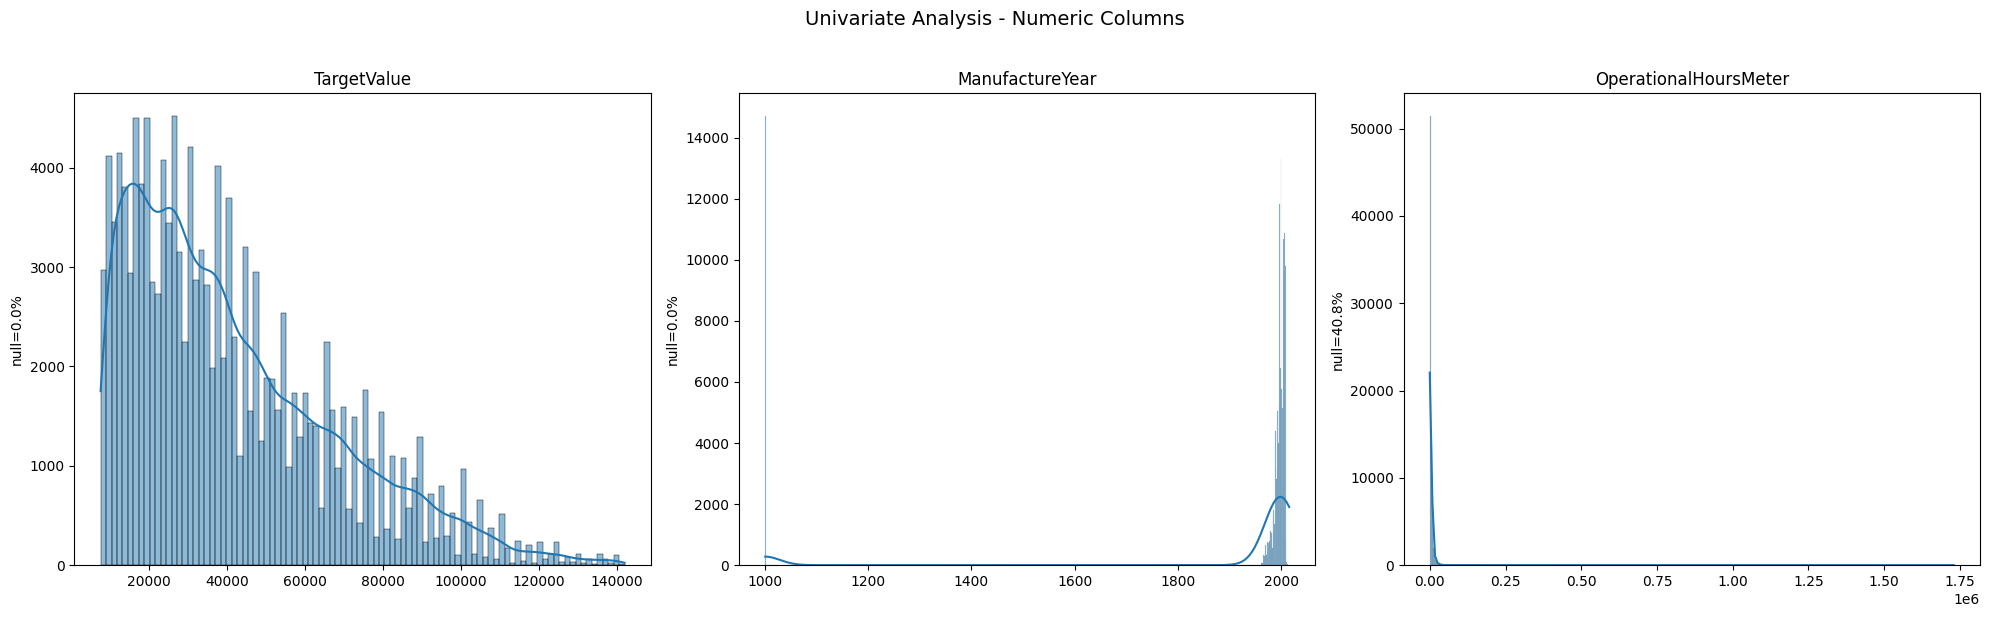

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#-------------------------------Numeric columns----------------------------------------
num_cols = train_renamed.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['TransactionID','AssetID','ProductConfigID']]#ids are not plotted asset id is just an identification id of a specific machine

#ProductConfigID is also  numeric identifier for each machine configuration. Maps exactly 1-to-1 with Spec_FullDescriptor , every ProductConfigID corresponds to exactly one model code. 
#Not plotted as a distribution - the numeric values are arbitrary labels (not quantities), so a histogram would be meaningless. 


fig, axes = plt.subplots(1, 3, figsize=(20,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train_renamed[col].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    null_pct = train_renamed[col].isnull().mean() * 100
    axes[i].set_ylabel(f'null={null_pct:.1f}%')


plt.suptitle('Univariate Analysis - Numeric Columns', y=1.02, fontsize=14) #title and plot spaceing -> y 
plt.tight_layout()
plt.show()

In [112]:
for col in num_cols:
    print(f"------{col}---------")
    print(train_renamed[col].skew())
    #>0 => right skewed 
    #<0=> left skewed

------TargetValue---------
0.9699963984208283
------ManufactureYear---------
-2.554132518855019
------OperationalHoursMeter---------
33.28224827296118


**Observations**

**TargetValue**

- We can see clearly that price is right-skewed
- This is normal as expensive items will be lesser in count compared to cheaper ones
- Will have to do log_transformation -log transform makes RMSE = RMSLE , also need to minimize percentage error not normal error

**ManufactureYear**

- Left skewed
- Clearly outlier value near 1000 (1001 - must be a default value - must replace with nan and impute)
- Most machines were manufactured recently (2000-2010) but a few very old machines from 1950s-1970s pull the tail left.

**OperationalHoursMeter**

- Extremely right skewed , has 40.8% null values
- Most machines have 1,000-5,000 hours but a tiny number have 100,000+ or even 1,750,000 hours - creating an extreme right tail
- Will have to log transform for sure
-  Mean imputation would be wrong , can use median 

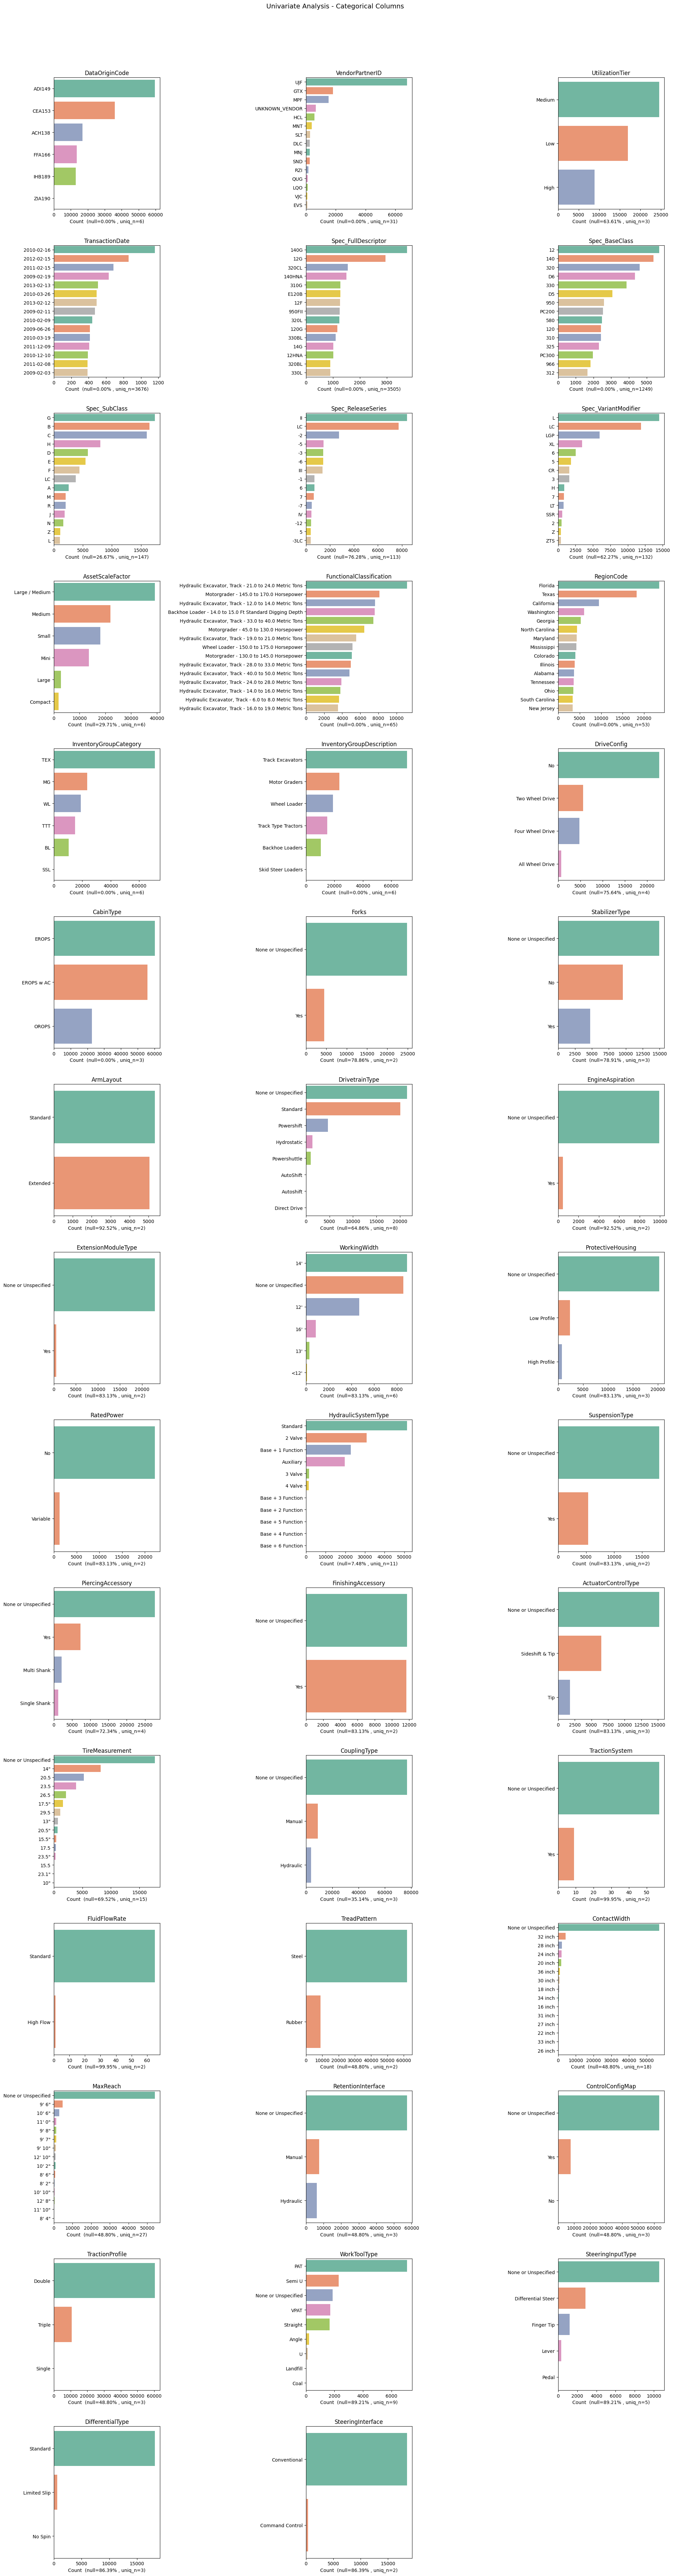

In [113]:
# ------------------------------- Categorical columns - bar chart of value counts ------------------------------

import warnings
warnings.filterwarnings('ignore')

cat_cols = train_renamed.select_dtypes(include='object').columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    val_counts = train_renamed[col].value_counts().head(15)  # top 15 categories (coz there are many colms with very high no of unique categories)
    sns.barplot(x=val_counts.values, y=val_counts.index, ax=axes[i],palette='Set2')                  
    axes[i].set_title(col)
    null_pct = train_renamed[col].isnull().mean() * 100
    nuniq=train_renamed[col].nunique()
    axes[i].set_xlabel(f'Count  (null={null_pct:.2f}% , uniq_n={nuniq})',fontsize=10)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis - Categorical Columns', y=1.02, fontsize=14)
plt.tight_layout(h_pad=3)  # increase vertical padding between rows
plt.show()

**Observations**

**General**

- There are many columns with >10% as missing percentage
- Will have to check further in the next section
- There are many Columns with 'None or Unspecified'

**DataOriginCode:** Data comes from 6 sources. ADI149 dominates with 
~60,000 records - nearly half the dataset comes from one source. 
This suggests the dataset was compiled from multiple auction systems, 
with one being the primary data provider.

**VendorPartnerID:** UJF is by far the largest vendor (~65,000 sales), 
followed by GTX and MPF. The remaining vendors have very few sales. 

The imbalance (UJF dominating) is a separate observation - it means:(if targetencoded)
UJF's target encoded value will be very reliable (65,000 samples -> stable mean)
Rare vendors will be pulled toward global mean by smoothing (few samples -> unreliable mean -> smooth toward global average)

So the imbalance actually makes target encoding work better - the dominant vendor gets a precise encoding while rare vendors get a safe conservative estimate.
**UtilizationTier:** 63.6% missing - the majority of machines have 
no utilization information recorded. Among those that do, Medium is 
most common, followed by Low and High. (Ordinal encoding) 

**TransactionDate:** Sales are clustered around certain dates - 
February dates appear repeatedly (auction events). This suggests 
auctions happen on fixed scheduled dates rather than randomly 
throughout the year.

**Spec_FullDescriptor:** 140G and 12G are the most common models 
(Caterpillar motor graders). Top 15 models together represent a 
small fraction of the 3,505 unique FDs - confirming high cardinality (So target encoding or frequency encoding them might be the right decision)

**Spec_BaseClass:** Similar pattern to FD - 12 and 140 dominate, 
high cardinality with 1,249 unique values.(Target encoding or Frequency Encoding)


**Spec_SubClass:** G, B, C are most common - these are generation 
letters. LC appears too.

**Spec_ReleaseSeries:** II is most common (2nd generation machines). 
LC appears here too. Might have to check where exactly it belongs.(possibly subclass and not release series as per definitions)
76.3% missing - most machines don't have a recorded release series.

**Spec_VariantModifier:** L and LC dominate. 62.3% missing. Again, LC appears here too.

**AssetScaleFactor:** Large/Medium dominates (~40,000 machines) - 
most machines in the auction are mid-to-large size. Mini and Compact 
are rarest. 29.7% missing. (Ordinal encoding)

**FunctionalClassification:** Track Excavators dominate across 
multiple size ranges - consistent with InventoryGroupCategory 
showing TEX as the largest group. Motor Graders and Backhoe Loaders 
follow. Can try to extract the numerical value from the values.

**RegionCode:** Florida and Texas are the top auction locations - California, 
Washington, Georgia follow.


**InventoryGroupCategory:** TEX (Track Excavators) massively 
dominates with approx 65,000 machines - nearly half the dataset. MG, WL, 
TTT, BL follow with much smaller counts. SSL has very few machines.
This imbalance means the model will be most accurate for excavators.

**InventoryGroupDescription:** Mirror of InventoryGroupCategory - 
confirms 1-to-1 mapping.Can be dropped from features to avoid redundancy.

**DriveConfig:** 75.6% missing. Among recorded values, "No" 
(no special drive config) dominates - most machines have standard 
drivetrain. Two Wheel Drive and Four Wheel Drive are minor variants."No" dominates in this data as most machines in this dataset are tracked machines - excavators (TEX) and bulldozers (TTT) move on tracks not wheels. Tracks don't have a "drive configuration" in the wheel sense - the entire track is powered. So DriveConfig = "No" means "this machine doesn't have a wheel drive configuration because it's tracked.

**CabinType:** No missing values - every machine has a cabin type 
recorded. EROPS is most common (approx 60,000), followed by EROPS w AC 
(approx 55,000) and OROPS (approx 22,000). Most modern machines have enclosed 
cabins.

**Forks:** 78.9% missing. Among recorded values, almost all are 
"None or Unspecified" - very few machines have forks. Low signal column. (can try dropping)
These are metal prongs attached to the front of a machine (like a forklift) used to lift and carry pallets, pipes, or heavy materials. Most heavy construction machines don't have forks - they have buckets instead. That's why 78.9% are "None or Unspecified."

**StabilizerType:** 78.9% missing. "None or Unspecified" and "No" 
dominate - stabilizers are uncommon in this dataset. Stabilizers are extendable legs that fold out from the sides of a machine and press into the ground before lifting or digging. Like a camera tripod - they prevent the machine from tipping over when the arm is extended with a heavy load. Common on Backhoe Loaders. Most other machines don't need them - hence 78.9% missing.

**ArmLayout:** 92.5% missing. Only two values - Standard and Extended. 
Extremely sparse - only ~10,000 rows have this recorded. (can try dropping)
it shows whether the digging arm is standard length or extended. Extended arm gives more reach for digging deeper or further away. Only relevant for excavators with arm options - hence very sparse.

**DrivetrainType:** 64.9% missing. "None or Unspecified" and 
"Standard" dominate among recorded values. AutoShift and Autoshift 
appear as separate categories (Capitalization fix needed)
It shows how the engine power is transmitted to the tracks or wheels - Standard (simple direct), Powershift (automatic gear changes under load), Hydrostatic (uses fluid pressure instead of gears), etc.

**EngineAspiration:** 92.5% missing - extremely sparse, almost no 
useful signal.(can try dropping).It shows whether the engine uses a turbocharger (forces more air in for more power) or is naturally aspirated (no turbo, just normal air intake)

**ExtensionModuleType:** 83.1% missing. Only Yes/No values - very 
sparse binary column.(can try dropping).It says whether the machine has an optional extension attachment fitted

**WorkingWidth:** 83.1% missing. Values are in feet (14', 12', 16') 
- only Motor Graders have this measurement. (Can try OrdinalEncoding).It's the width of the blade on a Motor Grader - how wide a strip it can level in one pass. Measured in feet (12', 14', 16'). Only Motor Graders have this - all other machine types are missing.

**ProtectiveHousing:** 83.1% missing. Low Profile and High Profile 
variants - very sparse.It's the type of housing protecting the engine and mechanical parts - Low Profile (flatter, more compact) or High Profile (taller, more accessible for maintenance).

**RatedPower:** 83.1% missing. Only two values - No and Variable. 

**HydraulicSystemType:** Only 7.5% missing - one of the better 
recorded columns. Standard dominates, followed by 2 Valve and 
Base + 1 Function. Multiple valve configurations exist.

**SuspensionType:** 83.1% missing. Mostly "None or Unspecified" 
and "Yes" - very sparse. (can try dropping)

**PiercingAccessory, FinishingAccessory:** Both 72-83% missing. 
Specialist attachment configurations - relevant only for specific 
machine types.

**ActuatorControlType:** 83.1% missing. "None or Unspecified" and 
"Sideshift & Tip" dominate among recorded values. 

**TireMeasurement:** 69.5% missing. Values are tire sizes in inches 
(14", 20.5", 23.5") - only wheeled machines have tires. Can try extracting numeric values.

**CouplingType:** 35.1% missing. "None or Unspecified" overwhelmingly 
dominates - almost all recorded machines have no special coupling.

**TractionSystem :** approx 100% missing - Can try dropping

**FluidFlowRate :** approx 100% missing - Can try dropping

**TreadPattern:** 48.8% missing. Steel tracks overwhelmingly dominate 
over rubber.

**ContactWidth:** 48.8% missing. "None or Unspecified" dominates. 
Among recorded values, 32 inch and 28 inch tracks are most common. 
Can extract numeric inches from it.


**MaxReach:** 48.8% missing. "None or Unspecified" dominates. 
Among recorded values, 9'6" is most common. Values in feet and 
inches format. Can try extracting numeric values,

**RetentionInterface, ControlConfigMap:** 48.8% missing. 
"None or Unspecified" dominates - most machines don't have 
these specialist configurations.

**TractionProfile:** 48.8% missing. Double traction is most common, 
followed by Triple. Single is very rare.

**WorkToolType:** 89.2% missing. PAT (Power Angle Tilt) blade is 
most common among recorded values

**SteeringInputType:** 89.2% missing. "None or Unspecified" and 
"Differential Steer" dominate - very sparse  column.


**DifferentialType:** 86.4% missing. Standard differential  
dominates - Limited Slip and No Spin are very rare variants. 

**SteeringInterface:** 86.4% missing. Conventional steering 
dominates - Command Control is a rare specialist option.

**Overall Observation on Sparse Columns**

Many columns (ArmLayout, EngineAspiration, WorkToolType, 
SteeringInputType etc.) are 83-93% missing - these only apply 
to specific machine types. For example WorkToolType only applies 
to bulldozers, TireMeasurement only to wheeled machines, 
ContactWidth only to tracked machines.

These columns can be kept as features (ordinal encoded with missing=-1) 
rather than dropped - even sparse columns can carry signal for 
the specific machine types where they are recorded. Tree models like LightGBM 
handles the sparsity natively.


## Step 6: Handling Duplicates

In [114]:
cols=[col for col in train_renamed.columns if col!='TransactionID']

dup_count=train_renamed[cols].duplicated().sum()

if dup_count >0:
    print(f"duplicates found: {dup_count}rows")
    train_renamed.drop_duplicates(keep='first',subset=cols,inplace=True)
    train_renamed.reset_index(drop=True,inplace=True)# Without it pandas would add old index as a new column , so after deleting dupes we need new index
    print(f"duplicates removed, new train shape: {train_clean.shape}")
else:
    print ("0 duplicates found")

0 duplicates found


### Step 6 - Decisions

- No duplicates to be dropped

## Step 7: Handling Missing Values 

### 7.1 Row-wise nan checking

In [115]:
# Checking missing values row-wise

# row_nan_count = train_renamed.isna().sum(axis=1)
# display(row_nan_count.sort_values(ascending=False))
row_nan_pct = train_renamed.isna().mean(axis=1)

row_nan_pct_filtered=row_nan_pct[row_nan_pct>0.5]
# display(row_nan_pct_filtered)
print()
display(row_nan_pct_filtered.value_counts())

#19667 rows has >50% and all have 52% missing values and that is the maximum (ie26 features missing)
#(14% of total rows).Not dropping them rn.
#(19667/train_renamed.shape[0])*100


0.52    19667
Name: count, dtype: int64

### 7.2 - Categorical Columns - NaN checking

In [116]:
#check "None or Unspecified"  and others like none, None etc

print("================Train===============")
train_none=(train_renamed =='None or Unspecified').sum()
display(train_none)

print()
print("=============Test==================")
test_none=(test_renamed =='None or Unspecified').sum()
display(test_none)

print()
print(train_none[train_none>0].index.tolist())
print(test_none[test_none>0].index.tolist())




#takes each col of train converts to string representation type and check if it contains as a substring none or unspecified or unknown 
#(?i) => case insensitively
#so it catches none or unspecified too


print('===========Train==================')
train_none_all=train_renamed.apply(lambda col: col.astype(str).str.contains(
    r'(?i)none|unspecified|unknown', 
    na=False  # ignore real NaN values while checking
)).sum()
display(train_none_all)

print()
print('===========Test==================')
test_none_all=test_renamed.apply(lambda col: col.astype(str).str.contains(
    r'(?i)none|unspecified|unknown', 
    na=False  # ignore real NaN values while checking
)).sum()
display(test_none_all)


#checking which all colms in train and test have none, unspecified or similar ones not identified in the above "None or Unspecified" case
print()
print('===========Train & Test "None or Unspecified"==================')
train_none_cols=train_none[train_none>0].index.tolist()
test_none_cols=test_none[test_none>0].index.tolist()
print(train_none_cols)
print(test_none_cols)
print()

print('===========Train & Test regex matching ==================')
train_none_all_cols=train_none_all[train_none_all>0].index.tolist()
test_none_all_cols=test_none_all[test_none_all>0].index.tolist()
print(train_none_all_cols)
print(test_none_all_cols)
print()

print('===========Train & Test set difference ==================')
print(set(train_none_all_cols) - set(train_none_cols))
print(set(test_none_all_cols) - set(test_none_cols))
print()

#checking the unique values of those extra cols identified to verify the same
print('===========Train==================')
print(train_renamed['VendorPartnerID'].unique())
print(train_renamed['RegionCode'].unique())

print()
print('===========Test==================')
print(test_renamed['VendorPartnerID'].unique())
print(test_renamed['RegionCode'].unique())

================Train===============


TransactionID                    0
TargetValue                      0
AssetID                          0
ProductConfigID                  0
DataOriginCode                   0
VendorPartnerID                  0
ManufactureYear                  0
OperationalHoursMeter            0
UtilizationTier                  0
TransactionDate                  0
Spec_FullDescriptor              0
Spec_BaseClass                   0
Spec_SubClass                    0
Spec_ReleaseSeries               0
Spec_VariantModifier             0
AssetScaleFactor                 0
FunctionalClassification         0
RegionCode                       0
InventoryGroupCategory           0
InventoryGroupDescription        0
DriveConfig                      0
CabinType                        0
Forks                        24839
StabilizerType               14923
ArmLayout                        0
DrivetrainType               21482
EngineAspiration              9911
ExtensionModuleType          22891
WorkingWidth        


=============Test==================


TransactionID                   0
AssetID                         0
ProductConfigID                 0
DataOriginCode                  0
VendorPartnerID                 0
ManufactureYear                 0
OperationalHoursMeter           0
UtilizationTier                 0
TransactionDate                 0
Spec_FullDescriptor             0
Spec_BaseClass                  0
Spec_SubClass                   0
Spec_ReleaseSeries              0
Spec_VariantModifier            0
AssetScaleFactor                0
FunctionalClassification        0
RegionCode                      0
InventoryGroupCategory          0
InventoryGroupDescription       0
DriveConfig                     0
CabinType                       0
Forks                        2615
StabilizerType               1553
ArmLayout                       0
DrivetrainType               2355
EngineAspiration             1071
ExtensionModuleType          2515
WorkingWidth                  944
ProtectiveHousing            2240
RatedPower    


['Forks', 'StabilizerType', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'WorkToolType', 'SteeringInputType']
['Forks', 'StabilizerType', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'WorkToolType', 'SteeringInputType']
===========Train==================


TransactionID                    0
TargetValue                      0
AssetID                          0
ProductConfigID                  0
DataOriginCode                   0
VendorPartnerID               6549
ManufactureYear                  0
OperationalHoursMeter            0
UtilizationTier                  0
TransactionDate                  0
Spec_FullDescriptor              0
Spec_BaseClass                   0
Spec_SubClass                    0
Spec_ReleaseSeries               0
Spec_VariantModifier             0
AssetScaleFactor                 0
FunctionalClassification         0
RegionCode                     586
InventoryGroupCategory           0
InventoryGroupDescription        0
DriveConfig                      0
CabinType                        0
Forks                        24839
StabilizerType               14923
ArmLayout                        0
DrivetrainType               21482
EngineAspiration              9911
ExtensionModuleType          22891
WorkingWidth        


===========Test==================


TransactionID                   0
AssetID                         0
ProductConfigID                 0
DataOriginCode                  0
VendorPartnerID               673
ManufactureYear                 0
OperationalHoursMeter           0
UtilizationTier                 0
TransactionDate                 0
Spec_FullDescriptor             0
Spec_BaseClass                  0
Spec_SubClass                   0
Spec_ReleaseSeries              0
Spec_VariantModifier            0
AssetScaleFactor                0
FunctionalClassification        0
RegionCode                     83
InventoryGroupCategory          0
InventoryGroupDescription       0
DriveConfig                     0
CabinType                       0
Forks                        2615
StabilizerType               1553
ArmLayout                       0
DrivetrainType               2355
EngineAspiration             1071
ExtensionModuleType          2515
WorkingWidth                  944
ProtectiveHousing            2240
RatedPower    


===========Train & Test "None or Unspecified"==================
['Forks', 'StabilizerType', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'WorkToolType', 'SteeringInputType']
['Forks', 'StabilizerType', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'WorkToolType', 'SteeringInputType']

===========Train & Test regex matching ==================
['VendorPartnerID', 'RegionCode', 'Forks', 'StabilizerType', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth'

**Observations**

- train and test dataset both have "None or Unspecified" value in 20 colms.
- Both also have unknown values in VendorPartnerID =>UNKNOWN_VENDOR, RegionCode =>Unspecified
- so 22 colms in total have these none type values
- Note that these are those cols other than those with NaN type values
- one way is to replace them with NaN but may not be correct as "None or Unspecified" often means the machine doesn't have that feature at all,while nan means missing information.
- While "none" or "unspecified" represent active, recorded choices by a user or system, NaN represents a technical absence of data.
-So another way is to treat them as a separate group and nan values as a separate group. I will go with this method
-lets keep the current categories as such and then treat nan as a separate category

### 7.3: Identifying NaN in all columns

In [117]:
# another method is to replace the regex pattern with nan entirely and then treat it similar to nan .. ie replace it also as "mising"
# pattern = r'(?i)none|unspecified|unknown'

# train_renamed = train_renamed.replace(pattern, np.nan, regex=True)
# test_renamed = test_renamed.replace(pattern, np.nan, regex=True)
#tested and score reduced

#to get col _description
#metadata cols are not in the same order as in train,test dataset
meta_df=metadata_renamed.set_index('Variable')
#meta_map.index
meta_df.loc['TransactionID','Rephrased Description']

'A unique serial number assigned to each individual accounting record.'

In [118]:
#identifying nan values in all colms

print("========== Train missing count ============")
train_missing = train_renamed.isna().sum()
train_missing_pct = train_renamed.isna().mean() * 100

train_null_df=pd.DataFrame({"column":train_renamed.columns,
                            'description':[meta_df.loc[col,'Rephrased Description'] for col in train_renamed.columns],
                            "dtype":train_renamed.dtypes.values,
                            "train_missing_count":train_missing.values,
                            "missing_pct": np.round(train_missing_pct, 2),
                            "unique_count":[train_renamed[col].nunique() for col in train_renamed.columns]
                           })
display(train_null_df)
display(train_null_df[train_null_df['missing_pct'] > 90 ])
display(train_null_df[(train_null_df['missing_pct']>0)&(train_null_df['missing_pct'] <= 10) ])
train_null_cols=train_null_df[train_null_df['train_missing_count']>0]['column'].tolist()
print(f"Train missing count {train_renamed.isnull().sum().sum()}")
print(f"\nTrain null columns: {train_null_cols}, size: {len(train_null_cols)}")
print()

print("========== Test missing count ============")
test_missing = test_renamed.isna().sum()
test_missing_pct = test_renamed.isna().mean() * 100

test_null_df=pd.DataFrame({"column":test_renamed.columns,
                            'description':[meta_df.loc[col,'Rephrased Description'] for col in test_renamed.columns],
                           "dtype":test_renamed.dtypes.values,
                            "test_missing_count":test_missing.values,
                            "missing_pct": np.round(test_missing_pct, 2),
                            "unique_count":[test_renamed[col].nunique() for col in test_renamed.columns]
                           })
display(test_null_df)
display(test_null_df[test_null_df['missing_pct'] > 90 ])
display(test_null_df[(test_null_df['missing_pct'] > 0) & (test_null_df['missing_pct'] <= 10 )])
test_null_cols=test_null_df[test_null_df['test_missing_count']>0]['column'].tolist()
print(f"Test missing count {test_renamed.isnull().sum().sum()}")
print(f"\nTest null columns: {test_null_cols} , size: {len(test_null_cols)}")
print(f"\nTrain and Test have the same null value cols ?: {set(train_null_cols) == set(test_null_cols)} ")

========== Train missing count ============


,column,description,dtype,train_missing_count,missing_pct,unique_count
TransactionID,TransactionID,A unique serial number assigned to each individual accounting record.,int64,0,0.00,138701
TargetValue,TargetValue,"The financial amount of the transaction, denominated in US Dollars.",float64,0,0.00,675
AssetID,AssetID,The internal tracking number assigned to a specific piece of hardware.,int64,0,0.00,120111
ProductConfigID,ProductConfigID,A system-generated code representing the technical build-out of the unit.,int64,0,0.00,3594
DataOriginCode,DataOriginCode,A code indicating the specific software or platform where the data originated.,object,0,0.00,6
VendorPartnerID,VendorPartnerID,The unique ID of the external entity or third-party provider involved.,object,0,0.00,31
ManufactureYear,ManufactureYear,The year the asset was originally produced.,int64,0,0.00,68
OperationalHoursMeter,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.,float64,56643,40.84,14643
UtilizationTier,UtilizationTier,"A ranking (Low, Medium, or High) based on how heavily the asset is used.",object,88226,63.61,3
TransactionDate,TransactionDate,The official calendar date when the entry was finalized in the system.,object,0,0.00,3676


,column,description,dtype,train_missing_count,missing_pct,unique_count
ArmLayout,ArmLayout,The specific layout or reach of the extension arm.,object,128320,92.52,2
EngineAspiration,EngineAspiration,The status or type of the engine’s air intake/aspiration system.,object,128320,92.52,2
TractionSystem,TractionSystem,The system used for traction and contact with the ground.,object,138635,99.95,2
FluidFlowRate,FluidFlowRate,The rate of fluid flow through the system by volume.,object,138635,99.95,2


,column,description,dtype,train_missing_count,missing_pct,unique_count
HydraulicSystemType,HydraulicSystemType,The classification of the hydraulic or fluid-based power system.,object,10381,7.48,11


Train missing count 3319054

Train null columns: ['OperationalHoursMeter', 'UtilizationTier', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'DriveConfig', 'Forks', 'StabilizerType', 'ArmLayout', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'RatedPower', 'HydraulicSystemType', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'FluidFlowRate', 'TreadPattern', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'TractionProfile', 'WorkToolType', 'SteeringInputType', 'DifferentialType', 'SteeringInterface'], size: 35

========== Test missing count ============


,column,description,dtype,test_missing_count,missing_pct,unique_count
TransactionID,TransactionID,A unique serial number assigned to each individual accounting record.,int64,0,0.00,15000
AssetID,AssetID,The internal tracking number assigned to a specific piece of hardware.,int64,0,0.00,14600
ProductConfigID,ProductConfigID,A system-generated code representing the technical build-out of the unit.,int64,0,0.00,1826
DataOriginCode,DataOriginCode,A code indicating the specific software or platform where the data originated.,object,0,0.00,5
VendorPartnerID,VendorPartnerID,The unique ID of the external entity or third-party provider involved.,object,0,0.00,31
ManufactureYear,ManufactureYear,The year the asset was originally produced.,int64,0,0.00,57
OperationalHoursMeter,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.,float64,6191,41.27,4194
UtilizationTier,UtilizationTier,"A ranking (Low, Medium, or High) based on how heavily the asset is used.",object,9644,64.29,3
TransactionDate,TransactionDate,The official calendar date when the entry was finalized in the system.,object,0,0.00,2563
Spec_FullDescriptor,Spec_FullDescriptor,The complete alphanumeric string detailing all technical parameters.,object,0,0.00,1801


,column,description,dtype,test_missing_count,missing_pct,unique_count
ArmLayout,ArmLayout,The specific layout or reach of the extension arm.,object,13878,92.52,2
EngineAspiration,EngineAspiration,The status or type of the engine’s air intake/aspiration system.,object,13878,92.52,2
TractionSystem,TractionSystem,The system used for traction and contact with the ground.,object,14986,99.91,2
FluidFlowRate,FluidFlowRate,The rate of fluid flow through the system by volume.,object,14986,99.91,1


,column,description,dtype,test_missing_count,missing_pct,unique_count
HydraulicSystemType,HydraulicSystemType,The classification of the hydraulic or fluid-based power system.,object,1122,7.48,11


Test missing count 358795

Test null columns: ['OperationalHoursMeter', 'UtilizationTier', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'DriveConfig', 'Forks', 'StabilizerType', 'ArmLayout', 'DrivetrainType', 'EngineAspiration', 'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing', 'RatedPower', 'HydraulicSystemType', 'SuspensionType', 'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType', 'TireMeasurement', 'CouplingType', 'TractionSystem', 'FluidFlowRate', 'TreadPattern', 'ContactWidth', 'MaxReach', 'RetentionInterface', 'ControlConfigMap', 'TractionProfile', 'WorkToolType', 'SteeringInputType', 'DifferentialType', 'SteeringInterface'] , size: 35

Train and Test have the same null value cols ?: True 


**Observations**

- col10 (HydraulicSystemType)  is the only col with <=10% as missing percentage (7.48 in both test and train)
-  Can try to just impute it later and maybe add a missing flag too
-  Currently going with treating nans as a group named "missing" in that too
-  OperationalHours is the only num colm with nans.
-  Let's analyze the 99 percent missing ones
-  Also, inventory group description and category both seem to imply the same thing

In [119]:
for name,df in [("Train",train_renamed),("Test",test_renamed)]:
    print(f"=============={name}======================")
    print(df['TractionSystem'].value_counts())
    print()
    print(df['FluidFlowRate'].value_counts())
    print()
    print(df['InventoryGroupDescription'].value_counts())
    print()
    print(df['InventoryGroupCategory'].value_counts())

==============Train======================
TractionSystem
None or Unspecified    57
Yes                     9
Name: count, dtype: int64

FluidFlowRate
Standard     65
High Flow     1
Name: count, dtype: int64

InventoryGroupDescription
Track Excavators       71018
Motor Graders          23405
Wheel Loader           18872
Track Type Tractors    14959
Backhoe Loaders        10381
Skid Steer Loaders        66
Name: count, dtype: int64

InventoryGroupCategory
TEX    71018
MG     23405
WL     18872
TTT    14959
BL     10381
SSL       66
Name: count, dtype: int64
==============Test======================
TractionSystem
None or Unspecified    13
Yes                     1
Name: count, dtype: int64

FluidFlowRate
Standard    14
Name: count, dtype: int64

InventoryGroupDescription
Track Excavators       7766
Motor Graders          2578
Wheel Loader           1959
Track Type Tractors    1561
Backhoe Loaders        1122
Skid Steer Loaders       14
Name: count, dtype: int64

InventoryGroupCategory
TE

- TractionSystem has mostly none or unspecified in both train and test
- FluidFlow rate has no none or unspecified
- But decision is to drop currently as both have mostly null values
- Also will drop InventoryGroupDescription as it is the same as InventoryGroupCategory
- These will be dropped at the end of Handling Missing Values section

### 7.4: Numerical Columns - NaN checking and Handling

In [120]:
#--------------------------------------numerical cols with nan---------------------------------------------

display(train_null_df[(train_null_df['dtype'] != 'object')& (train_null_df['missing_pct'] > 0)])

display(test_null_df[(test_null_df['dtype'] != 'object')& (test_null_df['missing_pct'] > 0)])


,column,description,dtype,train_missing_count,missing_pct,unique_count
OperationalHoursMeter,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.,float64,56643,40.84,14643


,column,description,dtype,test_missing_count,missing_pct,unique_count
OperationalHoursMeter,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.,float64,6191,41.27,4194


- **OperationalHoursMeter** is the only num colm with missing values
- will have to impute it with mean/median/mode
- from the data dictionary(defenitions) we see how this hours is related to the tier.(A ranking (Low, Medium, or High) based on how heavily the asset is used.)
- so let's check their relation

**UtilizationTier**

It's a categorical label that describes how heavily the machine was used relative to its age.
For eg:- two machines both have 5,000 hours on them. But one is 3 years old (so it was used very heavily, 1,667 hours per year) and the other is 15 years old (so it was used lightly, 333 hours per year). Same raw hours but completely different usage intensity.
UtilizationTier captures that intensity as a simple label:

**Low** - machine was used less than typical for its age

**Medium** - machine was used about as much as typical for its age

**High** - machine was used more than typical for its age

What the tiers mean in terms of actual hours:

Low utilization -> average 3,134 hours (lightly used)
Medium utilization -> average 6,118 hours (moderately used)
High utilization -> average 19,134 hours (heavily worked)

In [121]:
print(train_renamed[train_renamed['OperationalHoursMeter'].isna()]['UtilizationTier'].unique())
print(train_renamed[train_renamed['OperationalHoursMeter']==0]['UtilizationTier'].unique())
# those with no hours recorded or 0 hours have no tier recorded, ie, if tier is known then hours is known its never 0 or nan

print(train_renamed[train_renamed['UtilizationTier'].isna()]['OperationalHoursMeter'].unique())
# those with no tier recorded have no hours recorded or is 0



print(train_renamed.groupby('UtilizationTier')['OperationalHoursMeter']
        .describe()[['min', '25%', '50%', '75%', 'max']])

#corr with target value
corr = train_renamed[['OperationalHoursMeter', 'TargetValue']].corr().iloc[0,1]
print(f"Correlation of Hours with TargetValue: {corr:.4f}")
 

[nan]
[nan]
[ 0. nan]
                   min      25%     50%      75%        max
UtilizationTier                                            
High             440.0  4500.50  6995.5  11589.0  1729600.0
Low                1.0  1023.00  2003.0   4054.0   372300.0
Medium           233.0  2591.75  4534.0   8003.5  1429800.0
Correlation of Hours with TargetValue: 0.0020



- OperationalHoursMeter is never null when Tier is known, and is null or 0 when tier is null.
- They go missing together as a pair,this is not random. These 56k machines had no meter reading recorded.
- Because the missingness is systematic (not random), we maybe can add a FLAG column so the model can learn "this machine had no meter recorded" as a signal.
- Tier is clearly derived FROM hours: Low < Medium < High .So Tier tells us the bucket, not the exact value.
- near-zero correlation. Hours is weak as a standalone predictor here, likely because usage matters differently per equipment typ(a 5000-hr bulldozeris not same as a 5000-hr excavator).
- Impute within equipment type groups, not globally.


In [122]:
print(train_renamed.groupby('InventoryGroupCategory')['OperationalHoursMeter'].median())
print()
# print(train_renamed.groupby('InventoryGroupDescription')['OperationalHoursMeter'].median())

#-----------------------------------------------------------------------------------
train_renamed[train_renamed['InventoryGroupCategory']=='MG']['OperationalHoursMeter'].unique()
#there are as many zeros in this group's oh such that the middle value is zero

#----------------------------------------------------------------------------------------
print(train_renamed[train_renamed['OperationalHoursMeter']==0]['UtilizationTier'].unique())
print(((train_renamed[train_renamed['OperationalHoursMeter']==0].shape[0])/train_renamed.shape[0])*100)

InventoryGroupCategory
BL     2607.0
MG        0.0
SSL    1139.0
TEX    1129.5
TTT    2182.5
WL     1754.0
Name: OperationalHoursMeter, dtype: float64

[nan]
22.77056401900491


- Each equipment type has a different typical hours profile.
- Imputing with group median is more honest than a single global value. (median is not affected by outliers)
- Motor Graders have 0 as median.

**Further Doubts**
- Also for all those machines with hours as 0 (22% rows), their tier is nan = => 0's in oh hours can be treated as nans/unknowns then?
- If a machine genuinely had 0 hours - meaning it ran for 0 hours - you'd still expect someone to record its utilization tier as "Low." The fact that both are always missing together means the data source simply had no information to record for either field. That points to "not recorded" rather than "genuinely zero."
  
OperationalHoursMeter = 0 is treated as unknown because:

1. OH and UtilizationTier are always recorded together - when one is
   missing, the other is always missing too .
   This suggests they come from the same data source, and when that source
   has no data, both fields are empty - including recording 0 for OH.
Decision: treat OH=0 same as null, flag with hours_missing, impute.


In [123]:
train_renamed['TransactionDate'] = pd.to_datetime(train_renamed['TransactionDate'])

# treat zeros as unknown too, re-impute with non-zero group median
#here just done for demonstration- in the ML Pipeline this is done after train-val split

train_imp=train_renamed.copy()
test_imp=test_renamed.copy()


oh_zero_train = (train_imp['OperationalHoursMeter'] == 0)
oh_zero_test  = (test_imp['OperationalHoursMeter'] == 0)
print(f"Train OH zeros: {oh_zero_train.sum()}")
print(f"Test  OH zeros: {oh_zero_test.sum()}")

train_imp['OperationalHoursMeter'] = train_imp['OperationalHoursMeter'].replace(0, np.nan)
test_imp['OperationalHoursMeter']  = test_imp['OperationalHoursMeter'].replace(0, np.nan)

# flag (combine original null flag with new zero flag)
train_imp['hours_missing'] = train_imp['OperationalHoursMeter'].isnull().astype(int)
test_imp['hours_missing']  = test_imp['OperationalHoursMeter'].isnull().astype(int)

# impute using non-zero median per equipment type (fit on train only)
#since we have replaced zeros with nan already ,it will be non zero median
oh_med = (train_imp.groupby('InventoryGroupCategory')['OperationalHoursMeter'].median()) # fill with group median
oh_g = oh_med.mean() #or can use train_imp['OperationalHoursMeter'].median()   # fallback for unknown groups , eg if test has unknown groups, or if for some group median does'nt exist (nan)
print()
print("Non-zero group medians used for imputation:")
print(oh_med)
#print(train_imp['InventoryGroupCategory'].map(oh_med)) # map each inv group to its median value if it exists # a series of 138700 length

train_imp['OperationalHoursMeter'] = train_imp['OperationalHoursMeter'].fillna(
    train_imp['InventoryGroupCategory'].map(oh_med)).fillna(oh_g) #first fill rows with nan in oh column with those rows' inv groups' median, then if still nans fill with global value

test_imp['OperationalHoursMeter']  = test_imp['OperationalHoursMeter'].fillna(
    test_imp['InventoryGroupCategory'].map(oh_med)).fillna(oh_g)



Train OH zeros: 31583
Test  OH zeros: 3453

Non-zero group medians used for imputation:
InventoryGroupCategory
BL     2761.5
MG     6037.0
SSL    1139.0
TEX    3893.0
TTT    4047.0
WL     5922.0
Name: OperationalHoursMeter, dtype: float64


### 7.5: Categorical Columns - NaN, missing values handling

In [124]:
cat_null_cols=[col for col in train_null_cols if col != 'OperationalHoursMeter']

#treat nan as a separate category named Missing (this category name does not already exist in data)
train_clean=train_imp.copy()
test_clean=test_imp.copy()

for col in cat_null_cols: #train and test have same null cols
    train_clean[col]  = train_clean[col].fillna('missing')
    test_clean[col]  = test_clean[col].fillna('missing')
    
print(train_clean.isnull().sum().sum())
print(test_clean.isnull().sum().sum())



#verify if missing category count for each in train_clean is same as the null count in train (also for test)#except for operational hours

train_validation=pd.DataFrame({
    'column':train_renamed.columns,
    "train_null_count":train_missing.values,
    "train_clean_missing_cat":[sum(train_clean[col]=="missing") for col in train_renamed.columns]
    
})
train_validation['match']=train_validation['train_null_count']==train_validation['train_clean_missing_cat']
test_validation=pd.DataFrame({
    'column':test_renamed.columns,
    "test_null_count":test_missing.values,
    "test_clean_missing_cat":[sum(test_clean[col]=="missing") for col in test_renamed.columns]
    
})
test_validation['match']=test_validation['test_null_count']==test_validation['test_clean_missing_cat']

print("=============Train=================")
display(train_validation)
print()
print("=============Test=================")
display(train_validation)

0
0
=============Train=================


,column,train_null_count,train_clean_missing_cat,match
0,TransactionID,0,0,True
1,TargetValue,0,0,True
2,AssetID,0,0,True
3,ProductConfigID,0,0,True
4,DataOriginCode,0,0,True
5,VendorPartnerID,0,0,True
6,ManufactureYear,0,0,True
7,OperationalHoursMeter,56643,0,False
8,UtilizationTier,88226,88226,True
9,TransactionDate,0,0,True



=============Test=================


,column,train_null_count,train_clean_missing_cat,match
0,TransactionID,0,0,True
1,TargetValue,0,0,True
2,AssetID,0,0,True
3,ProductConfigID,0,0,True
4,DataOriginCode,0,0,True
5,VendorPartnerID,0,0,True
6,ManufactureYear,0,0,True
7,OperationalHoursMeter,56643,0,False
8,UtilizationTier,88226,88226,True
9,TransactionDate,0,0,True


### 7.6 Dropping columns

In [125]:
## Dropping Columns
## the ones with 99% missing values and then redundant column InventoryGroupDescription

cols_to_drop = ['TractionSystem', 'FluidFlowRate', 'InventoryGroupDescription']
for df in [train_clean, test_clean]:
    df.drop(columns=cols_to_drop, inplace=True)

print("Dropped:", cols_to_drop)
print(f"train_clean shape: {train_clean.shape}")
print(f"test_clean shape: {test_clean.shape}")

Dropped: ['TractionSystem', 'FluidFlowRate', 'InventoryGroupDescription']
train_clean shape: (138701, 48)
test_clean shape: (15000, 47)


### Step 7: Decisions

1. Drop columns - TractionSystem,FluidFlowRate (99% missing) , InventoryGroupDescription (one to one with InventoryGroupCategory) - can be done before split
2. Numerical Columns - OPHours -> treat 0s as nans , flag missing values, impute with median group hours - must be done after split
3. Categorical Columns - nan->'missing' category ie treat as a separate category as most have >10% as missing pct - can be done before split

## Step 8: Checking Column unique values (additional missing values handling)

In [126]:
#check for categorical cols if test has a category that train doesn't have --> before encoding
#don't truncate
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

#checking distinct values of cat_cols

cat_cols=train_clean.select_dtypes(include='object').columns.tolist()
print("========================Train============================")
for col in cat_cols:
    print(f"======{col}=====") 
    print(train_clean[col].unique(), train_clean[col].nunique())
    print()

print("========================Test============================")
for col in cat_cols:
    print(f"======{col}=====")
    print(test_clean[col].unique(), train_clean[col].nunique())
    print()

========================Train============================
======DataOriginCode=====
['ACH138' 'ADI149' 'CEA153' 'FFA166' 'IHB189' 'ZIA190'] 6

======VendorPartnerID=====
['GTX' 'HCL' 'UJF' 'MNT' 'AFZ' 'NTE' 'DLC' 'MPF' 'LKQ' 'SQU' 'TAI' 'CBS'
 'MNJ' 'LQO' 'IMS' 'MBO' 'GMU' 'RVF' 'IQP' 'RZI' 'SND' 'SLT' 'QUG' 'SGU'
 'EVS' 'VJC' 'RKC' 'HJW' 'UNKNOWN_VENDOR' 'MHV' 'RGK'] 31

======UtilizationTier=====
['Low' 'High' 'Medium' 'missing'] 4

======Spec_FullDescriptor=====
['950FII' '310G' '790ELC' ... 'EC460B' '736VHP' '55N2'] 3505

======Spec_BaseClass=====
['950' '310' '790' ... 'PC290' 'R964' '716'] 1249

======Spec_SubClass=====
['F' 'G' 'E' 'D' 'HAG' 'B' 'missing' 'NX' 'SUPER K' 'STD' 'Z' 'C' 'A' 'H'
 'MR' 'PT' 'L' 'M' 'BL' 'J' 'SE' 'HD' 'LC' 'SUPER M' 'LX' 'SUPER L' 'LE'
 'K' 'S' 'R' 'P' 'SG' 'US' 'UU' 'WX' 'PX' 'N' 'ZTM' 'MXT' 'EX' '-2' 'LCM'
 'HZ' 'AX' '3' 'SR' '7' 'ZTS' 'B     ' 'UR' '-3' 'XT' 'V' 'ZT' '1' 'DZ'
 'WD' 'SRLC' 'TM' 'T' 'CH' 'CS' 'M      ' 'ZHS G' 'Q' 'MRX' 'FR' 'SUPER E

**Observations**
- there are trailing/leading whitespaces
- examine the cols with numerical values further - MaxReach, TireMeasurement , ContactWidth, WorkingWidth, FunctionalClassification (check descriptions)
- examine spec_cols -> NAME#?, -1, -2 etc values are there
- scientific notations ->7.00E+00, -1.50E+01,6.00E+00
- check TransactionDate,Spec_FullDescriptor,Spec_BaseClass check their unique classes separately coz many distinct values they have
- DrivetrainType -> Autoshift, AutoShift are the same



#### Numeric Extraction - Column Changes & Reasoning

#### col22 -> MaxReach
- **Raw format:** `11' 0"`, `9' 10"`, `None or Unspecified`, `missing`
- **Change:** Parse feet and inches -> single decimal float (e.g. `11' 6"` -> `11.5`)
- **Why:** Arm reach is a continuous physical measurement. Storing it as a string
  means the model can't use its numeric relationships. Converting to decimal feet
  gives the model a meaningful continuous feature where larger = longer reach = 
  typically higher price.

#### col21 -> ContactWidth
- **Raw format:** `16 inch`, `32 inch`, `None or Unspecified`, `missing`
- **Change:** Strip the word `inch`, cast to integer
- **Why:** Track width is already numeric in meaning - only the unit label is
  polluting it. Stripping `inch` and casting gives the model a clean integer it
  can split on numerically.

#### col15 -> TireMeasurement
- **Raw format:** `23.5`, `23.5"`, `None or Unspecified`, `missing`
- **Change:** Strip trailing `"` character, cast to float
- **Why:** Mixed formats (`23.5` vs `23.5"`) create spurious duplicate categories
  if treated as strings - the model sees them as two different values when they
  are the same. Stripping and casting collapses them into one consistent numeric
  value.

#### col7 -> WorkingWidth
- **Raw format:** `12'`, `14'`, `<12'`, `None or Unspecified`, `missing`
- **Change:** Strip `'`, map `<12'` -> `11.5`, cast to float
- **Why:** Blade width is ordinal-numeric - wider blade = more capacity = higher
  price. `<12'` is not a category, it's a range indicator meaning "less than 12"
  - assigning `11.5` preserves the ordering without losing the information that
  this machine has a narrower blade than the `12'` group.

#### Common treatment for all four
- `None or Unspecified` -> `NaN` - this means the feature was recorded as absent,
  not that the machine lacks it. Keeping as a string would create a spurious
  category. `NaN` lets LightGBM/XGBoost handle it natively via their missing
  value routing.
- `missing` -> `NaN` - data was never recorded. Same reasoning - `NaN` is the
  correct representation for truly absent data in tree-based models.
- After conversion all four columns are passed as **plain numeric (float)**  



### 8.1: Fixing leading, trailing whitespaces

In [127]:
# Step 1 - strip whitespace from all object cols ('B   ' & 'B' must be the same)
#.apply() on a DataFrame applies a function to each column one by one.

cat_cols = train_clean.select_dtypes(include='object').columns
train_clean[cat_cols] = train_clean[cat_cols].apply(lambda col: col.str.strip())
test_clean[cat_cols] = test_clean[cat_cols].apply(lambda col: col.str.strip())


### 8.2: cleaning #NAME? values

In [128]:
# check which cols have #NAME? and count

for df, name in [(train_clean, 'TRAIN'), (test_clean, 'TEST')]:
    print(f"\n=== {name} ===")
    for col in cat_cols:
        count = (df[col] == '#NAME?').sum()
        if count > 0:
            print(f"  {col}: {count} rows")


=== TRAIN ===
  Spec_SubClass: 7 rows
  Spec_ReleaseSeries: 350 rows

=== TEST ===
  Spec_ReleaseSeries: 48 rows


In [129]:
#1: Spec_SubClass


train_clean_col=train_clean.copy()
test_clean_col=test_clean.copy()

display(train_clean_col[train_clean_col['Spec_SubClass'] == '#NAME?'])
#Note that subclass comes from the full descriptor's second part (alphabetical part) (observed from the other training data)
#All these are of D51-EX so subclass -> EX?

print(train_clean_col[train_clean_col['Spec_FullDescriptor'] == 'D51-EX'].shape)
#only 7 have this D51-EX as the fulldescriptor  and all of them have  #NAME? as subclass ,so lets add EX as their subclass

print(train_clean_col[train_clean_col['Spec_FullDescriptor'] == 'D51-EX'].shape)
 # test has no such rows with this as full descriptor 

#add EX as spec_subclass
train_clean_col.loc[train_clean_col['Spec_FullDescriptor'] == 'D51-EX' , 'Spec_SubClass'] ='EX'

#verify
# display(train_clean[train_clean['Spec_SubClass'] == 'EX'])

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,DriveConfig,CabinType,Forks,StabilizerType,ArmLayout,DrivetrainType,EngineAspiration,ExtensionModuleType,WorkingWidth,ProtectiveHousing,RatedPower,HydraulicSystemType,SuspensionType,PiercingAccessory,FinishingAccessory,ActuatorControlType,TireMeasurement,CouplingType,TreadPattern,ContactWidth,MaxReach,RetentionInterface,ControlConfigMap,TractionProfile,WorkToolType,SteeringInputType,DifferentialType,SteeringInterface,hours_missing
120561,2701495,92000.0,1076111,24418,FFA166,MHV,2008,1453.0,Low,2012-03-02,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Alabama,TTT,missing,EROPS w AC,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,None or Unspecified,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
120563,2701520,86000.0,1309037,24418,FFA166,MHV,2009,1376.0,Medium,2011-09-08,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Alabama,TTT,missing,EROPS w AC,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,None or Unspecified,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
120564,2701521,80000.0,1309037,24418,FFA166,MHV,2009,1375.0,Medium,2011-06-09,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Alabama,TTT,missing,EROPS w AC,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,None or Unspecified,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
120625,2702891,85000.0,1894890,24418,FFA166,MPF,2009,1393.0,Medium,2011-08-27,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Georgia,TTT,missing,EROPS,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,None or Unspecified,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
120679,2704883,95000.0,1108531,24418,FFA166,UJF,2009,2457.0,High,2011-09-15,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Missouri,TTT,missing,EROPS w AC,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,Multi Shank,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
132006,4360059,67500.0,2271278,24418,IHB189,UJF,2008,3913.0,Medium,2013-02-12,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Florida,TTT,missing,EROPS,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,Multi Shank,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0
132100,4361180,70000.0,2286032,24418,IHB189,UJF,2009,7257.0,High,2012-03-09,D51-EX,D51,#NAME?,missing,missing,Medium,"Track Type Tractor, Dozer - 105.0 to 130.0 Horsepower",Texas,TTT,missing,EROPS w AC,missing,missing,missing,Standard,missing,missing,missing,missing,missing,2 Valve,missing,Multi Shank,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,PAT,None or Unspecified,missing,missing,0


(7, 48)
(7, 48)


In [130]:
#2: Spec_ReleaseSeries

print(train_clean_col[train_clean_col['Spec_ReleaseSeries'] == '#NAME?']['Spec_FullDescriptor'].unique())

print(test_clean_col[test_clean_col['Spec_ReleaseSeries'] == '#NAME?']['Spec_FullDescriptor'].unique())

print()
# Note: none of them have nan ie "missing" Spec_FullDescriptor

#-----------------------------------------------------------

print(train_clean_col[train_clean_col['Spec_FullDescriptor'] == 'ZX35U-NA']['Spec_ReleaseSeries'].unique())
print(test_clean_col[test_clean_col['Spec_FullDescriptor'] == 'ZX35U-NA']['Spec_ReleaseSeries'].unique())
print()
#------------------------------------------------------------

#lets check if any of the rows has mark in its description and if so how their release series are marked
train_clean_col[train_clean_col['Spec_FullDescriptor'].str.contains('MARK', na=False)]['Spec_ReleaseSeries'].unique()
#na=False => f you run into a nan row, just assume it does not contain the word 'MARK' and keep moving.

['SK160LC-IV' 'SK150LC-IV' 'SK120LC-IV' 'K909LC-MARK II' 'SK300LC-IV'
 'SK400LC-IV' 'SK120LC-III' 'SK130LC-MARK IV' 'LK1150-MARK II'
 'SK250LC-VI' 'SK200LC-IV' 'SK60-III' 'SK60-IV' 'LK350-MARK II'
 'SK150LC-III' 'K905LC-MARK II' 'SK100-IV' 'SK120-I' 'SK115DZ-IV'
 'LK650-MARK II' 'K912LC-MARK II' 'SK160LC-III' 'K916LC-II' 'SK100-III'
 'ZX35U-NA' 'SK270LC-IV' 'SK220LC-IV' 'SK200LC-III' 'SK400LC-III'
 'SK160LC-V']
['SK120LC-IV' 'LK650-MARK II' 'SK150LC-IV' 'K912LC-MARK II' 'ZX35U-NA'
 'SK120LC-III' 'SK150LC-III' 'K905LC-MARK II' 'K904-MARK II' 'SK160LC-III'
 'SK130LC-MARK IV' 'SK200LC-III' 'SK400LC-IV']

['#NAME?']
['#NAME?']



array(['#NAME?'], dtype=object)

- Is II = MARK II? (googled) In heavy machinery naming conventions, yes - MARK II and II mean the same thing (second generation/series). MARK is just a prefix some manufacturers use. So II is the correct series to assign.

- ZX35U-NA - both train and test have #NAME? for this descriptor's release series. NA here likely means North America (a regional variant marker), (also did google)not a release series. So the safest fix is to assign 'missing' rather than 'NA' since there's no valid series information.

In [131]:
#2: Spec_ReleaseSeries

def clean_srs(row):
    rs = row['Spec_FullDescriptor'].split('-')[-1]
    if 'MARK' in rs:
        rs = rs.split(' ')[-1]
    elif rs == 'NA':
        rs = 'missing'
    return rs

train_clean_col.loc[train_clean_col['Spec_ReleaseSeries'] == '#NAME?', 'Spec_ReleaseSeries'] = \
train_clean_col[train_clean_col['Spec_ReleaseSeries'] == '#NAME?'].apply(clean_srs, axis=1)

test_clean_col.loc[test_clean_col['Spec_ReleaseSeries'] == '#NAME?', 'Spec_ReleaseSeries'] = \
test_clean_col[test_clean_col['Spec_ReleaseSeries'] == '#NAME?'].apply(clean_srs, axis=1)

#verify
print(train_clean_col[train_clean_col['Spec_FullDescriptor'] == 'ZX35U-NA']['Spec_ReleaseSeries'].unique())
print(test_clean_col[test_clean_col['Spec_FullDescriptor'] == 'ZX35U-NA']['Spec_ReleaseSeries'].unique())

print(train_clean_col['Spec_ReleaseSeries'].unique())
print(test_clean_col['Spec_ReleaseSeries'].unique())

['missing']
['missing']
['II' 'missing' 'LC' 'III' '-1' '5' '-2' '1' '-5' 'IV' '-3L' '3' '15'
 '-12' '6' 'V' '-21' '-7' '7' '-3MC' '-21A' '-3' '-3LC' '-6' '-5L' '-5H'
 '-1L' '-8' '4' '2' '-15' '-20' 'E' '-3C' '-6B' '7.00E+00' '-6E' 'A' 'ZTS'
 '12' 'V-2' '-3PT' 'XT' '-7E' '-2N' '-2C' '-8E' '-6LC' '-3H' '16' '-18'
 'IV-2' 'VI' '-3LK' '-6K' '6F' '22' '3A' 'VHP' 'LGP' 'LT' '2T' 'EX' '-6C'
 '3C' '18' '17' '-2LC' 'M' 'D' 'ZX' 'LV' '-5LC' '6.00E+00' '-16' '8' '-17'
 '-7B' '-1C' 'LL' 'G' 'L' 'WX' '-2A' '-5E' '-5F' '-3M' 'D7' '7A' 'I' '2B'
 '20' '-7K' '-6LK' '-2E' 'H' '-1B' 'AWS' 'TC' 'Elite' 'WT' 'XLT'
 'SeriesII' '-1.50E+01' 'GALEO' '6L' '6LE' '6LK' '21KomStatII' '21KomStat'
 '7L' '-3EO' 'Q' 'VII']
['missing' '-5' 'III' 'LC' 'II' '5' '-6' '-3PT' '-6E' '-2' 'V' 'IV' '-1'
 '6' '-3LK' '3' '15' '1' '-15' '-20' '-12' '-3' '2' '-18' '-2C' '7' '-3MC'
 '-7' '-21' '-8' '-5L' '7.00E+00' '-2N' '-1L' '14FT' 'EX' '-3L' '-7K'
 'ZTS' '3C' '-3LC' 'M' 'D' 'A' 'IV-2' '-6LC' '-6B' '-5LC' '8' 'WX' 'E'
 '-7E' '2T

In [132]:
#clean the release col in general (remove '-' prefix)
print(train_clean_col.loc[train_clean_col['Spec_ReleaseSeries'] == '-8','Spec_FullDescriptor'].unique())
print(train_clean_col.loc[train_clean_col['Spec_ReleaseSeries'] == '8','Spec_FullDescriptor'].unique())
#done in 7.3 section , but didn't improvre score , instead reduced by a bit, so commented that section out

['D65E-8' 'D65P-8' 'PC45R-8' 'PC27R-8' 'D21P-8' 'PC200-8' 'D21A-8'
 'PC20R-8' 'PC15R-8' 'PC35R-8' 'PC12R-8' 'MS120-8' 'PC30R-8' 'PC40R-8'
 'D65A-8' 'PC45-8']
['PC1250SP8' 'PC88MR8' 'PC1308' 'PC210LC8K' 'PC200LC8GALEO']


### 8.3: Cleaning Scientific notations

In [133]:
# check which cols have scientific notations and count

for df, name in [(train_clean_col, 'TRAIN'), (test_clean_col, 'TEST')]:
    print(f"\n=== {name} ===")
    for col in cat_cols:
        count = (df[col].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False)).sum()
        if count > 0:
            print(f"  {col}: {count} rows")


=== TRAIN ===
  Spec_FullDescriptor: 12 rows
  Spec_ReleaseSeries: 96 rows
  Spec_VariantModifier: 63 rows

=== TEST ===
  Spec_ReleaseSeries: 10 rows
  Spec_VariantModifier: 10 rows


In [134]:
#1: Spec_FullDescriptor - train-only issue

train_clean_col.loc[train_clean_col['Spec_FullDescriptor'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']]

,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
720,2.14E+06,214,E,4,missing
1273,2.14E+06,214,E,4,missing
2552,2.15E+05,215,E,3,missing
6826,2.14E+06,214,E,4,missing
9260,2.15E+05,215,E,3,missing
104760,2.14E+04,214,E,2,missing
104765,2.15E+05,215,E,3,missing
104767,2.15E+05,215,E,3,missing
119759,2.15E+04,215,E,2,missing
119795,2.14E+06,214,E,4,missing


- such a fd 214e exists as per google - jcb manufacturer

In [135]:
#1: Spec_FullDescriptor


# Fix: rebuild Spec_FullDescriptor from parts for scientific notation rows
train_clean_sci=train_clean_col.copy()
test_clean_sci=test_clean_col.copy()

sci_mask = train_clean_sci['Spec_FullDescriptor'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False)
#mask (A bool series) stores the row positions where this error is currently there ..so  that we can reuse it once we fix the issue on the df to verify if its fixed

train_clean_sci.loc[sci_mask, 'Spec_FullDescriptor'] = (
    train_clean_sci.loc[sci_mask, 'Spec_BaseClass'].fillna('') +
    train_clean_sci.loc[sci_mask, 'Spec_SubClass'].fillna('') +
    train_clean_sci.loc[sci_mask, 'Spec_ReleaseSeries'].fillna('')
)
# verify
print(train_clean_sci[sci_mask][['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries']])

       Spec_FullDescriptor Spec_BaseClass Spec_SubClass Spec_ReleaseSeries
720                  214E4            214             E                  4
1273                 214E4            214             E                  4
2552                 215E3            215             E                  3
6826                 214E4            214             E                  4
9260                 215E3            215             E                  3
104760               214E2            214             E                  2
104765               215E3            215             E                  3
104767               215E3            215             E                  3
119759               215E2            215             E                  2
119795               214E4            214             E                  4
119796               214E2            214             E                  2
119802               214E3            214             E                  3


In [136]:
#2: Spec_ReleaseSeries 
display(train_clean_sci.loc[train_clean_sci['Spec_ReleaseSeries'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']])
display(test_clean_sci.loc[test_clean_sci['Spec_ReleaseSeries'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']])

#------------------------------------------------------------------------------------
print("Inspecting rows just with scientific notations in spec release series")

for name,df in [("Train",train_clean_sci),("Test",test_clean_sci)]:
    print(f"==============={name}==================")
    mask= df['Spec_ReleaseSeries'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False)
    mask1= df['Spec_VariantModifier']=='LGP'
    
    print("Spec_ReleaseSeries: ",df.loc[mask,'Spec_ReleaseSeries'].unique())
    print("Spec_VariantModifier:" ,df.loc[mask,'Spec_VariantModifier'].unique())
    print("FD corresponding to LGP - variant modifier:" ,df.loc[mask & mask1 ,'Spec_FullDescriptor'].unique())
    print("RS corresponding to LGP - variant modifier:" ,df.loc[mask & mask1 ,'Spec_ReleaseSeries'].unique())
    print()


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
2132,PC300LC7E0,PC300,LC,7.00E+00,missing
2421,PC400LC7E0,PC400,LC,7.00E+00,missing
3671,PC300LC7E0,PC300,LC,7.00E+00,missing
5711,PC300LC7E0,PC300,LC,7.00E+00,missing
9831,PC300LC7E0,PC300,LC,7.00E+00,missing
...,...,...,...,...,...
138174,PC300LC7E0,PC300,LC,7.00E+00,missing
138175,PC300LC7E0,PC300,LC,7.00E+00,missing
138178,PC400LC7E0,PC400,LC,7.00E+00,missing
138179,PC400LC7E0,PC400,LC,7.00E+00,missing


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
1103,PC300LC7E0,PC300,LC,7.00E+00,missing
1215,PC300LC7E0,PC300,LC,7.00E+00,missing
7907,PC300LC7E0,PC300,LC,7.00E+00,missing
11580,PC1206E0,PC120,missing,6.00E+00,missing
11757,PC400LC7E0,PC400,LC,7.00E+00,missing
11760,PC300LC7E0,PC300,LC,7.00E+00,missing
11846,PC300LC7E0,PC300,LC,7.00E+00,missing
11850,PC300LC7E0,PC300,LC,7.00E+00,missing
14211,D65PX-15E0LGP,D65,PX,-1.50E+01,LGP
14940,PC300LC7E0,PC300,LC,7.00E+00,missing


Inspecting rows just with scientific notations in spec release series
===============Train==================
Spec_ReleaseSeries:  ['7.00E+00' '6.00E+00' '-1.50E+01']
Spec_VariantModifier: ['missing' 'LGP']
FD corresponding to LGP - variant modifier: ['D65PX-15E0LGP' 'D61PX-15E0LGP']
RS corresponding to LGP - variant modifier: ['-1.50E+01']

===============Test==================
Spec_ReleaseSeries:  ['7.00E+00' '6.00E+00' '-1.50E+01']
Spec_VariantModifier: ['missing' 'LGP']
FD corresponding to LGP - variant modifier: ['D65PX-15E0LGP']
RS corresponding to LGP - variant modifier: ['-1.50E+01']



- from other rows it seems like the pattern should be like 7 -> rs and E0-> vm
- googled too

For all rows in train and test with spec_release series in sci_notation form:
- variant modifier is either missing or is LGP
- its is LGP only for fd with -15E0LGP as suffix , ie -1.50E+01 as the release series
- so we'll update rs to the corresponding no ie , 6 or 7 or 15 and vm to E0(for others) or E0LGP (for ones with -1.50E+01 as rs)for them 

In [137]:
# store the mask before making any changes so that both steps use the same exact rows
train_sci_mask = train_clean_sci['Spec_ReleaseSeries'].isin(['7.00E+00', '6.00E+00', '-1.50E+01'])
test_sci_mask  = test_clean_sci['Spec_ReleaseSeries'].isin(['7.00E+00', '6.00E+00', '-1.50E+01'])

# Step 1: fix Spec_ReleaseSeries - extract just the digit (only for masked rows)
rs_fix = {
    '7.00E+00': '7',
    '6.00E+00': '6',
    '-1.50E+01': '-15',
}
train_clean_sci.loc[train_sci_mask, 'Spec_ReleaseSeries'] = train_clean_sci.loc[train_sci_mask, 'Spec_ReleaseSeries'].replace(rs_fix)
test_clean_sci.loc[test_sci_mask, 'Spec_ReleaseSeries']   = test_clean_sci.loc[test_sci_mask, 'Spec_ReleaseSeries'].replace(rs_fix)

# Step 2: fix Spec_VariantModifier - prepend 'E0' (only for the SAME masked rows)
def add_e0(vm):
    if vm in [None, 'missing'] or pd.isna(vm): #missing case
        return 'E0'
    return 'E0' + vm  #LGP case

train_clean_sci.loc[train_sci_mask, 'Spec_VariantModifier'] = train_clean_sci.loc[train_sci_mask, 'Spec_VariantModifier'].apply(add_e0)
test_clean_sci.loc[test_sci_mask, 'Spec_VariantModifier']   = test_clean_sci.loc[test_sci_mask, 'Spec_VariantModifier'].apply(add_e0)

# verify - only the 96 train rows / corresponding test rows should have changed

for name,df,mask in [("Train",train_clean_sci,train_sci_mask),("Test",test_clean_sci,test_sci_mask)]:
    print(f"==============={name}==================")
    
    print("Spec_ReleaseSeries: ",df.loc[mask,'Spec_ReleaseSeries'].unique())
    print("Spec_VariantModifier:" ,df.loc[mask,'Spec_VariantModifier'].unique())
    print()
    display(df[mask][['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].drop_duplicates())

===============Train==================
Spec_ReleaseSeries:  ['7' '6' '-15']
Spec_VariantModifier: ['E0' 'E0LGP']



,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
2132,PC300LC7E0,PC300,LC,7,E0
2421,PC400LC7E0,PC400,LC,7,E0
11369,PC300HD7E0,PC300,HD,7,E0
67388,PC1206E0,PC120,missing,6,E0
131635,D65PX-15E0LGP,D65,PX,-15,E0LGP
132027,D61PX-15E0LGP,D61,PX,-15,E0LGP


===============Test==================
Spec_ReleaseSeries:  ['7' '6' '-15']
Spec_VariantModifier: ['E0' 'E0LGP']



,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
1103,PC300LC7E0,PC300,LC,7,E0
11580,PC1206E0,PC120,missing,6,E0
11757,PC400LC7E0,PC400,LC,7,E0
14211,D65PX-15E0LGP,D65,PX,-15,E0LGP


In [138]:
#Reduced the score when this was done, so commented it out

# The dash is a SEPARATOR in the original model name
# PC40MR-1 -> BaseClass=PC40, SubClass=MR, ReleaseSeries=-1
# current data has  the '-' separator in the release series value
# Fix: strip the leading dash

# train_clean_sci['Spec_ReleaseSeries'] = train_clean_sci['Spec_ReleaseSeries'].str.lstrip('-')
# test_clean_sci['Spec_ReleaseSeries']  = test_clean_sci['Spec_ReleaseSeries'].str.lstrip('-')



# print(train_clean_sci['Spec_ReleaseSeries'].unique())
# print(test_clean_sci['Spec_ReleaseSeries'].unique())

# print(train_clean_sci['Spec_ReleaseSeries'].str.contains(r'^-',na=False).sum())
# print(test_clean_sci['Spec_ReleaseSeries'].str.contains(r'^-',na=False).sum())

In [139]:
#3: Spec_VariantModifier 
#notes i have dropped duplicates (bcoz some rows may have same desc, bclass, etc..)

display(train_clean_sci.loc[train_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].drop_duplicates())
display(test_clean_sci.loc[test_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].drop_duplicates())
        
display(train_clean_sci.loc[train_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),'Spec_VariantModifier'].unique())
display(test_clean_sci.loc[test_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False),'Spec_VariantModifier'].unique())


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
191,PC138USLC2E0,PC138,US,LC,2.00E+00
9435,PC228USLC3E0,PC228,US,LC,3.00E+00
12185,PC160LC7E0,PC160,missing,LC,7.00E+00
15535,GD6553E0,GD655,missing,missing,3.00E+00


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
1634,GD6553E0,GD655,missing,missing,3.00E+00
7449,PC228USLC3E0,PC228,US,LC,3.00E+00
11447,PC138USLC2E0,PC138,US,LC,2.00E+00


array(['2.00E+00', '3.00E+00', '7.00E+00'], dtype=object)

array(['3.00E+00', '2.00E+00'], dtype=object)

- note for the rows with sci notation in var_modifier , the fd colms have 4 unique values (PC228USLC3E0,PC160LC7E0,PC138USLC2E0	,GD6553E0) in train
- and  3 unique values (PC228USLC3E0,PC138USLC2E0,GD6553E0) in test
- basically the ones with 'USLC' their subclass should be USLC and release saries the no after it and vm the E0
- for PC160lC7E0 the subclass must be LC, rs = 7 and vm=E0
- for the GD one, 3-> RS and E0-> vm

In [140]:
# Step 0: capture the mask before making any changes, so both steps use the same exact rows
train_svm_mask = train_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False)
test_svm_mask  = test_clean_sci['Spec_VariantModifier'].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False)

# Step 1: define the correct values for each broken FullDescriptor
fix_lookup = {
    'PC138USLC2E0': {'SubClass': 'USLC', 'ReleaseSeries': '2', 'VariantModifier': 'E0'},
    'PC228USLC3E0': {'SubClass': 'USLC', 'ReleaseSeries': '3', 'VariantModifier': 'E0'},
    'PC160LC7E0':   {'SubClass': 'LC',   'ReleaseSeries': '7', 'VariantModifier': 'E0'},
    'GD6553E0':     {'SubClass': 'missing', 'ReleaseSeries': '3', 'VariantModifier': 'E0'},
}

# Step 2: apply the fix to train and test, only on the masked rows
for df, mask in [(train_clean_sci, train_svm_mask), (test_clean_sci, test_svm_mask)]:
    for fd, parts in fix_lookup.items():
        row_mask = mask & (df['Spec_FullDescriptor'] == fd)
        df.loc[row_mask, 'Spec_SubClass']        = parts['SubClass']
        df.loc[row_mask, 'Spec_ReleaseSeries']   = parts['ReleaseSeries']
        df.loc[row_mask, 'Spec_VariantModifier'] = parts['VariantModifier']

# verify
display(train_clean_sci[train_svm_mask][['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].drop_duplicates())
display(test_clean_sci[test_svm_mask][['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].drop_duplicates())

,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
191,PC138USLC2E0,PC138,USLC,2,E0
9435,PC228USLC3E0,PC228,USLC,3,E0
12185,PC160LC7E0,PC160,LC,7,E0
15535,GD6553E0,GD655,missing,3,E0


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
1634,GD6553E0,GD655,missing,3,E0
7449,PC228USLC3E0,PC228,USLC,3,E0
11447,PC138USLC2E0,PC138,USLC,2,E0


### 8.4 Adding new columns based on spec_subclass

In [141]:
# sub_is_config flag, sub_is_gen flag 

CONFIG_CODES = {'LC','US','USLC','MR','SR','UR','BL','ZTS','PX','EX','NX','DZ','CR','LR','NLC','DL'} #US - ultra short or us spec?
GEN_LETTERS  = {'A','B','C','D','E','F','G','H','J','K','L','M','N','Q','R','S','T','V','W','X','Z'}# analyzed using excel

for df in [train_clean_sci, test_clean_sci]:
    
    # Binary flag: is this subclass a known config code (LC, MR, US etc.)?
    df['sub_is_config'] = df['Spec_SubClass'].isin(CONFIG_CODES).astype(int)
    df['sub_is_gen']    = df['Spec_SubClass'].isin(GEN_LETTERS).astype(int)

print("Spec_SubClass value counts:")
print(train_clean_sci['Spec_SubClass'].value_counts().head(10))
print()
print(f"sub_is_config=1 (config code): {train_clean_sci['sub_is_config'].sum()} rows ({train_clean_sci['sub_is_config'].mean()*100:.1f}%)")
print(f"sub_is_gen=1 (config code): {train_clean_sci['sub_is_gen'].sum()} rows ({train_clean_sci['sub_is_gen'].mean()*100:.1f}%)")


#Adding is gen improved score from 0.19820 to 0.19789

Spec_SubClass value counts:
Spec_SubClass
missing    36979
G          17381
B          16499
C          16025
H           8004
D           5828
E           5428
F           4423
LC          3754
A           2546
Name: count, dtype: int64

sub_is_config=1 (config code): 8452 rows (6.1%)
sub_is_gen=1 (config code): 87005 rows (62.7%)


What **sub_is_gen** means:

sub_is_gen=1 means the Spec_SubClass is a single letter like G, B, C, H, D etc. These are generation/series letters - they identify which model generation the machine belongs to.ie, captures modernity of machine.Generation-lettered machines  are typically modern, well-documented mainstream models — they can sell for more:

PC200G  -> G series (7th generation Komatsu)
D6B     -> B series (older Caterpillar)
140H    -> H series (H-series Motor Grader)

The letter tells you roughly when the machine was designed - newer letters generally mean newer design generation.

What **sub_is_config** means:

sub_is_config=1 means the SubClass is a configuration code like LC, MR, US, UR etc. - physical configuration of the machine (Long Carriage, Mass excavator, Ultra Short etc.).ie,if machine has a specialist configuration or not . Machines with specialist configurations (LC, ZTS, MR) can command different prices than standard machines — the flag gives the model a direct signal for this.

LC   (Long Carriage)              -> SK160LC-IV, SK150LC-IV, PC400LC6LK

US   (Ultra Short)                -> PC138USLC2E0, PC228USLC3, PC138USLC8

MR   (Minimum Radius)             -> PC40MR-1, PC18MR, PC30MR-1

SR   (Short Radius)               -> SK135SRLC, CX135SR, 35SR-2

UR   (Ultra Range)                -> EX75UR, EX135UR, SK75UR

BL   (Blade)                      -> 345BL, EX60BL, 365BLII

ZTS  (Zero Tail Swing)            -> 27ZTS, 35ZTS, 8032ZTS

PX   (Parallel eXcavator)         -> D61PX-12, D31PX-21, D61PX-15

EX   (EXcavator config)           -> D39EX-21, D31EX-21A, D61EX15

NX   (Next generation variant)    -> 45NX, 35NX, 15NX

DZ   (DoZer)                      -> SK115DZ, SK115DZ-IV

CR   (Crawler variant)            -> MM40CR, MM20CR

LR   (Long Reach)                 -> CX240LR

NLC  (Non Long Carriage)          -> SE240NLC-3

DL   (DL variant)                 -> 315DL

- Another Observation is that Spec_ReleaseSeries has LC values which is supposed to be Spec_SubClass

In [142]:
# sub_is_gen vs price
print("=== sub_is_gen vs TargetValue ===")
print(train_clean_sci.groupby('sub_is_gen')['TargetValue'].agg(['median','mean','count']))

print()

# sub_is_config vs price
print("=== sub_is_config vs TargetValue ===")
print(train_clean_sci.groupby('sub_is_config')['TargetValue'].agg(['median','mean','count']))

print()

# Correlation with log price
log_y = np.log1p(train_clean_sci['TargetValue'])
print(f"sub_is_gen    Spearman corr: {train_clean_sci['sub_is_gen'].corr(log_y):.4f}")
print(f"sub_is_config Spearman corr: {train_clean_sci['sub_is_config'].corr(log_y):.4f}")

=== sub_is_gen vs TargetValue ===
             median          mean  count
sub_is_gen                              
0           29000.0  35038.759498  51696
1           39000.0  45373.964039  87005

=== sub_is_config vs TargetValue ===
                median          mean   count
sub_is_config                               
0              35000.0  41798.309417  130249
1              30000.0  37261.884643    8452

sub_is_gen    Spearman corr: 0.1951
sub_is_config Spearman corr: -0.0457


### 8.5 LC fix (Spec_SubClass , SpecReleaseSeries)

In [143]:
for df in [train_clean_sci, test_clean_sci]:
    print("==========================================")
    print(df.loc[df['Spec_ReleaseSeries'].str.contains('LC'),'Spec_ReleaseSeries'].value_counts())
    print()
    print(df.loc[df['Spec_ReleaseSeries'].str.contains('LC'),'Spec_SubClass'].value_counts())
    print()
    print(f"{df[(df['Spec_ReleaseSeries'].str.contains('LC'))& (df['Spec_SubClass']=='missing')].shape[0]} rows has LC in rs and missing in subclass")
    print()

Spec_ReleaseSeries
LC      7672
-3LC     393
-5LC     132
-6LC      29
-2LC       1
Name: count, dtype: int64

Spec_SubClass
missing    7910
US          312
USR           2
N             2
LC            1
Name: count, dtype: int64

7910 rows has LC in rs and missing in subclass

Spec_ReleaseSeries
LC      836
-3LC     40
-5LC     19
-6LC      3
Name: count, dtype: int64

Spec_SubClass
missing    872
US          25
N            1
Name: count, dtype: int64

872 rows has LC in rs and missing in subclass



- Most of the rows that have LC in release series have missing in their corresponding spec subclass
- So it was indeed a misplacement
- For those with LC in release series and missing in Spec Subclass we must replace that LC to the spec subclass and then in release series put "missing" or the corresponding digit in eg"-3LC" ->3

In [144]:
import re
def extract_rs_from_lc(val):
        m = re.match(r'^(-?\d+)LC$', str(val))# starts with a - optionally then followed by one or more digits and then LC
        return m.group(1) if m else 'missing'  # plain LC has no digit, hence missing



for df in [train_clean_sci, test_clean_sci]:
    
    lc_fix = (df['Spec_ReleaseSeries'].str.contains('LC', na=False) &(df['Spec_SubClass'] == 'missing')) 
    df.loc[lc_fix, 'Spec_SubClass'] = 'LC'
    df.loc[lc_fix, 'sub_is_config']  = 1
    df.loc[lc_fix, 'Spec_ReleaseSeries'] = df.loc[lc_fix, 'Spec_ReleaseSeries'].apply(extract_rs_from_lc)


print(f"Spec_Subclean='LC' rows: {train_clean_sci['Spec_SubClass'].eq('LC').sum()}")
print(f"sub_is_config=1 rows:     {train_clean_sci['sub_is_config'].sum()}")
print()

print("Verify - no sci-notation remaining:")
for c in ['Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']:
    sci_count = train_clean_sci[c].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False).sum()
    print(f"{c}: {sci_count} sci-notation rows")

Spec_Subclean='LC' rows: 11664
sub_is_config=1 rows:     16362

Verify - no sci-notation remaining:
Spec_SubClass: 0 sci-notation rows
Spec_ReleaseSeries: 0 sci-notation rows
Spec_VariantModifier: 0 sci-notation rows


### 8.6 DriveTrainType Capitalization Issue Fix

In [145]:
#Fix: DrivetrainType -> Autoshift, AutoShift are the same

for name,df in [("Train",train_clean_sci), ("Test",test_clean_sci)]:
    print(f"====================={name}=====================")
    print("Before")
    print(df['DrivetrainType'].unique())
    df['DrivetrainType'] = df['DrivetrainType'].replace('AutoShift',"Autoshift") #str.replace would even replace a substring within the string that .replace wouldn't
    print("After")
    print(df['DrivetrainType'].unique())
    print()


=====================Train=====================
Before
['missing' 'Powershuttle' 'Standard' 'Powershift' 'None or Unspecified'
 'Hydrostatic' 'Autoshift' 'Direct Drive' 'AutoShift']
After
['missing' 'Powershuttle' 'Standard' 'Powershift' 'None or Unspecified'
 'Hydrostatic' 'Autoshift' 'Direct Drive']

=====================Test=====================
Before
['missing' 'Standard' 'Powershift' 'Hydrostatic' 'None or Unspecified'
 'Powershuttle' 'Autoshift' 'AutoShift' 'Direct Drive']
After
['missing' 'Standard' 'Powershift' 'Hydrostatic' 'None or Unspecified'
 'Powershuttle' 'Autoshift' 'Direct Drive']



**Quick Note**
.replace('AutoShift', 'Autoshift') - looks for cells where the entire value is 'AutoShift'. A cell containing 'AutoShift-4WD' would not be touched.
.str.replace('AutoShift', 'Autoshift') - finds and replaces the substring 'AutoShift' anywhere inside the string. So 'AutoShift-4WD' would become 'Autoshift-4WD'.

In [146]:
#checking distinct values of num_cols
train_clean_num=train_clean_sci.copy()
test_clean_num=test_clean_sci.copy()

num_cols=train_clean_num.select_dtypes(include='number').columns.tolist()
num_cols=[col for col in num_cols if col not in ['TargetValue','TransactionID']]
for name,df in [("Train",train_clean_num), ("Test",test_clean_num)]:
    print(f"====================={name}=====================")
    for col in num_cols:
        print(f"======{col}=====") 
        print(df[col].unique(), df[col].nunique())
        print()



=====================Train=====================
======AssetID=====
[ 117665 1001282  772709 ... 1944221 1794526 1944751] 120111

======ProductConfigID=====
[   88  4616  1948 ... 18190 22792 21457] 3594

======ManufactureYear=====
[1997 2005 1994 2002 2009 1001 1999 2000 2004 1992 2001 2006 2007 2003
 1996 1989 1993 1998 1972 1979 1990 1981 1986 1980 1977 2008 1983 1995
 1991 1975 1988 1967 1984 1987 1982 1971 1985 1978 1976 1974 1966 2010
 2011 1969 1973 1968 1965 1970 1958 1959 1964 1951 1949 1957 1961 1962
 1963 1920 1960 1954 1921 1952 1953 1955 2013 2012 2014 2015] 68

======OperationalHoursMeter=====
[ 4640.   508. 11540. ...  7290.  3467.  7116.] 14643

======hours_missing=====
[0 1] 2

======sub_is_config=====
[0 1] 2

======sub_is_gen=====
[1 0] 2

=====================Test=====================
======AssetID=====
[ 999097 1018084 1048712 ... 1795079 1927470 1840710] 14600

======ProductConfigID=====
[ 3168  1344  2808 ... 22923 18174 21450] 1826

======ManufactureYear=====
[20

### Step 8 Decisions

1. Stip leading, trailing whitespaces from all columns - can be done before the split
2. #NAME? , Sci - Notation Fix , LC fix : must be applied to the spec colms in train, test - can be done before split
3. Can add is_config, is_gen flag - can be done before split
4. DriveTrainType - capitalization fix - can be done before split
5. Will have to extract numerical value from FunctionalClassDescription (done in feature eng step) - can be done before split
6. MaxReach, TireMeasurement , ContactWidth, WorkingWidth -> convert to numerical format (done in feature eng step) -can be done before split
7. Log transform targetvalue

## Step 9: Outlier Detection

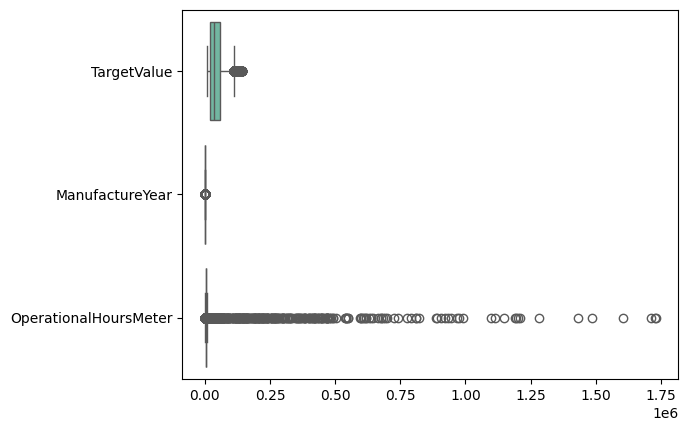

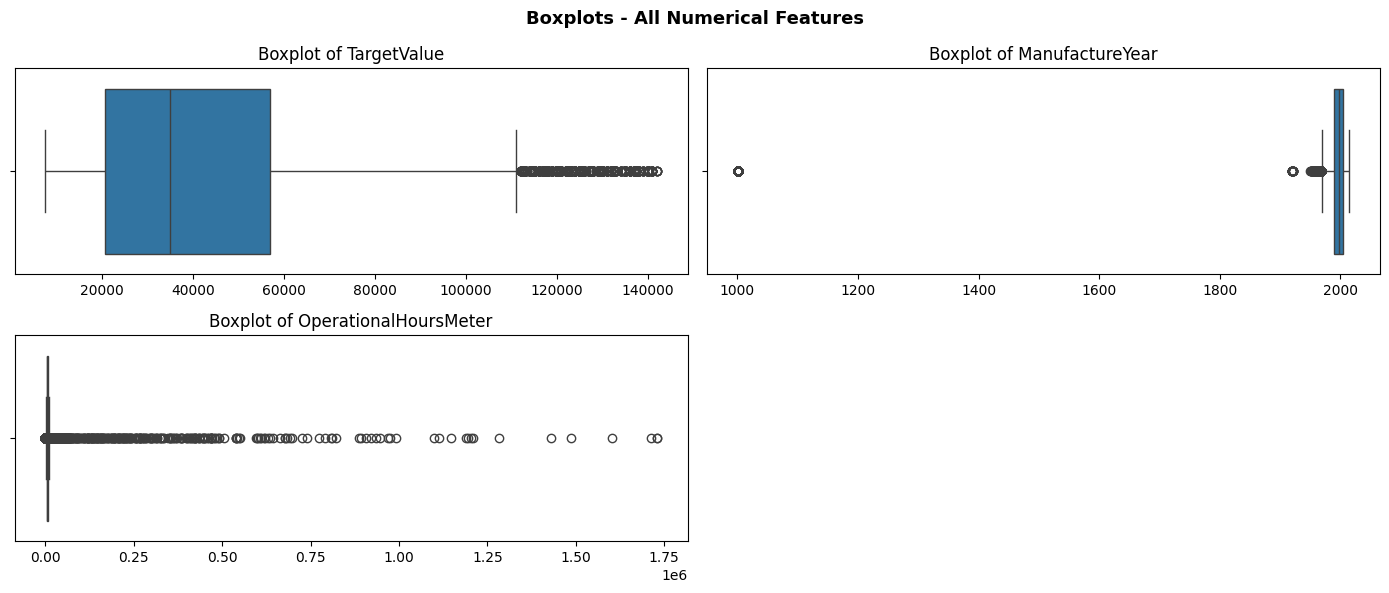

In [147]:
# --- Visualization 1: Box Plot of all numerical features ---

import math

num_cols=['TargetValue','ManufactureYear','OperationalHoursMeter'] 


# all features together
ax = sns.boxplot(data=train_clean_num[num_cols], orient="h", palette="Set2")

# Create all subplots at once in a grid
fig, axes = plt.subplots(2, 2, figsize=(14, 2 * 3))# 14 inches wide and rows*3 inches in height

# flatten() converts 2D array of axes into 1D so we can index with axes[i]
axes = axes.flatten()

for i, col in enumerate(num_cols): #0 to 3
    sns.boxplot(x=train_clean_num[col], ax=axes[i])  # ax=axes[i] sends each plot to correct subplot
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')   # removes redundant x label - title already says the column name

# Hide any unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - All Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations**

Target Value:
- price is right skewed -> normal only
- The long right tail confirms log transformation is needed before modelling.A few very expensive machines would dominate the loss function otherwise
  
ManufactureYear:
- 1001 is an outlier and one around 1900's
  
Op_hours:
- Extremely right skewed - the entire box is compressed near 0 on the left, but outliers stretch all the way to 1.75 million hours
- Most machines have relatively low recorded hours but a few have extremely high usage
- The bulk of the data (the box) - sits between roughly 2,000–6,000 hours. This is mostly imputed values since  approx (40.84(nan)+22(0s))63% of rows were imputed with group medians in that range
- The box sits near zero relative to the scale because group medians (2,000–6,000 hrs) are tiny compared to extreme real readings up to 
  1.75 million hours.
- The long right tail - real recorded values from the approx  36% of rows that had actual meter readings, some going up to 1.75 million hours.
- hours_missing flag added to let the model distinguish 
  imputed from real values.
- This confirms log transformation (OH_log) is the right approach.It will compress those extreme outliers
- Same reason we apply log to TargetValue - right skewed data with extreme outliers benefits from log transform to compress the scale and give the model a more balanced view of the data.

In [148]:
#ManufactureYear
print(sorted(train_clean_num['ManufactureYear'].unique().tolist()))
print(train_clean_num['ManufactureYear'].value_counts())
print()
print(sorted(test_clean_num['ManufactureYear'].unique().tolist()))
print(test_clean_num['ManufactureYear'].value_counts())

[1001, 1920, 1921, 1949, 1951, 1952, 1953, 1954, 1955, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]
ManufactureYear
1001    14719
2006    10895
2005     9564
1999     7243
2007     7133
        ...  
1949        1
1955        1
2013        1
2014        1
2015        1
Name: count, Length: 68, dtype: int64

[1001, 1921, 1954, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015]
ManufactureYear
1001    1580
2006    11

- 1001 is clearly an outlier - some kind of a default value
- We'll replace it with nan and impute and flag too
- Flagging bcoz a large no of rows have 1001 as the default value-> it's the highest in value counts

In [149]:
# ManufactureYear: 1001 and similar placeholder values ->NaN + flag
for (name,df) in [("Train",train_clean_num),("Test",test_clean_num)]:
    print(f"=============={name}======================")
    bad_yr = (df['ManufactureYear'] == 1001) #bool series (rows with bad yrs here 1001)
    df['year_missing'] = bad_yr.astype(int) #flag
    df.loc[bad_yr, 'ManufactureYear'] = np.nan
    print(f"replaced {bad_yr.sum()} rows' manufactureyear with nan")



# Impute ManufactureYear with group median per equipment type (train only) just like oh hours

yr_med = train_clean_num.groupby('InventoryGroupCategory')['ManufactureYear'].median() #use .round().astype(int) if not ints
print(yr_med)
yr_g   = train_clean_num['ManufactureYear'].median()

train_clean_num['ManufactureYear'] = train_clean_num['ManufactureYear'].fillna(
    train_clean_num['InventoryGroupCategory'].map(yr_med)).fillna(yr_g)

# train_clean_num['ManufactureYear'] = train_clean_num.groupby('InventoryGroupCategory')['ManufactureYear'].transform(
#     lambda x: x.fillna(x.median()))
# train_clean_num['ManufactureYear'].fillna(yr_g, inplace=True)

test_clean_num['ManufactureYear'] = test_clean_num['ManufactureYear'].fillna(
    test_clean_num['InventoryGroupCategory'].map(yr_med)).fillna(yr_g)

print("ManufactureYear nulls remaining in train :", train_clean_num['ManufactureYear'].isnull().sum())
print("ManufactureYear nulls remaining in test :", test_clean_num['ManufactureYear'].isnull().sum())

==============Train======================
replaced 14719 rows' manufactureyear with nan
==============Test======================
replaced 1580 rows' manufactureyear with nan
InventoryGroupCategory
BL     2004.0
MG     1986.0
SSL    2008.0
TEX    2000.0
TTT    2001.0
WL     2000.0
Name: ManufactureYear, dtype: float64
ManufactureYear nulls remaining in train : 0
ManufactureYear nulls remaining in test : 0


In [150]:
# #--------------------------#1 find the unique values of all categorical columns- Check for unseen categories in test--------------------------------------

# cat_cols=train_clean_num.select_dtypes(include='object').columns.tolist() 
# cat_cols = [col for col in cat_cols if col != 'TargetValue']# exclude target variable
# unseen_cols=[]
# for col in cat_cols:
    
#     print(col.upper())
#     print()
#     print(train_clean_num[col].unique())
#     print(train_clean_num[col].value_counts())

#     print("-------------------------------------------------------------")
#     #we use set so that we can easily do set A - set B
#     train_vals = set(train_clean_num[col].unique())
#     test_vals  = set(test_clean_num[col].unique())
    
#     unseen = test_vals - train_vals
#     if unseen:
#         unseen_cols.append(col)
        
#         #print(f"{col}: unseen categories in test -> {unseen}")
#         row_count=0
#         for cat in unseen:
#             test_unseen_cat_row_count=len(test_clean_num[test_clean_num[col]==cat])
#             row_count+=test_unseen_cat_row_count
#             #print(f"{cat}:    {test_unseen_cat_row_count}")
#         print(f"total rows in test with unseen categories for the col{col}: {row_count}")
#     print("-------------------------------------------------------------")
    
#     print()

# print(f"cols with unseen values in test: {unseen_cols}")


# #cols with unseen values in test: ['Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification']

### Step 9 Decisions

1. Must log-transform OPHours, TargetValue
2. Impute manufacture year -> per group median just like ophours
3. For columns with unseen test values use OHEncoder's or OrdinalEncoder's parameters (ignore , use_encoded_value)

## Step 10: Feature Engineering

### 10.1: Date Features

In [151]:
train_clean_eng=train_clean_num.copy()
test_clean_eng=test_clean_num.copy()

for df in [train_clean_eng, test_clean_eng]:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])#corece => non-parsable values -> NAT, but errors would go unnoticable
    df['SaleYear']    = df['TransactionDate'].dt.year
    df['SaleMonth']   = df['TransactionDate'].dt.month
    df['SaleQuarter'] = df['TransactionDate'].dt.quarter



### 10.2 Ordinal Encoding (new columns created)

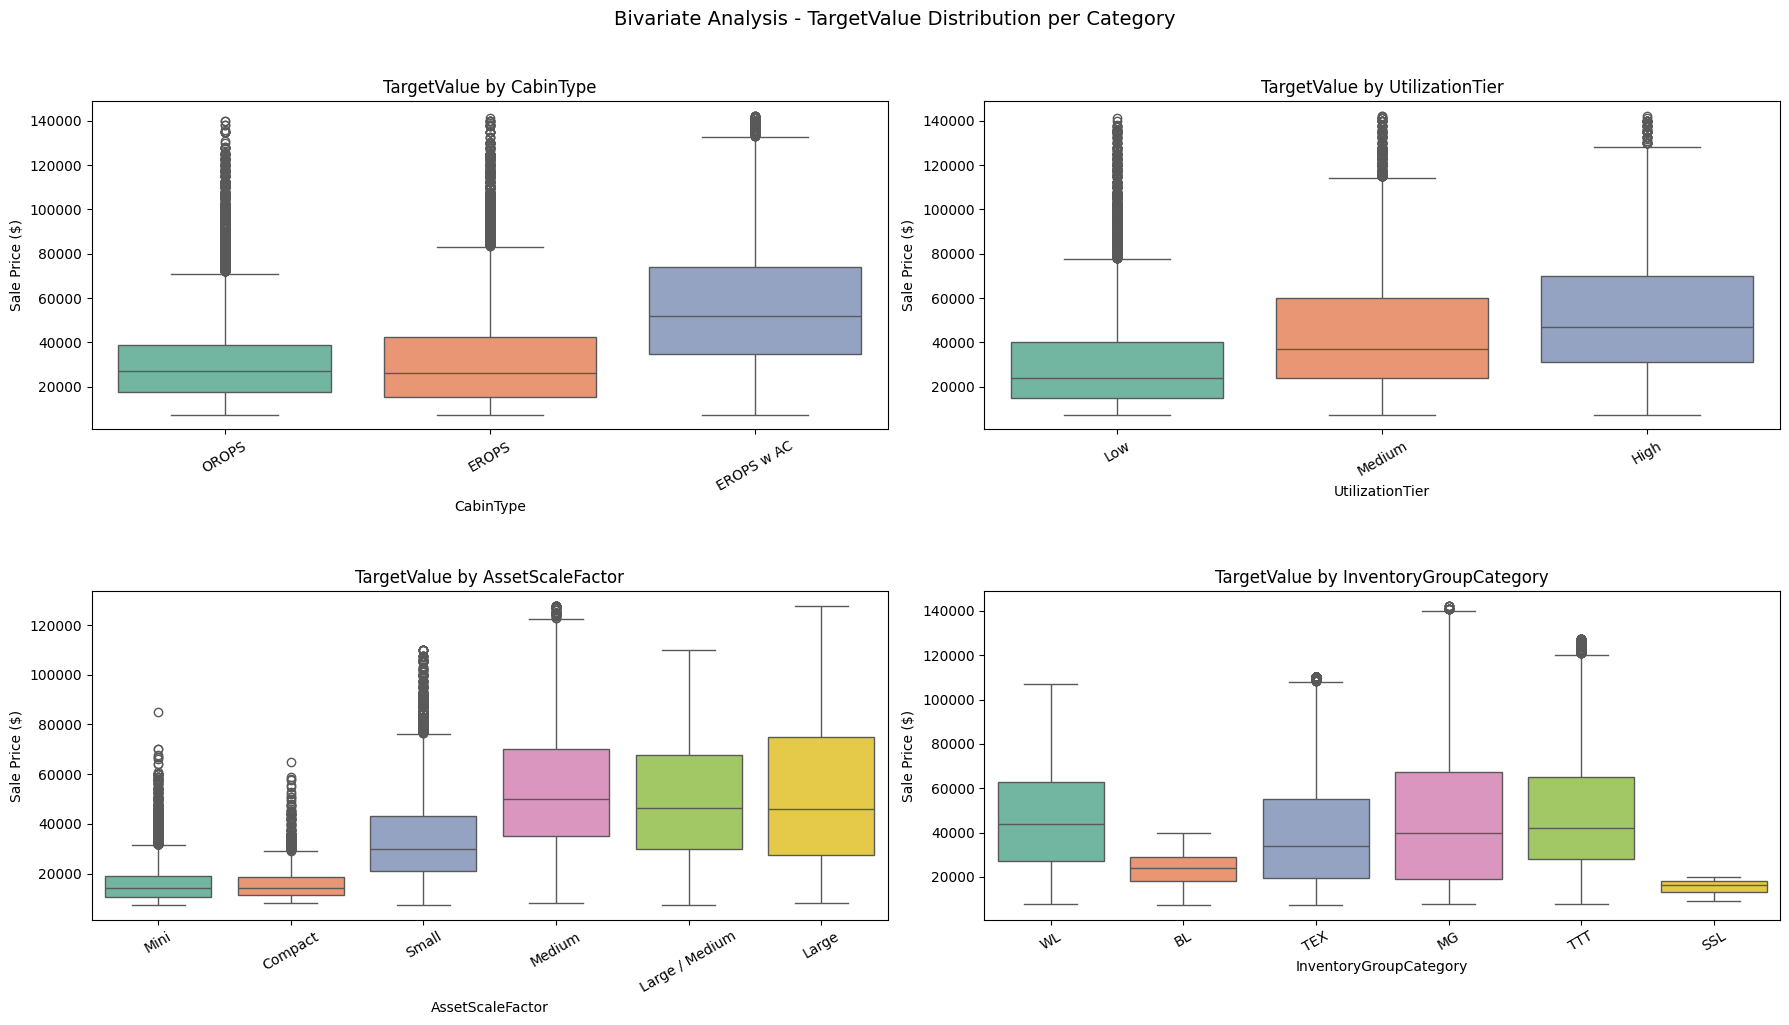

In [152]:
import warnings
warnings.filterwarnings('ignore')


#Bivariate Feature Analysis - Categorical Columns - that we will be ordinally encoding
#Further justification comes later

cat_cols_plot  =['CabinType', 'UtilizationTier', 'AssetScaleFactor', 'InventoryGroupCategory'] #these 4 are as a justification to the ordinal encoding decisions we ll be taking
orders = {
    'CabinType':           ['OROPS', 'EROPS', 'EROPS w AC'],
    'UtilizationTier':     ['Low', 'Medium', 'High'],
    'AssetScaleFactor':    ['Mini', 'Compact', 'Small', 'Medium', 'Large / Medium', 'Large'],
    'InventoryGroupCategory': None  # no specific order needed
}
n_cols = 2
n_rows = int(np.ceil(len(cat_cols_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    sns.boxplot(x=col, y='TargetValue', 
                data=train_clean_eng,
                ax=axes[i],
                order=orders[col],
                palette='Set2')
    axes[i].set_title(f'TargetValue by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sale Price ($)')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis - TargetValue Distribution per Category', 
             y=1.02, fontsize=14)
plt.tight_layout(h_pad=4)
plt.show()

In [153]:
print(train_clean_eng.groupby('UtilizationTier')['OperationalHoursMeter'].median())
print()
print(train_clean_eng.groupby('UtilizationTier')['TargetValue'].median())

UtilizationTier
High       6995.5
Low        2003.0
Medium     4534.0
missing    3893.0
Name: OperationalHoursMeter, dtype: float64

UtilizationTier
High       47000.0
Low        24000.0
Medium     37000.0
missing    36000.0
Name: TargetValue, dtype: float64


 **UtilizationTier - what it means and why we ordinal encode**

 
UtilizationTier describes how heavily a machine was used relative to its age.(how heavily the asset was used)
It is NOT raw hours - it is a relative measure.

- **Low** - machine was used less than typical for its age
- **Medium** - machine was used about as expected for its age  
- **High** - machine was used more than typical for its age

Think of it like a car mileage rating relative to age - a 5-year-old car 
with 10,000 km is Low utilization, with 80,000 km is High utilization.

 A machine that is 10 years old and has 8,000 hours is High utilization - it ran almost every working day. A machine that is 10 years old and has 1,000 hours is Low utilization - it barely worked. A machine that is 10 years old and has 4,000 hours is Medium - roughly average.
It's a comparison against the typical hours for machines of that age and type. The auctioneer or data source categorised each machine as Low, Medium, or High based on whether its hours were below, around, or above typical for similar machines.

A machine with many hours relative to its age = High utilization.
A machine with few hours relative to its age = Low utilization.

Confirmed by data:
| Tier   | Median Hours | Median Price |
|--------|-------------|--------------|
| Low    | 2,003 hrs   | 24,000      |
| Medium | 4,534 hrs   | 37,000      |
| High   | 6,996 hrs   | 47,000      |

Interestingly, High utilization machines sell for MORE - not less. This might be 
because high-utilization machines tend to be larger, more capable equipment 
that commands higher prices regardless of hours worked.

The ordering Low < Medium < High is natural and confirmed by price.
We ordinal encode as Low=1, Medium=2, High=3.

Note: UtilizationTier and OperationalHoursMeter are always recorded together -
when one is missing, the other is always missing too (0 exceptions in 138,701 rows).
This confirms they come from the same data source.

In [154]:
# Pivot table: median price per equipment type and size category
pivot = train_clean_eng.pivot_table(
    values='TargetValue',
    index='InventoryGroupCategory',
    columns='AssetScaleFactor',
    aggfunc='median'
).round(0)

print("Median Sale Price per Equipment Type and Size Category:")
display(pivot)

Median Sale Price per Equipment Type and Size Category:


AssetScaleFactor,Compact,Large,Large / Medium,Medium,Mini,Small,missing
InventoryGroupCategory,,,,,,,
BL,NaN,NaN,NaN,NaN,NaN,NaN,24000.0
MG,NaN,NaN,NaN,NaN,NaN,NaN,40000.0
SSL,NaN,NaN,NaN,NaN,NaN,NaN,16250.0
TEX,NaN,NaN,46500.0,NaN,14000.0,30000.0,11000.0
TTT,NaN,55000.0,NaN,50000.0,NaN,NaN,29000.0
WL,14000.0,33000.0,NaN,50000.0,NaN,NaN,39000.0


In [155]:
train_clean_eng.groupby('AssetScaleFactor')['TargetValue'].median()

AssetScaleFactor
Compact           14000.0
Large             46000.0
Large / Medium    46500.0
Medium            50000.0
Mini              14000.0
Small             30000.0
missing           30000.0
Name: TargetValue, dtype: float64

**AssetScaleFactor - what it means and why we ordinal encode**

AssetScaleFactor describes the physical size of the machine within its 
equipment category - Mini, Compact, Small, Medium, Large/Medium, or Large.

Bigger machines cost more to manufacture, consume more fuel, do more work, 
and command higher prices at auction. Physical size maps directly to price.

Confirmed by data:
| Size         | Median Price |
|--------------|-------------|
| Mini         | 14,000     |
| Compact      | 14,000     |
| Small        | 30,000     |
| Large / Medium | 46,500     |
| Medium       | 50,000     |
| Large        | 46,000     |

The ordering is clear: smaller machines are cheaper, larger are more expensive.
Mini and Compact have the same median price so they get the same rank (1).
Medium is slightly higher than Large/Medium in median price so Medium=3, 
Large/Medium=4, Large=5 - but this ordering is based on the size label 
meaning, not purely price.

We ordinal encode as Mini=1, Compact=1, Small=2, Medium=3, Large/Medium=4, Large=5
to preserve the natural size hierarchy as a meaningful numeric signal.

In [156]:
train_clean_eng.groupby('CabinType')['TargetValue'].median()

CabinType
EROPS         26000.0
EROPS w AC    52000.0
OROPS         27000.0
Name: TargetValue, dtype: float64

 **CabinType - what it means and why we ordinal encode**

CabinType describes the operator's cab on the machine - where the driver sits.

- **OROPS** (Open Roll-Over Protection Structure) - just a metal roll bar, 
  no walls or roof, operator exposed to weather. Basic, cheapest configuration.

- **EROPS** (Enclosed Roll-Over Protection Structure) - full enclosed cabin 
  with walls, windows, door. Weather protected, much more comfortable.

- **EROPS w AC** - same enclosed cabin with air conditioning. Premium 
  configuration, typically found on newer, larger, more expensive machines.

There is a clear comfort/feature hierarchy: OROPS < EROPS < EROPS w AC.
This natural ordering is confirmed by median sale price:
OROPS ( approx 27k) approx =  EROPS (approx 26k) << EROPS w AC (approx 52k).

The large price gap for EROPS w AC reflects not just the AC unit itself, 
but that AC-equipped machines tend to be newer and higher-spec overall.

We ordinal encode as OROPS=1, EROPS=2, EROPS w AC=3 to preserve this 
ordering - giving the model a meaningful numeric signal rather than 
arbitrary label-encoded integers.

### 10.3 Other features

(514, 55)
-0.3243868318605954


Text(0, 0.5, 'Median Price ($)')

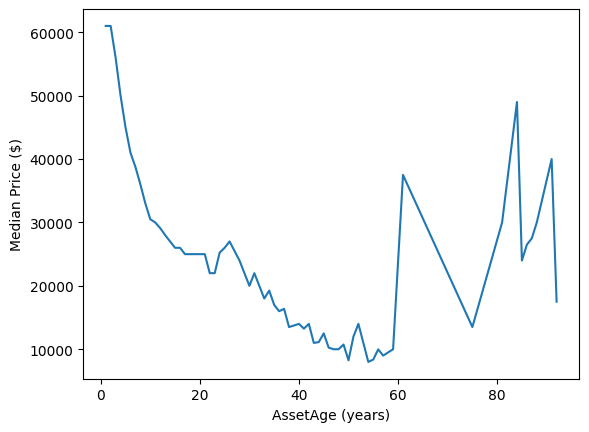

In [157]:
# AssetAge  

train_clean_eng['AssetAge']=(train_clean_eng['SaleYear'] - train_clean_eng['ManufactureYear'])
print(train_clean_eng[train_clean_eng['AssetAge']<0].shape) #514 rows have asset age < 0 ->clip them

train_clean_eng['AssetAge']=(train_clean_eng['SaleYear'] - train_clean_eng['ManufactureYear']).clip(lower=0)
#display((train_clean_eng[['AssetAge','TargetValue']].corr()))

#bcoz our model trains on log1p(targetvalue) ..what matters is how well it correlates with log price not raw price
print(train_clean_eng['AssetAge'].corr(np.log1p(train_clean_eng['TargetValue'])))

#It has a negative correlation with target price

age_price=train_clean_eng[train_clean_eng['AssetAge']>0].groupby('AssetAge')['TargetValue'].median()
# display(age_price)
plt.plot(age_price.index,age_price.values)
plt.xlabel('AssetAge (years)')
plt.ylabel('Median Price ($)')


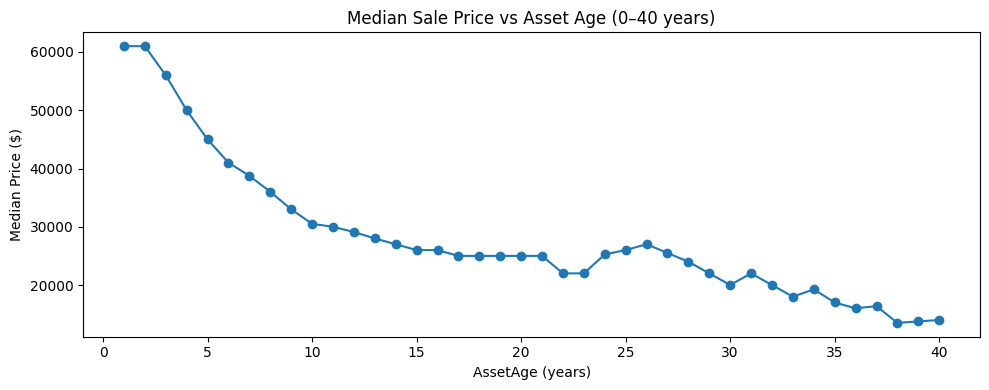

Rows with AssetAge > 40: 518 (0.4% of data)


In [158]:
# Cleaner version 
age_price = (train_clean_eng[(train_clean_eng['AssetAge'] > 0) & 
                              (train_clean_eng['AssetAge'] <= 40)]
             .groupby('AssetAge')['TargetValue'].median())

plt.figure(figsize=(10, 4))
plt.plot(age_price.index, age_price.values,marker='o')
plt.xlabel('AssetAge (years)')
plt.ylabel('Median Price ($)')
plt.title('Median Sale Price vs Asset Age (0–40 years)')
plt.tight_layout()
plt.show()

print(f"Rows with AssetAge > 40: {(train_clean_eng['AssetAge'] > 40).sum()} "
      f"({(train_clean_eng['AssetAge'] > 40).mean()*100:.1f}% of data)")

- The plot shows that newer machines generally sell for more - a machine 
that's 0–5 years old sells for around 60,000, while one that's 40+ years 
old drops to around $10,000. This makes intuitive sense, just like how 
a newer car is worth more than an older one.

- The trend is mostly downward for the first 40 years, which confirms that 
AssetAge will be a useful feature for our model.

- Beyond 50 years the prices get noisy and jump around .This seems counterintuitive but makes sense - machines that are 60-90 years old and still being auctioned are likely rare, well-maintained, or collector items commanding premium prices.- but that's just 
because very few machines are that old, so the median is based on very 
few data points and isn't reliable.

Based on this, we include AssetAge as a feature. We also clip it at 0 
to handle a few rows where ManufactureYear is somehow greater than 
SaleYear - which is clearly a data entry error.

In [159]:
#Hours per year

train_clean_eng['HoursPerYear']=train_clean_eng['OperationalHoursMeter']/train_clean_eng['AssetAge'] #will be inf for asset age ==0 and -ve if asset age is -ve
train_clean_eng['HoursPerYear'] = train_clean_eng['HoursPerYear'].replace([np.inf, -np.inf], np.nan)

print("HPY-corr with log_price")
print(train_clean_eng['HoursPerYear'].corr(np.log1p(train_clean_eng['TargetValue'])))
print(train_clean_eng['HoursPerYear'].corr(np.log1p(train_clean_eng['TargetValue']),method='spearman'))

#0.07 linear correlation
#but spearman correlation is high
print()
print(f"HoursPerYear skew: {train_clean_eng['HoursPerYear'].skew():.2f}") #log transform?
print(f"OH raw skew:       {train_clean_eng['OperationalHoursMeter'].skew():.2f}")

print("HPY_log-corr with log_price")
print()
#will have to do log transform
train_clean_eng['HPY_log'] = np.log1p(train_clean_eng['HoursPerYear'])
print(train_clean_eng['HPY_log'].corr(np.log1p(train_clean_eng['TargetValue'])))
print(train_clean_eng['HPY_log'].corr(np.log1p(train_clean_eng['TargetValue']),method='spearman'))


HPY-corr with log_price
0.06842852109930675
0.4545336803916945

HoursPerYear skew: 36.83
OH raw skew:       43.87
HPY_log-corr with log_price

0.3848801678415253
0.4545336803916945


We know AssetAge can affect price.Older machines sell for less. But does a 
10-year-old bulldozer lose the same value as a 10-year-old skid steer loader? 
Not necessarily - different equipment types depreciate differently.

To capture this, we create an interaction feature: Age × Equipment Price Rank.
This tells the model how much a machine has aged *relative to its price class*.

In [160]:
#equipment ranking

#ranking each eq category based on its median target value..ie which category sells for highest or lowest price etc..
#we could map eeach row to a rank based on the median price for the group category to which it belongs
print(train_clean_eng.groupby('InventoryGroupCategory')['TargetValue'].median())
print()
print(train_clean_eng.groupby('InventoryGroupCategory')['TargetValue'].median().rank())
eq_rank=train_clean_eng.groupby('InventoryGroupCategory')['TargetValue'].median().rank()
train_clean_eng['EqRank']    = train_clean_eng['InventoryGroupCategory'].map(eq_rank)
# display((train_clean_eng[['EqRank','TargetValue']].corr()))
print(train_clean_eng['EqRank'].corr(np.log1p(train_clean_eng['TargetValue'])))
train_clean_eng['EqRank'].isna().sum()

InventoryGroupCategory
BL     24000.0
MG     40000.0
SSL    16250.0
TEX    34000.0
TTT    42000.0
WL     44000.0
Name: TargetValue, dtype: float64

InventoryGroupCategory
BL     2.0
MG     4.0
SSL    1.0
TEX    3.0
TTT    5.0
WL     6.0
Name: TargetValue, dtype: float64
0.1983561866156685


np.int64(0)

In [161]:
#  does AssetAge correlate with price differently per equipment type?

train_clean_eng['log_price'] = np.log1p(train_clean_eng['TargetValue'])

for grp, df_grp in train_clean_eng.groupby('InventoryGroupCategory'):
    # display(df_grp)
    corr = df_grp['AssetAge'].corr(df_grp['log_price'])
    print(f"  {grp}: {corr:.4f}")
    
train_clean_eng.drop(columns=['log_price'], inplace=True)

train_clean_eng['Age_x_EqRank'] = train_clean_eng['AssetAge'] * train_clean_eng['EqRank']



  BL: -0.6000
  MG: -0.6515
  SSL: -0.2547
  TEX: -0.3587
  TTT: -0.4031
  WL: -0.3681


**Observation**
AssetAge correlates with price differently per equipment type: (though in general it has a -ve correlation with price)
- BL and MG: strong negative correlation (-0.66, -0.70) - age matters a lot (age strongly reduces price)
- SSL: weak correlation (-0.25) - age barely affects price

This means a single AssetAge feature doesn't tell the whole story. 
A 10-year-old MG loses much more value than a 10-year-old SSL.
So basically we need to combine InventoryGroupCategory with AssetAge.

**Decision: Create Age_x_EqRank interaction feature**

We rank equipment types by their median price (rank 1 = cheapest, 6 = most 
expensive) and multiply by AssetAge:

    Age_x_EqRank = AssetAge × EqRank

This gives the model a single number capturing both age AND equipment class 
in one feature. A 10-year-old TTT (rank 5) gets 50, a 10-year-old SSL 
(rank 1) gets 10 - the model can learn these have very different price impacts.

It  captures "how old is this machine relative to how expensive its type is."

SSL age 10, rank 1: Age_x_EqRank = 10  -> old cheap machine
TTT age 10, rank 5: Age_x_EqRank = 50  -> old expensive machine
SSL age 1,  rank 1: Age_x_EqRank = 1   -> new cheap machine
TTT age 1,  rank 5: Age_x_EqRank = 5   -> new expensive machine

The model learns from training data what each value means for price - we don't need to define the relationship upfront. Maybe old expensive machines sell well (collectors), maybe they sell poorly (worn out). The model figures it out from patterns in the data.

Why we create it:

Not because we know exactly what it means economically - but because:

AssetAge alone doesn't tell you what type of machine is aging
EqRank alone doesn't tell you how old the machine is
Together they give the model richer information - "old expensive machine" vs "old cheap machine" vs "new expensive machine" etc.

Two machines, both 10 years old:

SSL (cheap, rank 1):  Age_x_EqRank = 10 × 1 = 10

TTT (expensive, rank 5): Age_x_EqRank = 10 × 5 = 50

The model sees 10 vs 50 - a 5x difference - even though both machines are the same age. It can now learn:

"When this number is large -> the machine has depreciated significantly -> predict a lower price relative to its class."

Without the interaction, the model sees:

AssetAge = 10  (same for both SSL and TTT)

It can't tell from AssetAge alone whether that 10 years matters a lot or a little. It has to combine AssetAge with InventoryGroupCategory through multiple splits to figure this out.

Age_x_EqRank pre-computes this combination:

SSL age 10: 10 × 1 = 10  -> 10 years on a cheap machine
TTT age 10: 10 × 5 = 50  -> 10 years on an expensive machine

These are clearly different situations - the model gets a direct signal instead of having to discover it through multiple tree splits.

In [162]:
#DownTurn

# Median price per year - did the financial crisis affect prices?
yr_price = train_clean_eng.groupby('SaleYear')['TargetValue'].agg(
    median='median', count='count')
yr_price

,median,count
SaleYear,,
1990,31000.0,577
1991,39000.0,518
1992,43000.0,589
1993,38000.0,560
1994,40000.0,657
1995,39000.0,1338
1996,36000.0,1416
1997,37000.0,1678
1998,38000.0,1949


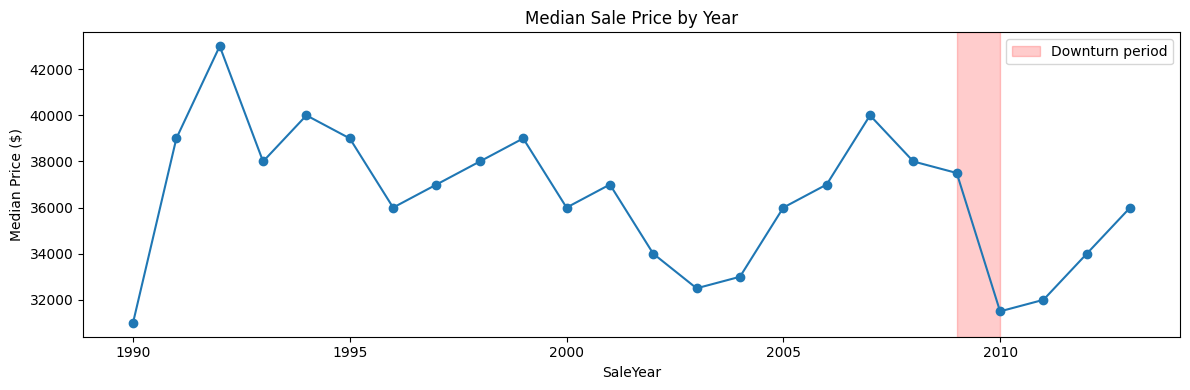

In [163]:
yr_median = train_clean_eng.groupby('SaleYear')['TargetValue'].median()

plt.figure(figsize=(12, 4))
plt.plot(yr_median.index, yr_median.values, marker='o')
plt.axvspan(2009, 2010, alpha=0.2, color='red', label='Downturn period')#axvspan = axis vertical span. It shades a vertical band on the plot between two x-values.
plt.xlabel('SaleYear')
plt.ylabel('Median Price ($)')
plt.title('Median Sale Price by Year')
plt.legend()
plt.tight_layout()
plt.show()






**Domain Knowledge**

The 2007–2009 global financial crisis (often called the Great Recession) was the most severe economic downturn since the Great Depression.

This financial crisis was triggered by the collapse of the US housing market and banking system. Construction activity dropped sharply worldwide -fewer buildings, roads, and infrastructure projects meant less demand for heavy equipment. When demand for equipment drops, auction prices drop too.
That's why we specifically checked 2009-2010 -to see if this real-world economic event left a visible signal in the auction price data. And it did - 2010 showed the sharpest single-year price drop (-16%).

In [164]:
train_clean_eng['Downturn'] = train_clean_eng['SaleYear'].isin([2009, 2010]).astype(int)

print(f"Median price in NON-downturn years: {train_clean_eng[train_clean_eng['Downturn']==0]['TargetValue'].median():,.0f}")
print(f"Median price in downturn years:     {train_clean_eng[train_clean_eng['Downturn']==1]['TargetValue'].median():,.0f}")
print(f"Correlation with log(price): {train_clean_eng['Downturn'].corr(np.log1p(train_clean_eng['TargetValue'])):.4f}")

Median price in NON-downturn years: 35,000
Median price in downturn years:     35,000
Correlation with log(price): -0.0229


**Observation**

Looking at median prices year by year, 2010 shows the sharpest 
single-year drop - from 38,000 in 2008 down to 31,500 in 2010, 
a -16% fall. This aligns with the financial crisis impact on 
construction spending.

% change = (current year - previous year) / previous year × 100
         = (31,500 - 37,500) / 37,500 × 100  (2009-2010)
         = -6,000 / 37,500 × 100
         = -16%

However, the overall median price between downturn (2009-2010) 
and non-downturn years is the same ($35,000 both). The correlation 
of the Downturn flag with log price is also very low (-0.02).

This tells us the effect is subtle - the crisis didn't uniformly 
lower all prices, but 2010 specifically had a notable dip.

**Decision**
We include the Downturn flag (SaleYear ∈ {2009, 2010} -> 1, else 0) 
as a binary feature. Even though the overall correlation is low, 
SaleYear is already the top feature in the model - the Downturn 
flag provides an additional explicit signal about this specific 
period that complements SaleYear rather than replacing it.

It appeared in feature importance with moderate score (1,746), 
confirming the model does use it even if the raw correlation is weak.

In [165]:
#FC_mid

train_clean_eng['FunctionalClassification'].unique()

array(['Wheel Loader - 150.0 to 175.0 Horsepower',
       'Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth',
       'Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons',
       'Hydraulic Excavator, Track - 3.0 to 4.0 Metric Tons',
       'Wheel Loader - 350.0 to 500.0 Horsepower',
       'Hydraulic Excavator, Track - 19.0 to 21.0 Metric Tons',
       'Hydraulic Excavator, Track - 4.0 to 5.0 Metric Tons',
       'Hydraulic Excavator, Track - 2.0 to 3.0 Metric Tons',
       'Hydraulic Excavator, Track - 24.0 to 28.0 Metric Tons',
       'Motorgrader - 45.0 to 130.0 Horsepower',
       'Wheel Loader - 200.0 to 225.0 Horsepower',
       'Hydraulic Excavator, Track - 50.0 to 66.0 Metric Tons',
       'Hydraulic Excavator, Track - 33.0 to 40.0 Metric Tons',
       'Track Type Tractor, Dozer - 130.0 to 160.0 Horsepower',
       'Wheel Loader - 275.0 to 350.0 Horsepower',
       'Motorgrader - 145.0 to 170.0 Horsepower',
       'Hydraulic Excavator, Track - 6.0 to 8.0 Metric Tons',


FunctionalClassification describes the machine type AND its size/power range:
- Track Excavators: measured in Metric Tons (weight class)
- Motorgraders: measured in Horsepower (engine power)
- Wheel Loaders: measured in Horsepower (engine power)
- Backhoe Loaders: measured in Ft Standard Digging Depth (digging capability)
- Skid Steer Loaders  -> Lb Operating Capacity (lifting capacity)
- Track Type Tractors -> Horsepower     (engine power)



Lb Operating Capacity means pounds operating capacity - how much weight the machine can lift and carry at once.

We extract the numeric midpoint (FC_mid)
from the size range - e.g. "21.0 to 24.0 Metric Tons" -> 22.5.

This gives the model a continuous numeric signal:
bigger/more powerful machine -> higher FC_mid -> higher price.

We also create FC_x_EqRank = FC_mid × EqRank, capturing that
a more powerful machine in an expensive equipment class commands
an even higher premium than the same power in a cheaper class.
Same idea as Age_x_EqRank - combining FC_mid with equipment price rank. A machine with FC_mid=22.5 in a high-priced equipment class (TTT, rank 5) is more valuable than the same FC_mid in a cheaper class. The interaction captures this.

The units are incomparable across equipment types, which is fine because the model uses FC_mid within the context of other features that already identify the equipment type.

In [166]:
def fc_mid(fc):
    nums = []
    for x in re.findall(r'[\d.]+', str(fc)): #find all numbers in the string #convert to string first coz in case its a nan, number(str(np.nan) -> 'nan' ) re fns work on strings
        nums.append(float(x)) #convert string 'x' to float 

    if len(nums) >= 2:
        return (nums[-2] + nums[-1]) / 2 
    elif nums:
        return nums[0]
    else:
        return np.nan

train_clean_eng['FC_mid'] = train_clean_eng['FunctionalClassification'].apply(fc_mid)

train_clean_eng.groupby(['InventoryGroupCategory','FC_mid'])['TargetValue'].median()
   


InventoryGroupCategory  FC_mid
BL                      7.0       17000.0
                        14.5      25000.0
                        15.5      23500.0
                        16.0      20500.0
MG                      87.5      17000.0
                                   ...   
WL                      262.5     43000.0
                        312.5     47500.0
                        425.0     32000.0
                        750.0     40000.0
                        1000.0    15000.0
Name: TargetValue, Length: 62, dtype: float64

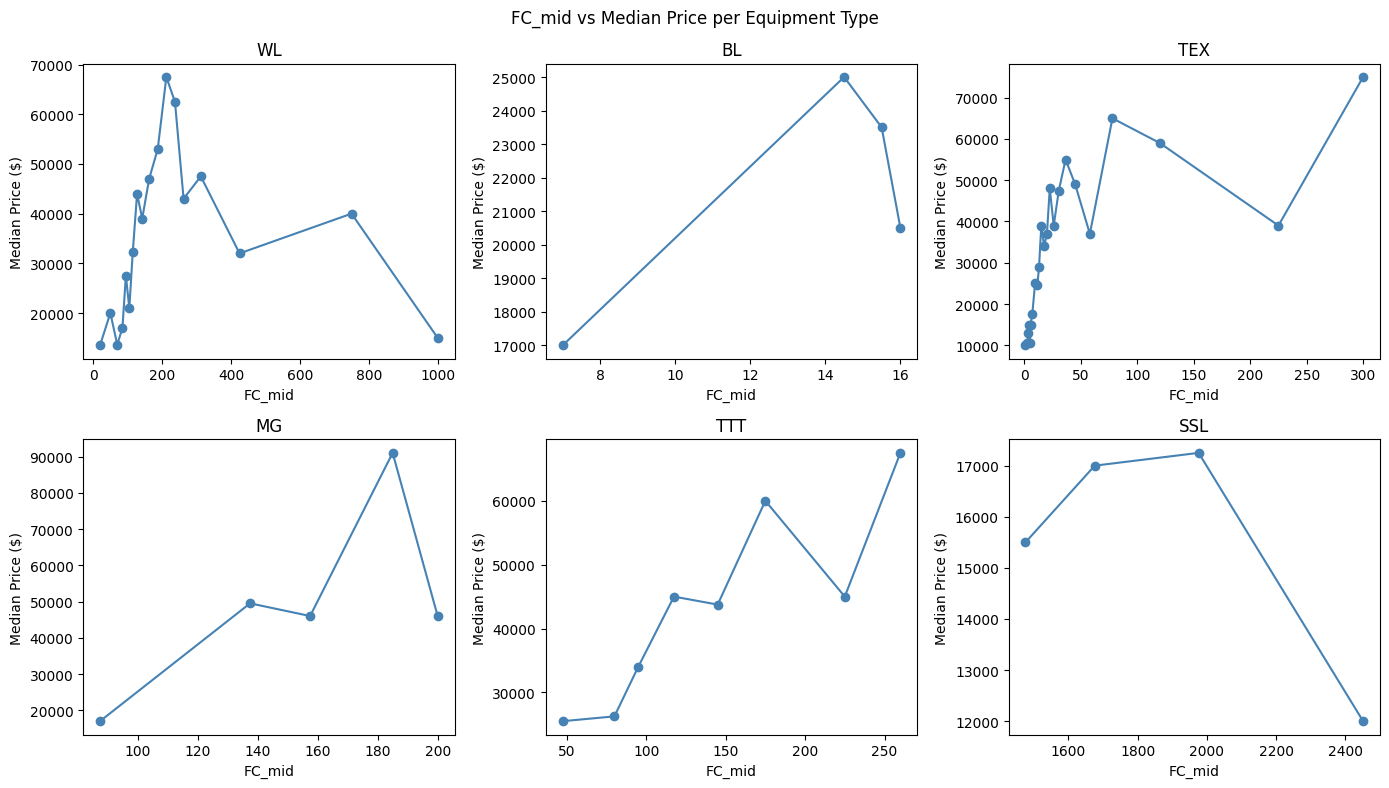

In [167]:
# Plot it per equipment type
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, grp in enumerate(
    train_clean_eng['InventoryGroupCategory'].unique()):
    
    subset = train_clean_eng[train_clean_eng['InventoryGroupCategory'] == grp]
    fc_price = subset.groupby('FC_mid')['TargetValue'].median().sort_index()
    ax=axes[i]
    ax.plot(fc_price.index, fc_price.values, marker='o', color='steelblue')
    ax.set_title(grp)
    ax.set_xlabel('FC_mid')
    ax.set_ylabel('Median Price ($)')

plt.suptitle('FC_mid vs Median Price per Equipment Type')
plt.tight_layout()
plt.show()

**FC_mid vs Median Price per Equipment Type**

**TEX (Track Excavator):** As machine weight 
increases (FC_mid = tons), price generally increases.
The general upward trend confirms FC_mid is a useful feature for TEX.

**BL (Backhoe Loader):** FC_mid here is digging depth in feet (7-16 ft).
general upward trend - deeper digging capability = higher price.

**TTT (Track Type Tractor/Bulldozer):** FC_mid is horsepower (50-260 HP).
upward trend - more powerful bulldozer = more expensive.

**MG (Motor Grader):** FC_mid is horsepower (87-200 HP).
Mostly upward with a spike at ~185 HP then a sharp drop at 200 HP.
The drop at high HP could be due to very few rows at that range 
making the median unreliable.

**WL (Wheel Loader):** FC_mid is horsepower (0-1000 HP).
Noisy relationship - rises then falls. Large WL machines (800+ HP) 
are actually cheaper in median - possibly older machines at auction.

**SSL (Skid Steer Loader):** FC_mid is in the 1500-2450 range - 
this is rated operating capacity in pounds, not HP or tons.
Relationship is non-monotonic - prices peak around 2000 then drop.

**Conclusion**
FC_mid shows a generally positive relationship with price within most 
equipment types - larger/more powerful machines tend to sell for more.
The relationship is not perfectly linear (hence LightGBM handles it 
better than Ridge Regression), but the numeric signal is useful.
We keep FC_mid as a feature and also create FC_x_EqRank to combine 
size signal with equipment class.

In [168]:
train_clean_eng['FC_x_EqRank'] = train_clean_eng['FC_mid'].fillna(0) * train_clean_eng['EqRank']

In [169]:
#contact width
print(train_clean_eng['ContactWidth'].unique())
display(train_clean_eng[(train_clean_eng['ContactWidth']=='missing')|(train_clean_eng['ContactWidth']=='None or Unspecified')]['InventoryGroupCategory'].value_counts())
# display(train_clean_eng[(train_clean_eng['ContactWidth']=='missing')]['InventoryGroupCategory'].value_counts())
# display(train_clean_eng[(train_clean_eng['ContactWidth']=='None or Unspecified')]['InventoryGroupCategory'].value_counts())

['missing' 'None or Unspecified' '16 inch' '32 inch' '30 inch' '28 inch'
 '22 inch' '18 inch' '24 inch' '36 inch' '20 inch' '27 inch' '15 inch'
 '26 inch' '34 inch' '33 inch' '14 inch' '31 inch' '25 inch']


InventoryGroupCategory
TEX    56912
MG     23405
WL     18872
TTT    14959
BL     10381
SSL       66
Name: count, dtype: int64

ContactWidth is the width of the tracks on a tracked machine (like an excavator or bulldozer).

Tracked machines move on two continuous rubber or metal tracks instead of wheels - like a tank. The contact width is how wide those tracks are.
Wider tracks = more surface area touching the ground = better for soft/muddy terrain (less sinking). Narrower tracks = better for hard surfaces and urban work.

It's measured in inches:
20 inch -> narrow tracks (compact machines, hard ground)
28 inch -> medium tracks
36 inch -> wide tracks (large machines, soft ground)

Why it might affect price:
Wider tracks are typically found on larger, more capable machines - so ContactWidth indirectly signals machine size and capability, similar to FC_mid. A machine with 36-inch tracks is generally bigger and more expensive than one with 20-inch tracks.

In [170]:


#we can convert them to numeric format
def parse_inch(v):
    if pd.isna(v) or 'Unspec' in str(v) or v == 'missing': return np.nan
    m = re.search(r'\d+', str(v))
    return int(m.group()) if m else np.nan
    
train_clean_eng['CWNum'] = train_clean_eng['ContactWidth'].apply(parse_inch)
print(train_clean_eng['CWNum'].unique())
#it has nans will have to handle for models like linear,ridge regressions


[nan 16. 32. 30. 28. 22. 18. 24. 36. 20. 27. 15. 26. 34. 33. 14. 31. 25.]


In [171]:
#fd features
train_clean_eng['Spec_FullDescriptor'].unique()

array(['950FII', '310G', '790ELC', ..., 'EC460B', '736VHP', '55N2'],
      shape=(3505,), dtype=object)

Spec_FullDescriptor is the raw machine model code - like a VIN number 
for heavy equipment. Examples:

    PC200LC6    -> Komatsu excavator, PC200 model, LC config, 6th generation
    D6T         -> Caterpillar bulldozer, D6 model, T variant
    950FII      -> Caterpillar wheel loader, 950 model, F series, 2nd gen
    WA380-6     -> Komatsu wheel loader, WA380 model, 6th generation

There are 3,505 unique FD values. Instead of just target-encoding the 
whole string, we can parse it into meaningful parts - brand prefix, 
base model number, generation series, and configuration flags.
Each part tells the model something different about the machine.


**fd_brand** - the letter prefix before the first number
  PC -> Komatsu excavator family
  D  -> Caterpillar/Komatsu dozer family  
  WA -> Komatsu wheel loader family
  NUM -> numeric-only models (950, 140G etc. - mostly Caterpillar)

**fd_base** - brand + first number = the base model
  PC200, D6, WA380, 950 - this is the core model identity.
  Same base model across generations (PC200LC6, PC200LC8) 
  should have similar price ranges.

**fd_size** - the first number in the model code
  Generally correlates with machine size/weight class.
  PC200 (200) is bigger than PC78 (78).
  D6 (6) is smaller than D9 (9).

**fd_series** - generation/series token
  -6, -8, II, III -> machine generation
  Newer generations are generally more expensive.
  PC200LC-8 (8th gen) > PC200LC6 (6th gen) in price.

**Configuration flags (binary 0/1):**
  fd_is_LC    -> Long Carriage - extended undercarriage for stability
  fd_is_LGP   -> Low Ground Pressure - wide tracks for soft terrain
  fd_is_XL    -> Extra Large variant
  fd_is_SUPER -> Super series (premium variant)
  fd_is_MR    -> Mass Excavator
  fd_is_LR    -> Long Reach - extended arm for deep digging

In [172]:
# What does a Spec_FullDescriptor look like when parsed?
sample_fds = ['PC200LC6', 'D6T', '950FII', 'WA380-6', 'D6TLGP', 'PC300LC-8']

print(f"{'FD':15s} {'Brand':8s} {'Size':6s} {'Base':12s} {'Series':8s} {'LC':5s} {'LGP':5s}") #format this value as a string (s) with a minimum width of 15 characters.
print("----------------------------------------------------------------------")
for fd in sample_fds:
    if fd in train_clean_eng['Spec_FullDescriptor'].values:
        mp = re.match(r'^([A-Za-z]+)', fd) #starting letters , re.match looks only at the start of the string
        mn = re.search(r'(\d+)', fd) #first sequence of digits anywhere in the string. , re.search looks anywhere in the string
        brand  = mp.group(1) if mp else 'NUM'#for numerical models ->brand becomes NUM
        size   = mn.group(1) if mn else 'N/A'
        base   = brand + size if mn else fd #If no number was found at all, just use the full FD string as the base
        series = 'NONE'
        for pat in [r'-(I{2,3}|VI*|IV)',            # -II, -III, -IV (roman after dash)
            r'(I{2,3}|VI*|IV)(?=[A-Z]|$)', # trailing II, III
            r'-(\d{1,2})(?=[A-Z]|$)',         # -6, -8
            r'-(I)(?=[A-Z]|$)']:               # single -I (SK120-I)

        #Try three regex patterns one by one to find the generation token:
        
        # Pattern 1: roman numerals after a dash (-II, -III, -IV)
        # Pattern 2: trailing roman numerals (FII, FIII)
        # Pattern 3: dash followed by 1-2 digits (-6, -8)
        #Pattern 4: single -I (SK120-I)
            
            m = re.search(pat, fd)
            #as soon as one matches, break
            if m: 
                series = m.group(1)
                break
        lc  = 'YES' if 'LC' in fd else 'NO'
        lgp = 'YES' if 'LGP' in fd else 'NO'
        print(f"{fd:15s} {brand:8s} {str(size):6s} {base:12s} {series:8s} {lc:5s} {lgp:5s}")




FD              Brand    Size   Base         Series   LC    LGP  
----------------------------------------------------------------------
PC200LC6        PC       200    PC200        NONE     YES   NO   
950FII          NUM      950    NUM950       II       NO    NO   
WA380-6         WA       380    WA380        6        NO    NO   



**Regex**

[] vs () in regex:

[] - character class - matches any ONE character from the set inside.

[A-Za-z]  -> matches any single letter (A or B or C... or a or b...)

[\d.]     -> matches any single digit OR a dot

[abc]     -> matches either a, b, or c - just one character

() - group - captures whatever matches inside as a unit.

(ABC)     -> matches the exact sequence ABC and captures it

(\d+)     -> matches one or more digits and captures the whole thing

**Key difference:**

[ABC]  -> matches A or B or C         (one character from the set)

(ABC)  -> matches A then B then C     (the exact sequence)

Now the 3 series patterns explained clearly:

**Pattern 1: r'-(I{2,3}V?|VI\*|IV)'**

Matches roman numerals after a dash.

Breaking it down:
   firts one is literal dash character
      
(           -> start capturing group

  I{2,3} -> I repeated 2 or 3 times
  
              II, III
              
  |         -> OR
  
  VI*       -> V followed by zero or more I's
  
              V, VI, VII, VIII
              
  |         -> OR
  
  IV        -> literal IV
  
)           -> end capturing group

**Examples:**

'WA380-III'  -> matches '-III'  -> captures 'III'

'PC200-IV'   -> matches '-IV'   -> captures 'IV'

'D6-II'      -> matches '-II'   -> captures 'II'

'PC200LC6'   -> no match

**Pattern 2:r'(I{2,3}|VI*|IV)(?=[A-Z]|$)'**

Same roman numerals but WITHOUT a dash - appearing at the end of the string or before an uppercase letter.

New part:

(?=[A-Z]|$)  -> lookahead - the roman numeral must be followed by
                 either an uppercase letter, OR end of string
                 (but the lookahead itself is not captured)
                 
**Examples:**

'950FII'    -> finds 'II' followed by end of string -> captures 'II'

'320BLII'   -> finds 'II' at end -> captures 'II'

'PC200IIX'  -> 'II' followed by 'X' (uppercase) -> captures 'II'

'D6TIII'    -> finds 'III' at end -> captures 'III'

Why the lookahead? Without it, the I in 'USLC' or 'FII' might match mid-string incorrectly. The lookahead ensures the roman numeral is at a word boundary position.


**Pattern 3: r'-(\d{1,2})(?=[A-Z]|$)'**

Matches a dash followed by 1 or 2 digits, which represent a generation number.

Breaking it down:

first one is a literal dash
       
(           -> start capturing group

  \d{1,2}  -> one or two digits (1-99)
  
)           -> end capturing group

(?=         -> lookahead (not captured)

  [A-Z]  -> followed by uppercase letter 
  
  |         -> OR
  
  $         -> end of string
  
)
**Examples:**

'WA380-6'    -> dash + '6' + end of string -> captures '6'

'PC200LC-8'  -> dash + '8' + end of string -> captures '8'

'GD675-3'    -> dash + '3' + end of string -> captures '3'

'PC200-10E'  -> dash + '10' + 'E' (uppercase) -> captures '10'

'D6T'        -> no dash before digits -> no match

**Pattern 4: single -I (SK120-I)**

Why four patterns and not one?

Because generation tokens appear in different forms across different machine brands:

Komatsu:    WA380-6    -> dash-number    -> Pattern 3

Caterpillar: 950FII    -> trailing roman -> Pattern 2  

Others:     WA380-III  -> dash-roman     -> Pattern 1

No single pattern covers all three conventions, so we try them in order and stop at the first match.\



In [173]:
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'LC', regex=True, na=False)]['Spec_FullDescriptor'].unique())
# print()
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'LGP', regex=True, na=False)]['Spec_FullDescriptor'].unique())

# print()
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'XLT?(?=[A-Z_]|$)', regex=True, na=False)]['Spec_FullDescriptor'].unique())
# print()
# #XLVP is also XL + VP --> its a genuine XL ,lly XLTSERIES is XLT
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'XLT?', regex=True, na=False)]['Spec_FullDescriptor'].unique())

# print()
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'MR', regex=True, na=False)]['Spec_FullDescriptor'].unique())
# print()
# print(train_clean_eng[train_clean_eng['Spec_FullDescriptor'].str.contains(r'LR', regex=True, na=False)]['Spec_FullDescriptor'].unique())

In [174]:


# extracting from fd_column
# FD features 
def add_fd_features(df):
    df = df.copy()
    def parse(fd):
        fd = str(fd).strip() #strip whitespaces
        m_pre = re.match(r'^([A-Za-z]+)', fd)
        m_num = re.search(r'(\d+)', fd)
        brand = m_pre.group(1) if m_pre else 'NUM'
        size  = int(m_num.group(1)) if m_num else np.nan
        base  = (brand + m_num.group(1)) if m_num else fd
        series = 'NONE'
        for pat in [r'-(I{2,3}|VI*|IV)', r'(I{2,3}|VI*|IV)(?=[A-Z]|$)',
                    r'-(\d{1,2})(?=[A-ZE]|$)']:
            m = re.search(pat, fd)
            if m: series = m.group(1); break
        flags = {
            # LC, LGP, SUPER - simple 'in' check is enough because:
            # - 'LC' is distinctive, won't appear accidentally in other contexts
            #   (USLC, NLC etc. all genuinely ARE LC-family configs)
            # - 'LGP' is a unique 3-letter combo - very unlikely false matches
            # - 'SUPER' is a full word - won't appear as a substring of something else
            
            'fd_is_LC':    int('LC'    in fd),
            'fd_is_LGP':   int('LGP'   in fd),
            'fd_is_SUPER': int('SUPER'  in fd),
            
            # XL/XLT is a config suffix added AFTER the base model (e.g. D5GXL, 850KXLT)
            # NOT a brand prefix like XL2200 where XL IS the model name
            # lookahead (?=[A-Z_]|$) ensures XL is only matched at end of string
            # or before an uppercase letter - not when followed by a digit
            # so XL2200 -> no match (XL followed by '2') 
            # but D5GXL -> match (XL at end of string)
            
            'fd_is_XL':    int(bool(re.search(r'XLT?(?=[A-Z]|$)', fd))), #XL or XLT at the end or followed by caps , here either a match obj or none is returned
            

            
            # Fix: MR must be followed by non-letter or end of string
            # This correctly catches PC40MR, PC40MR-1 but NOT PC27MRX (different variant though is MR family, but only 8 rows belonging to that class )
            'fd_is_MR':    int(bool(re.search(r'MR(?=[^A-Za-z]|$)', fd))),
        
            # Same fix for LR - catches CX240LR, JS220LR but not LRRC or similar
            'fd_is_LR':    int(bool(re.search(r'LR(?=[^A-Za-z]|$)', fd))),
        }
        return brand, base, size, series, flags  #return 'PC', 'PC200', 200, 'NONE', {'fd_is_LC':1, 'fd_is_LGP':0, ...} <- one row of spec_fd colm's otput
    res = df['Spec_FullDescriptor'].apply(parse)
    df['fd_brand']  = res.apply(lambda x: x[0])
    df['fd_base']   = res.apply(lambda x: x[1])
    df['fd_size']   = res.apply(lambda x: x[2])
    df['fd_series'] = res.apply(lambda x: x[3])
    for flag in ['fd_is_LC','fd_is_LGP','fd_is_XL','fd_is_SUPER','fd_is_MR','fd_is_LR']:
        df[flag] = res.apply(lambda x: x[4][flag])
    return df

train_clean_eng = add_fd_features(train_clean_eng)
    

**Configuration flags extracted from Spec_FullDescriptor**

Heavy equipment models often have configuration suffixes in their 
model code that indicate special variants. We extract these as 
binary flags (1 = has this config, 0 = doesn't).

**LC - Long Carriage**
The undercarriage (the track frame beneath the machine) is longer 
than standard. Longer undercarriage = more stable on uneven ground.
Common on excavators working on slopes or soft terrain.
Example: PC200LC6 -> standard PC200 but with long carriage.

**LGP - Low Ground Pressure**
Wider tracks than standard, spreading the machine's weight over 
a larger area. Like snowshoes for heavy equipment - prevents the 
machine from sinking into soft/muddy ground.
Common on machines working in swamps, marshes, or soft soil.
Example: D6TLGP -> D6T bulldozer with wide low-pressure tracks.

**XL / XLT - Extra Large**
A larger or heavier duty variant of the base model.
More capacity, more power, higher price.

**MR - Mass Excavator**
A heavy-duty excavator designed for mass earthmoving - moving 
large volumes of material quickly. Bigger bucket, stronger arm.

**LR - Long Reach**
Extended arm configuration - the boom and stick are longer than 
standard, allowing the machine to reach further or dig deeper.
Used for dredging, deep excavation, or working over water.

**SUPER - Super Series**
A premium variant of the base model - upgraded engine, better 
fuel efficiency, or improved specifications compared to standard.
Manufacturers use "Super" to denote their top-tier version 
within a model family.
Example: D65EX-SUPER -> premium version of the D65 bulldozer.


These flags matter for price - a machine with LC, LGP, or LR 
config is a specialist variant that typically sells for more 
than the standard version of the same base model.

### The Ground Parts (Tracks & Base)

**LC - Long Carriage**
The tracks on the ground are extra-long - like standing with your 
feet spread wide apart. Gives the machine excellent balance so it 
doesn't tip over when lifting heavy loads.

**LGP - Low Ground Pressure**
Tracks are both extra-long and extra-wide - like wearing snowshoes 
on soft mud. Spreads the machine's weight across a huge area, 
preventing it from sinking into swamps, marshy wetlands, or soft ground.

**XL - Extra Long**
Track base is slightly longer than standard, but not as heavy-duty 
as LC. A middle-ground between a normal machine and a giant one - 
gives extra stability for general construction without making the 
machine too big to transport on a regular truck.

**XLT - Extra Long Track**
Almost identical to XL but emphasises that more of the track is 
physically touching the ground - like wearing longer boots for 
better grip. Used mostly for bulldozers and certain excavator brands. 
Provides extra traction when pushing heavy loads uphill or across 
slippery mud.

---

### The Digging Parts (Arms & Body)

**LR - Long Reach**
The digging arm is stretched out to be very long - like using a 
super-long selfie stick instead of holding the camera in your hand. 
Allows the machine to sit safely on dry land while cleaning out 
deep riverbeds, lakes, or tall hillsides from far away.

**MR - Medium Reach / Midi Range**
Can mean two things depending on the brand:
1. **Medium Reach** - a digging arm longer than normal but not as 
   long as Long Reach. Good balance between reach and stability.
2. **Midi Excavator** - a medium-sized machine body (typically 5-10 
   tons). Bigger than a mini excavator but smaller than highway 
   construction machines.

In both cases it represents the "medium" option - perfect for tight 
city streets where you need good digging power but can't fit a 
giant machine.

**SUPER - Super Series**
A premium, higher-specification variant of the base model. Typically 
has a more powerful engine, better fuel efficiency, or improved 
hydraulics compared to the standard version.

In [175]:
# Do configuration flags actually affect price?
log_y = np.log1p(train_clean_eng['TargetValue'])

print("Configuration flag impact on median price:")
print()
for flag, name in [('fd_is_LC','Long Carriage'), ('fd_is_LGP','Low Ground Pressure'),
                   ('fd_is_XL','Extra Large'), ('fd_is_SUPER','Super series'),('fd_is_MR',    'Mass Excavator'),
                   ('fd_is_LR',    'Long Reach')]:
    if flag in train_clean_eng.columns:
        grp = train_clean_eng.groupby(flag)['TargetValue'].agg(['median','count'])
        display(grp)
        no_flag  = grp.loc[0, 'median'] if 0 in grp.index else 0
        yes_flag = grp.loc[1, 'median'] if 1 in grp.index else 0
        count    = grp.loc[1, 'count']  if 1 in grp.index else 0
        diff_pct = (yes_flag - no_flag) / no_flag * 100 #no_flag is the base - the price of a standard machine without this config
        #Using no_flag as the base makes sense because it's the reference point - the standard machine is what you're comparing against. A machine with LC config sells for 18% MORE than a standard machine -> (40k - 34k) / 34k × 100 = +18%.
        print(f"  {flag} ({name}):  {count:,} machines")
        print(f"    Without: ${no_flag:,.0f}  ->  With: ${yes_flag:,.0f}  ({diff_pct:+.1f}%)")# + adds sign
        print()

Configuration flag impact on median price:



,median,count
fd_is_LC,,
0,34000.0,114066
1,40000.0,24635


  fd_is_LC (Long Carriage):  24,635 machines
    Without: $34,000  ->  With: $40,000  (+17.6%)



,median,count
fd_is_LGP,,
0,35000.0,132739
1,42000.0,5962


  fd_is_LGP (Low Ground Pressure):  5,962 machines
    Without: $35,000  ->  With: $42,000  (+20.0%)



...

  fd_is_SUPER (Super series):  1,212 machines
    Without: $35,000  ->  With: $24,000  (-31.4%)



,median,count
fd_is_MR,,
0,35000.0,138063
1,17000.0,638


  fd_is_MR (Mass Excavator):  638 machines
    Without: $35,000  ->  With: $17,000  (-51.4%)



,median,count
fd_is_LR,,
0,35000.0,138665
1,63000.0,36


  fd_is_LR (Long Reach):  36 machines
    Without: $35,000  ->  With: $63,000  (+80.0%)



- fd_is_LC: machines with Long Carriage sell for ~18% MORE 
  LC means extended undercarriage - more stable, more capable, premium config
  
- fd_is_LGP: machines with Low Ground Pressure sell for ~20% MORE 
  LGP means wide tracks for swampy/soft terrain - specialist premium config

These flags carry real price signal even though they're simple binary 0/1 
features - a machine with LC or LGP config commands a clear price premium.

**Decision**
We extract all six configuration flags as binary features.
fd_base is target-encoded (high cardinality).
fd_size is kept as a continuous numeric feature.
fd_series,fd_brand are kept as a low-cardinality categorical (ordinal encoded).

### Step 10 - Final Decisions

- 3 ord_columns - fixed map -> can be done before split
- eqrank,and 2 columns based on that -> based on median values -> so must be done after split
- asserage,ohlog columns -> dependent on mfyear and ohhours that require imputation (median per group) -> must be done after split
- downturn -> can be added before split, no leakage, just a binary column based on slaeyear
- numeric feature extraction -> fc_mid,cwnum -> can be done before split
- fd_features ->  also can be done before split -> no leakage 

In [176]:
new_cols = ['Util_ord', 'Scale_ord', 'Cabin_ord', 'EqRank', 'AssetAge', 
            'OH_log', 'HoursPerYear', 'HPY_log', 'Age_x_EqRank', 'Downturn', 
            'FC_mid', 'CWNum', 'fd_brand', 'fd_base', 'fd_size', 'fd_series',
            'fd_is_LC', 'fd_is_LGP', 'fd_is_XL', 'fd_is_SUPER', 
            'fd_is_MR', 'fd_is_LR']

train_clean_eng.drop(columns=[c for c in new_cols if c in train_clean_eng.columns],inplace=True)
                     
# Ordinal encoding -> note util and scale have "missing" category they will be assigned 0 by the fillna(..)
#also if test has categories not in train for these colms they also will be assigned 0 as they will not be in the maps we created below from train
#but for these 3 colms no such issues of missing categories in train when compared to test
# 'missing' values ie nan Utier and AScale only

util_ord  = {'Low': 1, 'Medium': 2, 'High': 3} #natural ordering
scale_ord = {'Mini': 1, 'Compact': 1, 'Small': 2, 'Medium': 3, 'Large / Medium': 4, 'Large': 5} #natural ordering
cabin_ord = {'OROPS': 1, 'EROPS': 2, 'EROPS w AC': 3} #feature hierarchy


# adding the above features
# Equipment price rank from train (used to build Age_x_EqRank interaction)
eq_rank = train_clean_eng.groupby('InventoryGroupCategory')['TargetValue'].median().rank().to_dict()

for df in [train_clean_eng, test_clean_eng]:
    df['Util_ord']  = df['UtilizationTier'].map(util_ord).fillna(0) #missing category naturally gets 0 ..coz missing category wont have a value to be mapped, hence mapped to nans
    df['Scale_ord'] = df['AssetScaleFactor'].map(scale_ord).fillna(0)
    df['Cabin_ord'] = df['CabinType'].map(cabin_ord).fillna(0)
    df['EqRank']    = df['InventoryGroupCategory'].map(eq_rank).fillna(3)
    # {'BL': 2, 'MG': 3, 'SSL': 1, 'TEX': 4, 'TTT': 6, 'WL': 5}
   # There are only 6 equipment types in train. If test had a 7th equipment type not seen in train, .map(eq_rank) would return NaN for those rows - the key doesn't exist in the dictionary.
    #fillna(3) fills those NaN rows with 3 - the middle rank value (since ranks go 1 to 6).
    #Why 3 ?  ->  It's the middle of the range - a neutral "average" assumption. We don't know if an unseen equipment type is cheap or expensive, so we assume it's somewhere in the middle rather than extreme (1 or 6).
    
    
    df['AssetAge']  = (df['SaleYear'] - df['ManufactureYear']).clip(lower=0)
    df['OH_log']    = np.log1p(df['OperationalHoursMeter']) #taking log as it is right skewed
    
    # Interaction: how much has this machine aged relative to its price class
    df['Age_x_EqRank'] = df['AssetAge'] * df['EqRank']
    df['Downturn']  = df['SaleYear'].isin([2009, 2010]).astype(int) 

    #not helping ->score decreased..maybe try keeping only one of the below cols
    df['HoursPerYear'] = df['OperationalHoursMeter'] / df['AssetAge']
    df['HoursPerYear'] = df['HoursPerYear'].replace([np.inf, -np.inf], np.nan).fillna(0)
    df['HPY_log'] = np.log1p(df['HoursPerYear'])
    # df.drop(columns=['HoursPerYear','OperationalHoursMeter'],inplace=True)




# FC_mid: numeric midpoint from FunctionalClassification
# e.g. "Wheel Loader - 150.0 to 175.0 Horsepower" -> 162.5
def fc_mid(fc):
    nums = []
    for x in re.findall(r'[\d.]+', str(fc)): #find all numbers in the string #convert to string first coz in case its a nan, number(str(np.nan) -> 'nan' ) re fns work on strings
        nums.append(float(x)) #convert string 'x' to float 
        

    if len(nums) >= 2:
        return (nums[-2] + nums[-1]) / 2 
    elif nums:
        return nums[0]
    else:
        return np.nan
        #nans handled by trees ..but for regression models need imputation

for df in [train_clean_eng, test_clean_eng]:
    df['FC_mid'] = df['FunctionalClassification'].apply(fc_mid)
    #new added
    df['FC_x_EqRank'] = df['FC_mid'].fillna(0) * df['EqRank'] #adding changed 0.19789 -> 0.19743




def extract_numeric_features(df):
    """Extract numeric values from string columns """
    
    df = df.copy()
    # ContactWidth -> numeric inches (e.g. '28 inch' -> 28)
    def parse_ContactWidth(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            return int(str(val).replace('inch', '').strip())
        except:
            return np.nan
    
    # def parse_inch(v):
    #     if pd.isna(v) or 'Unspec' in str(v) or v == 'missing': return np.nan
    #     m = re.search(r'\d+', str(v))
    #     return int(m.group()) if m else np.nan
    
    # Max reach: ft' in" -> decimal feet
    def parse_MaxReach(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            # matches patterns like 11' 0" or 9' 10"
            match = re.match(r"(\d+)'\s*(\d+)\"", str(val))
            if match:
                feet = int(match.group(1))
                inches = int(match.group(2))
                return round(feet + inches / 12, 4)
            return np.nan
        except:
            return np.nan

    # tire size: "23.5" or '23.5"' -> 23.5
    def parse_TireMeasurement(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            return float(str(val).replace('"', '').strip())
        except:
            return np.nan
    
    # blade width: "14'" -> 14.0, "<12'" -> 11.5
    def parse_WorkingWidth(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        val = str(val).replace("'", "").strip()
        if val.startswith('<'):
            return 11.5
        try:
            return float(val)
        except:
            return np.nan
            
    df['MaxReach_num']         = df['MaxReach'].apply(parse_MaxReach)
    df['ContactWidth_num']     = df['ContactWidth'].apply(parse_ContactWidth)
    df['TireMeasurement_num']  = df['TireMeasurement'].apply(parse_TireMeasurement)
    df['WorkingWidth_num']     = df['WorkingWidth'].apply(parse_WorkingWidth)
    # keep originals as strings - they go through encode_low_card as categoricals
    
    return df

train_clean_eng = extract_numeric_features(train_clean_eng)
test_clean_eng  = extract_numeric_features(test_clean_eng)

# FD features 
def add_fd_features(df):
    df = df.copy()
    def parse(fd):
        fd = str(fd).strip() #strip whitespaces
        m_pre = re.match(r'^([A-Za-z]+)', fd)
        m_num = re.search(r'(\d+)', fd)
        brand = m_pre.group(1) if m_pre else 'NUM'
        size  = int(m_num.group(1)) if m_num else np.nan
        base  = (brand + m_num.group(1)) if m_num else fd
        series = 'NONE'  #OR MISSING
        for pat in [r'-(I{2,3}|VI*|IV)', r'(I{2,3}|VI*|IV)(?=[A-Z]|$)',
                    r'-(\d{1,2})(?=[A-ZE]|$)']:
            m = re.search(pat, fd)
            if m: series = m.group(1); break
        flags = {
            'fd_is_LC':    int('LC'    in fd),
            'fd_is_LGP':   int('LGP'   in fd),
            'fd_is_XL':    int(bool(re.search(r'XLT?(?=[A-Z]|$)', fd))),
            'fd_is_SUPER': int('SUPER'  in fd),
            # This correctly catches PC40MR, PC40MR-1 but NOT PC27MRX (different variant though is MR family)
            'fd_is_MR':    int(bool(re.search(r'MR(?=[^A-Za-z]|$)', fd))), #not helping
        
            # Same fix for LR - catches CX240LR, JS220LR but not LRRC or similar
            'fd_is_LR':    int(bool(re.search(r'LR(?=[^A-Za-z]|$)', fd))), #not helping
        }
        return brand, base, size, series, flags
    res = df['Spec_FullDescriptor'].apply(parse)
    df['fd_brand']  = res.apply(lambda x: x[0])
    df['fd_base']   = res.apply(lambda x: x[1])
    df['fd_size']   = res.apply(lambda x: x[2])
    df['fd_series'] = res.apply(lambda x: x[3])
    for flag in ['fd_is_LC','fd_is_LGP','fd_is_XL','fd_is_SUPER','fd_is_MR','fd_is_LR']:
        df[flag] = res.apply(lambda x: x[4][flag])
    return df
train_clean_eng = add_fd_features(train_clean_eng)
test_clean_eng  = add_fd_features(test_clean_eng)

print("Feature engineering done.")
print("New columns: Util_ord, Scale_ord, Cabin_ord, EqRank, AssetAge, OH_log,HoursPerYear,HPY_log,MaxReach_num,ContactWidth_num,TireMeasurement_num,WorkingWidth_num")
print("             Age_x_EqRank, Downturn, FC_mid, CWNum,fd_brand,fd_base,fd_size,fd_series,fd_is_LC,fd_is_LGP,fd_is_XL,fd_is_SUPER,fd_is_MR,fd_is_LR")

Feature engineering done.
New columns: Util_ord, Scale_ord, Cabin_ord, EqRank, AssetAge, OH_log,HoursPerYear,HPY_log,MaxReach_num,ContactWidth_num,TireMeasurement_num,WorkingWidth_num
             Age_x_EqRank, Downturn, FC_mid, CWNum,fd_brand,fd_base,fd_size,fd_series,fd_is_LC,fd_is_LGP,fd_is_XL,fd_is_SUPER,fd_is_MR,fd_is_LR


ProductConfigID          0.001218
hours_missing            0.003892
OperationalHoursMeter    0.006860
fd_is_LR                 0.011330
sub_is_config            0.014777
fd_size                  0.019755
Downturn                 0.022927
SaleYear                 0.024602
SaleQuarter              0.030467
SaleMonth                0.033117
fd_is_SUPER              0.053804
fd_is_MR                 0.063792
fd_is_LGP                0.064676
HoursPerYear             0.068789
Util_ord                 0.078890
OH_log                   0.080290
fd_is_XL                 0.086841
fd_is_LC                 0.103417
TireMeasurement_num      0.162785
sub_is_gen               0.195088
EqRank                   0.198356
MaxReach_num             0.212316
Age_x_EqRank             0.214448
year_missing             0.226210
AssetID                  0.236165
FC_x_EqRank              0.255954
FC_mid                   0.256043
ManufactureYear          0.262277
Scale_ord                0.312836
AssetAge      

<Axes: >

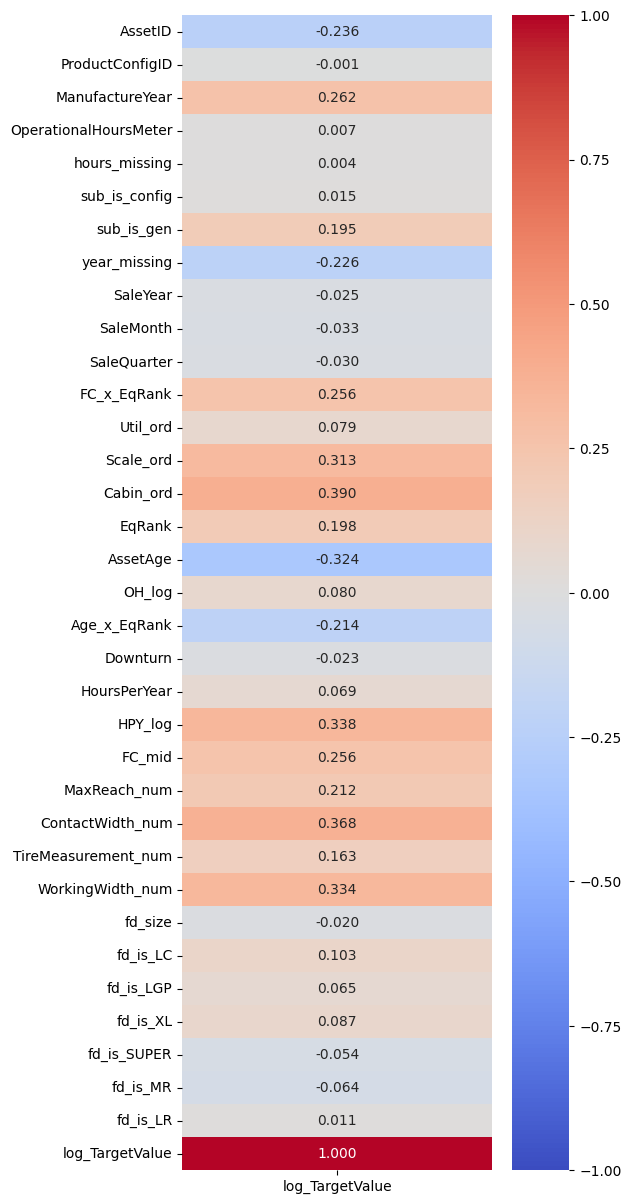

In [177]:
#Asset Age has the highest correlation (-ve) with TargetValue

#all num cols
train_clean_eng['log_TargetValue']=np.log1p(train_clean_eng['TargetValue'])

num_cols_corr=train_clean_eng.select_dtypes(include='number').columns.tolist()
num_cols_corr=[col for col in num_cols_corr if col not in['TransactionID','TargetValue']]

corr_series=(train_clean_eng[num_cols_corr].corr()['log_TargetValue']) #pearson - linear relationship
# display(corr_series.sort_values())
display((abs(corr_series).sort_values()))

plt.figure(figsize=(5,15))
# Convert 1D Series to 2D DataFrame
corr_df = corr_series.to_frame()  # makes it a single-column DataFrame
sns.heatmap(corr_df,annot=True,fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1)

- Now we see that  AssetAge ,HPY_log,WorkingWidth_num,ContactWidth_num ,Cabin_ord    have the highest correlations with log of targetvalue
- the new features we created have higher correlation with the log of target price than already existing numerical features

hours_missing            0.009113
fd_is_LR                 0.011664
sub_is_config            0.014591
Downturn                 0.021190
SaleQuarter              0.032161
SaleYear                 0.035133
SaleMonth                0.036138
Util_ord                 0.036185
fd_size                  0.041077
fd_is_LGP                0.061748
fd_is_SUPER              0.062151
fd_is_MR                 0.064494
fd_is_XL                 0.085521
fd_is_LC                 0.099861
OperationalHoursMeter    0.108057
OH_log                   0.108057
ProductConfigID          0.117951
TireMeasurement_num      0.153840
sub_is_gen               0.193663
MaxReach_num             0.194545
Age_x_EqRank             0.206882
AssetID                  0.219837
EqRank                   0.220994
year_missing             0.222073
ManufactureYear          0.233284
Scale_ord                0.299220
AssetAge                 0.341832
WorkingWidth_num         0.353517
ContactWidth_num         0.377863
FC_mid        

<Axes: >

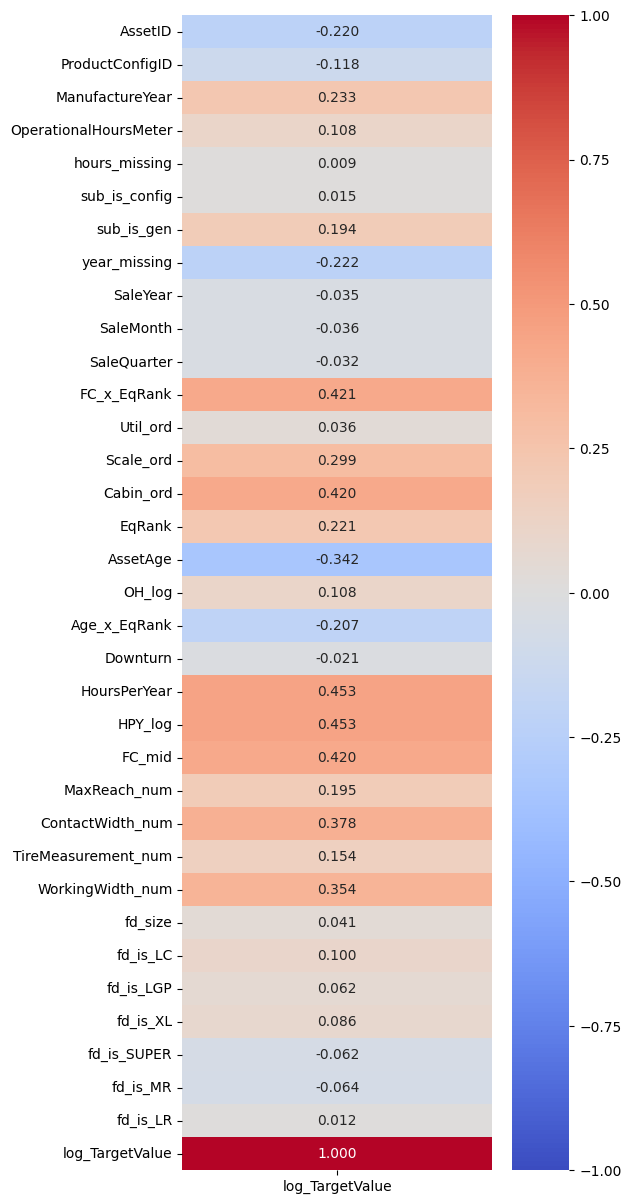

In [178]:
#Asset Age has the highest correlation (-ve) with TargetValue

#all num cols
train_clean_eng['log_TargetValue']=np.log1p(train_clean_eng['TargetValue'])

num_cols_corr=train_clean_eng.select_dtypes(include='number').columns.tolist()
num_cols_corr=[col for col in num_cols_corr if col not in['TransactionID','TargetValue']]

corr_series=(train_clean_eng[num_cols_corr].corr(method='spearman')['log_TargetValue']) #spearman - Highlights features with curved, exponential, or stepped relationships with the target (its rank based)
# display(corr_series.sort_values())
display((abs(corr_series).sort_values()))

plt.figure(figsize=(5,15))
# Convert 1D Series to 2D DataFrame
corr_df = corr_series.to_frame()  # makes it a single-column DataFrame
sns.heatmap(corr_df,annot=True,fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1)



**Pearson correlation** (which we used earlier) measures linear relationships - does Y increase in a straight line as X increases?

**Spearman correlation** measures monotonic relationships - does Y tend to increase whenever X increases, regardless of whether the relationship is a straight line?

Simple example:

X:  1,  2,  3,  4,  5
Y:  2,  5, 10, 17, 26  <- not a straight line (exponential)

Spearman works by converting values to ranks first:

X values: [100, 50, 200, 10] -> ranks: [3, 2, 4, 1]
Y values: [90,  40, 180, 8]  -> ranks: [3, 2, 4, 1]

Then computes correlation between the ranks. So it captures "does the ordering of X match the ordering of Y?" - without caring about the exact relationship shape.

Why use Spearman for your engineered features?

Features like AssetAge, have non-linear relationships with price - as we saw in the scatter plots. Spearman captures these non-linear but monotonic relationships better than Pearson.

For example AssetAge vs log price - price drops steeply at first then flattens. This is monotonic (always decreasing) but not linear. Spearman would give a stronger correlation than Pearson for this.

**Obseravtions**


- Here we see HoursPerYear/its log form has the highest correlation with target price
- Others include FC_mid ,Cabin_ord ,FC_x_EqRank 



- The non-linear yet monotonic relationship of these features with target is clearly captured by spearman correlation
- Tree models will be able to capture these non-linear relationships better


In [179]:
#Not Helping

# Frequency encoding: replace ID/code with count of appearances in train
# Safe - uses counts only, no target values -> no leakage risk

# pc_freq = train_clean_eng['ProductConfigID'].value_counts()
# fd_freq = train_clean_eng['Spec_FullDescriptor'].value_counts()
# bc_freq = train_clean_eng['Spec_BaseClass'].value_counts()

# for df in [train_clean_eng, test_clean_eng]:
#     df['pc_freq'] = df['ProductConfigID'].map(pc_freq).fillna(1)
#     df['fd_freq'] = df['Spec_FullDescriptor'].map(fd_freq).fillna(1)
#     df['bc_freq'] = df['Spec_BaseClass'].map(bc_freq).fillna(1)

# print("Frequency encoding done:")

#with these our score went from 0.19743 to 0.19755 when i just added that fd_base etc colms.. but without them 0.19638

## Step 11: Encoding Decisions

In [180]:
#deciding which columns to target encode, labelencode
train_clean_eng.drop(columns=['fd_is_LR','fd_is_MR','WorkingWidth_num','TireMeasurement_num','MaxReach_num','HPY_log','HoursPerYear','log_TargetValue'],inplace=True)
test_clean_eng.drop(columns=['fd_is_LR','fd_is_MR','WorkingWidth_num','TireMeasurement_num','MaxReach_num','HPY_log','HoursPerYear'],inplace=True)

train_final=train_clean_eng.copy()
test_final=test_clean_eng.copy()


cols=train_final.columns.tolist()
nunique=[train_final[col].nunique() for col in cols]
col_dtype=[train_final[col].dtype for col in cols]
col_unique_count=pd.DataFrame({
    "col":cols,
    "nunique": nunique,
    "dtype":col_dtype
})

# Temporarily show all rows
with pd.option_context('display.max_rows', None):
    display(col_unique_count.sort_values(by='nunique'))

# print()
# print("High Cardinality Columns: ")
# print()
# display(col_unique_count[col_unique_count['nunique']>=200])
print()
print("High Cardinality Columns: obj dtype ")
print()
display(col_unique_count[(col_unique_count['nunique']>=200)& (col_unique_count['dtype']=='object')])

,col,nunique,dtype
48,sub_is_config,2,int64
49,sub_is_gen,2,int64
50,year_missing,2,int64
62,Downturn,2,int64
47,hours_missing,2,int64
69,fd_is_LC,2,int64
71,fd_is_XL,2,int64
70,fd_is_LGP,2,int64
72,fd_is_SUPER,2,int64
46,SteeringInterface,3,object



High Cardinality Columns: obj dtype 



,col,nunique,dtype
10,Spec_FullDescriptor,3505,object
11,Spec_BaseClass,1249,object
66,fd_base,1287,object


-There is a natural gap between 1,249 (Spec_BaseClass) and 147 
(Spec_SubClass). Any threshold between 200 and 1,000 gives the 
same result. We use 200 as a clean round number that sits 
clearly in this gap.

- Among these high cardinality colms we can ignore oh_log.ophoursmeter,fd_size(already in num format),targetvalue (target),transcationid,assetid,TransactionDate (will be dropped)

- Spec_BaseClass will be dropped as fd_base performs better than it (error increase when spec base class was chosen over fd_base)

- fd_base, spec_fd must be target encoded

- also productconfigid will be target encoded

#### AssetID vs ProductConfigID - why we drop one but keep the other

**AssetID** - identity of one specific physical machine. AssetID=117665 means this exact 
physical machine.

**ProductConfigID** - identity of a machine configuration/model.
Like a car model code. ProductConfigID=1004 means "850DLT model" 
- any machine of that model type, not one specific physical machine.

| | AssetID | ProductConfigID |
|---|---|---|
| What it identifies | One physical machine | One model/config type |
| How many share the same ID | 1 (usually) | Many machines share same config |
| Signal for price | None - arbitrary number | Yes - same model = similar price |
| Unique values | 120,111 | 3,594 |

#### Why we DROP AssetID
- 120,111 unique values - almost every row is different
- The number is arbitrary (assigned sequentially, not by price or type)
- Too few machines share the same ID for target encoding to learn anything


#### Why we KEEP ProductConfigID
- 3,594 unique values - many machines share the same config
- ProductConfigID=1004 always means 850DLT - the mapping is stable
- Many rows share the same ID -> target encoding can compute a 
  reliable mean price per configuration

#### Why target encode ProductConfigID even though it looks numeric?

ProductConfigID is stored as a number (1004, 88, 3594) but the 
numbers are arbitrary labels - not quantities. ProductConfigID=3594 
does not mean "more" of anything than ProductConfigID=88. 
The difference 3594-88=3506 means nothing.

This is a nominal variable disguised as a number - same as how 
a jersey number identifies a player but #10 is not "twice as good" 
as #5. We target encode it to replace the arbitrary number with 
the actual mean log-price for that configuration.

In [181]:
train_final['AssetID'].value_counts()

AssetID
2283600    46
1896862    36
2285838    35
1746400    30
1942732    29
           ..
1393141     1
1119959     1
1259934     1
1150826     1
1178324     1
Name: count, Length: 120111, dtype: int64

For AssetIDs that appear only once (vast majority), the target encoded value IS the actual price of that machine. The model would learn:

AssetID 117665 -> encoded as 10.45 -> predict e^10.45 = $34,500

This is just memorising training prices - not learning any generalisation.

In [182]:
# Verify ProductConfigID -> Spec_FullDescriptor mapping is stable
mapping =train_final.groupby('ProductConfigID')['Spec_FullDescriptor'].nunique()
print("Unique FDs per ProductConfigID:")
print(mapping)
print()
print(mapping.value_counts()) #only 1 is the no of unique fds per pconfigid
#ie each configid is mapped to a specific fd
print()
print("Sample mapping:")
print(train_final.groupby('ProductConfigID')['Spec_FullDescriptor'].first().head(10))
print()
print(f"Max unique FDs per ProductConfigID: {mapping.max()}")

# Verify  Spec_FullDescriptor->ProductConfigID mapping
mapping =train_final.groupby('Spec_FullDescriptor')['ProductConfigID'].nunique()
print("Unique ProductConfigID per Spec_FullDescriptor:")
print(mapping)
print()
print(mapping.value_counts()) 

print()
print("Sample mapping:")
print(train_final.groupby('Spec_FullDescriptor')['ProductConfigID'].first().head(10))
print()
print(f"Max unique ProductConfigIDs per Spec_FullDescriptor: {mapping.max()}")


Unique FDs per ProductConfigID:
ProductConfigID
39       1
40       1
42       1
45       1
54       1
        ..
36939    1
36944    1
37207    1
37208    1
37209    1
Name: Spec_FullDescriptor, Length: 3594, dtype: int64

Spec_FullDescriptor
1    3594
Name: count, dtype: int64

Sample mapping:
ProductConfigID
39     226B2
40     232B2
42     242B2
45     252B2
54     416II
58     426II
64     436II
86    938GII
88    950FII
93    962GII
Name: Spec_FullDescriptor, dtype: object

Max unique FDs per ProductConfigID: 1
Unique ProductConfigID per Spec_FullDescriptor:
Spec_FullDescriptor
100C       1
1066E      1
1080       1
1080B      1
1088       1
          ..
ZX75USA    1
ZX80       1
ZX800      1
ZX800LC    1
ZX850H     1
Name: ProductConfigID, Length: 3505, dtype: int64

ProductConfigID
1    3423
2      75
3       7
Name: count, dtype: int64

Sample mapping:
Spec_FullDescriptor
100C        4956
1066E      16320
1080        6555
1080B       3081
1088        6561
1088CK     25045
1088

- so each pcid has a unique fd
- but one fd can have multiple pcid
- ie 39 -> 226B2
- but its possible that 39 -> 226B2 and also 40 -> 226B2

ProductConfigID -> Spec_FullDescriptor: always 1-to-1
Every ProductConfigID maps to exactly one model code. 

Spec_FullDescriptor -> ProductConfigID: mostly 1-to-1 but 82 exceptions
82 FDs  map to 2-3 different ProductConfigIDs.

This means the same model name can have slightly different 
configurations in the database - ProductConfigID captures these 
finer distinctions that the model code alone doesn't show.

This makes ProductConfigID more granular than Spec_FullDescriptor 

ProductConfigID (most specific - 3,594 unique) -> many-to-one  Spec_FullDescriptor (3,505 unique - slightly less specific)





In [183]:

# print(train_final['ProductConfigID'].dtype) #int64 ..so astype string in tenc will conver it to string
# print(train_final['ProductConfigID'].isnull().sum())
# print(train_final['ProductConfigID'].head(3).tolist())

# VendorPartnerID - does the auction vendor affect price?
vendor_stats = train_final.groupby('VendorPartnerID')['TargetValue'].agg(
    median='median', count='count').sort_values('median', ascending=False).round(0)

print("Median sale price per auction vendor:")
print(vendor_stats.to_string())
print()
print(f"Highest median vendor (HJW): ${vendor_stats['median'].max():,.0f}")
print(f"Lowest  median vendor (LKQ): ${vendor_stats['median'].min():,.0f}")
print(f"Price gap across vendors:    ${vendor_stats['median'].max() - vendor_stats['median'].min():,.0f}")


Median sale price per auction vendor:
                  median  count
VendorPartnerID                
HJW              51000.0    552
SLT              42500.0   2667
DLC              42000.0   2570
RKC              40000.0    207
EVS              40000.0    918
SND              38000.0   2461
RGK              37600.0    185
AFZ              37500.0    223
UJF              37000.0  67828
MHV              36250.0    378
TAI              36000.0    460
RZI              35500.0   1597
SGU              33500.0    114
HCL              33500.0   5753
GTX              33500.0  18231
MPF              33000.0  15187
UNKNOWN_VENDOR   32500.0   6549
MNJ              32000.0   2466
NTE              30000.0    477
MNT              29500.0   3786
SQU              28000.0    628
MBO              28000.0    483
VJC              28000.0    995
CBS              26500.0    319
IMS              26250.0    284
LQO              26000.0   1127
QUG              25000.0   1181
RVF              24750.0    230
GM

In [184]:
from sklearn.preprocessing import TargetEncoder,OrdinalEncoder

print(f"train_final shape: {train_final.shape}")
print(f"test_final shape: {test_final.shape}") #wont have targetvalue

print(train_renamed.columns,len(train_renamed.columns))
print(train_final.columns,len(train_final.columns))

TARGET = 'TargetValue'

# Columns to target-encode (high cardinality - fit inside fold to avoid leakage)




# Columns to drop entirely from features
DROP = ['TransactionID', TARGET,'TransactionDate', 'AssetID','Spec_BaseClass'] #added specbase_class to drop


feat = [c for c in train_final.columns if c not in DROP] #73-5=68


#convert productconfigid to  -> will be done by tenc
TARGET_ENC = ['Spec_FullDescriptor', 'fd_base', 'ProductConfigID'] #removed spec_base_class #3

#VendorPartnerID has only 31 unique values - technically low cardinality enough for label encoding. But we target encode it because it has meaningful price signal (different auction houses sell at different price levels). Target encoding captures that signal directly.

num_colms=[c for c in feat if c not in ['ProductConfigID'] and train_final[c].dtype in ['int32','int64','float64']] #25
print(num_colms)
print(len(num_colms))

# Ordinal encode  low-cardinality string columns (stable across splits, no target used)
LOW_CARD = [c for c in feat
            if train_final[c].dtype in ['object', 'string']
            and c not in TARGET_ENC
            and train_final[c].nunique() <= 200] #68-3-25=68-29=40

print(len(LOW_CARD))
print((LOW_CARD))

#25 (num colms excluding productconfigid, including newly created colms, ord colms etc ) + 3 (tenc colms) + 40 (low cardinality colms which also includes the cat colms that were num encoded,the ones from which numbers were extracted) = 68 features


#cols with unseen values in test: ['Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification']
#newly built colms may also have unseen categories in test



train_final shape: (138701, 73)
test_final shape: (15000, 72)
Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'DriveConfig', 'CabinType', 'Forks',
       'StabilizerType', 'ArmLayout', 'DrivetrainType', 'EngineAspiration',
       'ExtensionModuleType', 'WorkingWidth', 'ProtectiveHousing',
       'RatedPower', 'HydraulicSystemType', 'SuspensionType',
       'PiercingAccessory', 'FinishingAccessory', 'ActuatorControlType',
       'TireMeasurement', 'CouplingType', 'TractionSystem', 'FluidFlowRate',
       'TreadPattern', 'ContactWidth', 'MaxReach', 'RetentionInterface',
       'ControlConfigM


- UtilizationTier, CabinType, AssetScaleFactor - both ordinal encoded using ordencoder(but random order (alphabetical by default)) AND have ordinal versions (Util_ord, Cabin_ord, Scale_ord). So they're encoded twice . The model will use whichever is more useful and ignore the other.

In [185]:
tr_fnan=train_final.isna().sum()
test_fnan=test_final.isna().sum()

display(tr_fnan[tr_fnan>0])
print()
display(test_fnan[test_fnan>0])

#fc_mid,cw_num,fd_size have nans might need to impute them esp for linear models like ridge, but not necessary for trees

FC_mid                 245
ContactWidth_num    124595
fd_size                  4
dtype: int64

FC_mid                 28
ContactWidth_num    13448
dtype: int64

### Step 11 - Final Decisions

#### Data Cleaning and Imputation Decisions

#### 1. Duplicate Check
Checked for duplicate rows (excluding TransactionID). Result: 0 duplicates 
found — no rows removed.

---

#### 2. Date Parsing
TransactionDate stored as string in DD-MM-YYYY format. Parsed using 
`pd.to_datetime(dayfirst=True)` and extracted SaleYear, SaleMonth, 
SaleQuarter. TransactionDate itself dropped from features later.

---

#### 3. ManufactureYear — Sentinel Value Fix
ManufactureYear = 1001 is a system placeholder, not a real year. 

Evidence: values like 1001 are impossible manufacture years and appear 
as an isolated spike in the distribution histogram far left of all 
real years (1920-2015).

Fix: replaced with NaN. Created `year_missing` flag = 1 for these rows 
so the model knows the year was unknown, not just old.

**Imputation:** Group median per InventoryGroupCategory (fit on train only).
Different equipment types were manufactured in different eras — SSL 
median year 2004, TTT median year 1998. Using global median would 
give wrong estimates per type.

---

#### 4. OperationalHoursMeter — Zero as Unknown

Three observations confirmed OH=0 means unknown, not genuinely zero hours:

1. **Co-missing with UtilizationTier:** Every single OH=0 row has 
   UtilizationTier=NaN — 0 exceptions in 138,701 rows. If OH=0 meant 
   a new unused machine, UtilizationTier would still be recorded.

2. **Old machines:** 99.6% of OH=0 machines are older than 2 years — 
   implausible for genuinely unused machines.

3. **No price premium:** Old machines with OH=0 sell at the same price 
   as old machines with recorded hours — a genuinely unused machine 
   would command a significant premium.

Fix: replaced OH=0 with NaN. Created `hours_missing` flag = 1 for 
both original NaN and zero values.

**Imputation:** Non-zero group median per InventoryGroupCategory 
(fit on train only, applied to test). Non-zero median used because 
zeros were confirmed unknown — including them in median calculation 
would bias the estimate downward.

---

#### 5. Categorical Columns — Missing Values

All categorical columns with NaN filled with string `'missing'` — 
treating absence of information as its own category rather than 
imputing a mode. This is appropriate because:

- Missing values in spec columns (UtilizationTier 63%, AssetScaleFactor 30%) 
  are structurally missing — not all machine types have these measurements
- The model can learn that `'missing'` category has different price patterns 
  than recorded values
- OrdinalEncoder's `encoded_missing_value=-1` handles any remaining NaN safely

---

#### 6. Whitespace Normalisation
Stripped leading/trailing whitespace from all string columns using 
`str.strip()` — prevents duplicate categories like `'EROPS '` vs `'EROPS'`.

---

#### 7. DrivetrainType Capitalisation Fix
`'AutoShift'` and `'Autoshift'` appeared as separate categories due to 
inconsistent capitalisation — same drivetrain type entered differently. 
Fixed by standardising to `'Autoshift'`.

---

#### 8. Spec Column Fixes

**D51-EX SubClass fix (train only):**
7 rows had `Spec_SubClass = '#NAME?'` — all with `Spec_FullDescriptor = 'D51-EX'`. 
From the model naming pattern (D51-EX -> SubClass should be EX), 
replaced with `'EX'`. Test has 0 such rows — fix applied to train only.

**#NAME? in Spec_ReleaseSeries:**
`#NAME?` appeared when Excel formula errors were exported as strings. 
Fixed by extracting the correct release series from Spec_FullDescriptor 
using `split('-')[-1]`. Special cases handled: MARK -> take last word, 
NA -> replace with `'missing'`.

**LC Misplacement fix:**
11,110 rows had `Spec_ReleaseSeries = 'LC'` or variants like `-3LC`, `-5LC` 
when SubClass was null. LC is a configuration code that belongs in SubClass, 
not ReleaseSeries. Fixed by moving LC to SubClass and extracting the 
digit part (`-3LC` -> SubClass=LC, ReleaseSeries=-3).

**Sci-notation fixes:**
Three separate sci-notation issues from Excel export artifacts:
- Spec_FullDescriptor containing `2.14E+06` -> rebuilt from BaseClass + 
  SubClass + ReleaseSeries parts (train only)
- Spec_ReleaseSeries containing `7.00E+00` -> replaced with `'7'`, 
  VariantModifier prepended with `'E0'`
- Spec_VariantModifier with sci-notation -> fixed via lookup table 
  for 4 specific FD values (PC138USLC2E0, PC228USLC3E0, PC160LC7E0, GD6553E0)

---

#### 9. Columns Dropped During Cleaning

| Column | Reason |
|---|---|
| TractionSystem | 100% missing — no data recorded |
| FluidFlowRate | 100% missing — no data recorded |
| InventoryGroupDescription | Exact text equivalent of InventoryGroupCategory — fully redundant |




#### Feature Engineering and Column Selection Decisions

#### Starting Point: 50 Raw Columns

The raw dataset had 50 columns - machine specs, IDs, dates, 
categorical configs and two numeric measurements.

---

#### Step 1: Columns Dropped During Cleaning (50 -> 47)

Three columns were dropped - not during feature engineering, 
but during cleaning:

- **TractionSystem** - approx 99% missing
- **FluidFlowRate** - approx 99% missing
- **InventoryGroupDescription** - exact duplicate of 
  InventoryGroupCategory in meaning, redundant

---

#### Step 2: Feature Engineering Added 26 New Columns (47 -> 73)

New columns created from existing data:

**From TransactionDate (date parsing):**
- `SaleYear`, `SaleMonth`, `SaleQuarter`

**Sentinel/missing flags (rule-based):**
- `hours_missing` - 1 if OperationalHoursMeter was 0 or NaN
- `year_missing` - 1 if ManufactureYear was a sentinel value

**Spec column flags:**
- `sub_is_config` - 1 if SubClass is a config code (LC, MR, US...)
- `sub_is_gen` - 1 if SubClass is a generation letter (G, B, C...)

**From Spec_FullDescriptor (parsed):**
- `fd_brand` - letter prefix (PC, D, WA...)
- `fd_base` - brand + model number (PC200, D6, WA380...)
- `fd_size` - first numeric token (200, 6, 380...)
- `fd_series` - generation token (-6, -8, II, III...)
- `fd_is_LC`, `fd_is_LGP`, `fd_is_XL`, `fd_is_SUPER` - binary 
  config flags (Long Carriage, Low Ground Pressure, Extra Large, Super)

**From FunctionalClassification:**
- `FC_mid` - numeric midpoint of size/power range
  (e.g. "21.0 to 24.0 Metric Tons" -> 22.5)

**From ContactWidth (numeric extraction):**
- `ContactWidth_num` - track width in inches (e.g. "32 inch" -> 32.0)

**Statistics-based derived features (fit on train only):**
- `EqRank` - equipment type ranked by median price (1=cheapest, 6=most expensive)
- `AssetAge` - SaleYear − ManufactureYear (clipped ≥ 0)
- `OH_log` - log1p(OperationalHoursMeter)
- `Age_x_EqRank` - interaction: age × equipment rank
- `FC_x_EqRank` - interaction: FC_mid × equipment rank
- `Downturn` - 1 if SaleYear ∈ {2009, 2010} (financial crisis effect)

**Ordinal mapped (also treated as numeric):**
- `Util_ord` - UtilizationTier: Low=1, Medium=2, High=3
- `Scale_ord` - AssetScaleFactor: Mini=Compact=1...Large=5
- `Cabin_ord` - CabinType: OROPS=1, EROPS=2, EROPS w AC=3

---

#### Step 3: Features Attempted but Excluded

Several features were engineered and tested on validation but 
removed because they did NOT improve RMSLE:

| Feature | Reason Excluded |
|---|---|
| `HoursPerYear` | Derived from OH and AssetAge - both already in model. Adding it caused multicollinearity, splitting importance across three correlated features and worsening val RMSLE |
| `HPY_log` | log transform of HoursPerYear - same issue |
| `fd_is_MR` | MR (Mass excavator) flag -  did not improve val score |
| `fd_is_LR` | LR (Long Reach) flag - did not improve val score |
| `MaxReach_num` | did not improve val score |
| `TireMeasurement_num` | did not improve val score |
| `WorkingWidth_num` | did not improve val score - only Motor Graders have this |

Key insight: **high Spearman correlation does not guarantee improvement**. 
HoursPerYear had the highest correlation of all features but hurt 
performance due to multicollinearity with OH_log and AssetAge.

---

#### Step 4: DROP Columns (73 -> 68 features)

Six columns excluded from the model entirely:

| Column | Reason |
|---|---|
| `TransactionID` | Row identifier - no signal |
| `TargetValue` | This IS the target - must not be a feature |
| `TransactionDate` | Already extracted SaleYear/Month/Quarter |
| `AssetID` |  - arbitrary sequential ID |
| `Spec_BaseClass` | replaced by `fd_base` which is more granular |
|`Spec_FullDescriptor` (high cardinality)| Dropped, as ProductConfigID captures more granular info|

---

#### Final Feature Set: 67 Features

Split into three encoding groups:

**Numeric - passed directly to model (25 columns):**
ManufactureYear, OperationalHoursMeter, hours_missing, 
sub_is_config, sub_is_gen, year_missing, SaleYear, SaleMonth, 
SaleQuarter, FC_x_EqRank, Util_ord, Scale_ord, Cabin_ord, 
EqRank, AssetAge, OH_log, Age_x_EqRank, Downturn, FC_mid, 
ContactWidth_num, fd_size, fd_is_LC, fd_is_LGP, fd_is_XL, 
fd_is_SUPER

**Target encoded - high cardinality, encoded inside CV fold (3 columns):**
 fd_base (high cardinality), 
ProductConfigID (3,594 unique)

**Ordinal encoded - all remaining string columns (40 columns):**
All spec columns, equipment configs, region, cabin type, 
drivetrain, hydraulics etc. - encoded with OrdinalEncoder 
(fit on train only, unknown -> -1). LightGBM treats these 
as categorical via categorical_feature parameter, applying 
Fisher's optimal split algorithm.

Note: UtilizationTier, AssetScaleFactor and CabinType appear 
in BOTH ordinal encoded (40) AND numeric (25) - once as their 
original string column (OrdinalEncoder) and once as their 
manually mapped ordinal integer (Util_ord, Scale_ord, Cabin_ord). 
Similarly ContactWidth appears both as string (OrdinalEncoder) 
and as parsed numeric (ContactWidth_num).

## Step 12: Full ML pipeline

In [186]:

#----------------------------------------------------IMPORTS---------------------------------------------------------------------

import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
import lightgbm as lgb
from xgboost import XGBRegressor

In [187]:
# ============================================================
# STEP 1:LOAD
# ============================================================


train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
test  = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv',  low_memory=False)
ss = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
metadata = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv')

TARGET = 'TargetValue'

# ============================================================
# STEP 2: RENAME ANONYMOUS COLUMNS
# ============================================================

col_rename = {
    'col1': 'DriveConfig', 'col3': 'StabilizerType', 'col4': 'ArmLayout',
    'col5': 'EngineAspiration', 'col6': 'ExtensionModuleType', 'col7': 'WorkingWidth',
    'col8': 'ProtectiveHousing', 'col9': 'RatedPower', 'col10': 'HydraulicSystemType',
    'col11': 'SuspensionType', 'col12': 'PiercingAccessory', 'col13': 'FinishingAccessory',
    'col14': 'ActuatorControlType', 'col15': 'TireMeasurement', 'col16': 'CouplingType',
    'col18': 'TractionSystem', 'col19': 'FluidFlowRate', 'col20': 'TreadPattern',
    'col21': 'ContactWidth', 'col22': 'MaxReach', 'col23': 'RetentionInterface',
    'col24': 'ControlConfigMap', 'col25': 'TractionProfile', 'col27': 'WorkToolType',
    'col28': 'SteeringInputType', 'col29': 'DifferentialType', 'col30': 'SteeringInterface'
}

for df in [train, test]:
    df.rename(columns=col_rename, inplace=True)

metadata['Variable'] = metadata['Variable'].replace(col_rename)




In [188]:
# ============================================================
# STEP 3: CLEANING (RULE-BASED CLEANING - safe before split (no statistics used))
# ============================================================

#3.a : GENERAL CLEANING 

def clean(df):
    df = df.copy() #prevent mutation else df will be modified twice once here in place and once outside too

    # Dates
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate']) #datetime type now, no longer object
    df['SaleYear']    = df['TransactionDate'].dt.year
    df['SaleMonth']   = df['TransactionDate'].dt.month
    df['SaleQuarter'] = df['TransactionDate'].dt.quarter

    
    # ManufactureYear outliers (<1900 or >2015 are placeholder values (1001 is the only one))
    bad_yr = (df['ManufactureYear'] < 1900) | (df['ManufactureYear'] > 2015)
    #print((df['ManufactureYear']==1001).sum())
    df['year_missing'] = bad_yr.astype(int)
    df.loc[bad_yr, 'ManufactureYear'] = np.nan
    print(f"  ManufactureYear outliers -> NaN: {bad_yr.sum()}") #will impute later

    # OperationalHoursMeter: zeros confirmed as unknown -> treat 0s and nans as unknown
    # (verified: no row with OH=0 has a UtilizationTier value)
    oh_null = df['OperationalHoursMeter'].isnull() | (df['OperationalHoursMeter'] == 0)
    df['hours_missing'] = oh_null.astype(int)
    df.loc[oh_null, 'OperationalHoursMeter'] = np.nan
    print(f"  OperationalHours null/zero -> NaN: {oh_null.sum()}")

    # Drop >95% null columns (TractionSystem, FluidFlowRate - 99.95% missing)
    high_null = [c for c in df.columns if df[c].isnull().mean() > 0.95]
    df.drop(columns=high_null, inplace=True)
    print(f"  Dropped >95% null: {high_null}")

    # Drop InventoryGroupDescription: 1-to-1 with InventoryGroupCategory
    df.drop(columns=['InventoryGroupDescription'], inplace=True)
    print("Dropped InventoryGroupDescription")

    # object type columns->Strip whitespace, normalise empty strings to NaN
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype(str).str.strip()
        #only 'nan' will be there in this dataset(no '' or NaN etc) #impute with missing
        df.loc[df[c].isin(['nan','','NaN']), c] = 'missing' #np.nan  #.str.strip() works on string or object columns only, it keeps nan as nan, but 42 -> nan(silently), so we convert to string first using astype() (nan -> 'nan', 42 -> '42') and then strips whitespaces  
    print("Stripped leading,trailing whitespaces from object dtype colms")

    
    # Capitalisation fix: 'AutoShift' and 'Autoshift' are the same(regex=False tells pandas "treat this as a plain string, not a pattern." )
    if 'DrivetrainType' in df.columns:
        df['DrivetrainType'] = df['DrivetrainType'].str.replace('AutoShift', 'Autoshift', regex=False) #str.replace would even replace a substring within the string that .replace wouldn't
        print("Capitalisation fix applied to DrivetrainType column")
    
    return df

print("Cleaning train:")
train_cl = clean(train)
print()
print("Cleaning test:")
test_cl  = clean(test)

Cleaning train:
  ManufactureYear outliers -> NaN: 14719
  OperationalHours null/zero -> NaN: 88226
  Dropped >95% null: ['TractionSystem', 'FluidFlowRate']
Dropped InventoryGroupDescription
Stripped leading,trailing whitespaces from object dtype colms
Capitalisation fix applied to DrivetrainType column

Cleaning test:
  ManufactureYear outliers -> NaN: 1580
  OperationalHours null/zero -> NaN: 9644
  Dropped >95% null: ['TractionSystem', 'FluidFlowRate']
Dropped InventoryGroupDescription
Stripped leading,trailing whitespaces from object dtype colms
Capitalisation fix applied to DrivetrainType column


In [189]:
#3.a : SPEC COLUMNS CLEANING 

CONFIG_CODES = {'LC','US','USLC','MR','SR','UR','BL','ZTS','PX','EX','NX','DZ','CR','LR','NLC','DL'}
GEN_LETTERS  = {'A','B','C','D','E','F','G','H','J','K','L','M','N','Q','R','S','T','V','W','X','Z'}


def clean_spec(df, is_train=True):
    """
    Steps:
    1. D51-EX SubClass fix (train only - 0 rows in test)
    2. #NAME? fix in Spec_ReleaseSeries (both train and test)
    3. LC misplacement fix (both)
    4. sub_is_config and sub_is_gen flags
    """
    df = df.copy()
    
    # -- 1. D51-EX SubClass fix ------------------------------------------------
    # Only 7 rows in train have Spec_FullDescriptor='D51-EX' with #NAME? SubClass
    # From the FD pattern: D51-EX -> SubClass should be 'EX'
    # Verified: 0 such rows in test -> fix train only
    if is_train:
        before = (df['Spec_SubClass'] == '#NAME?').sum()
        df.loc[df['Spec_FullDescriptor'] == 'D51-EX', 'Spec_SubClass'] = 'EX'
        after = (df['Spec_SubClass'] == '#NAME?').sum()
        print(f"  D51-EX fix: #NAME? in SubClass {before} -> {after} remaining")
    
    # -- 2. #NAME? fix in Spec_ReleaseSeries -------------------------------------------
    # #NAME? appears when Excel couldn't parse the formula that generated RS
    # Recovery: extract from Spec_FullDescriptor - split on '-' take last part
    # Special cases: 'MARK II' -> take last word; '-NA' -> 'missing' (ZX35U-NA)
    def clean_srs(row):
        rs = row['Spec_FullDescriptor'].split('-')[-1]
        if 'MARK' in rs:
            rs = rs.split(' ')[-1]
        elif rs == 'NA':
            rs = 'missing'
        return rs
    
    before = (df['Spec_ReleaseSeries'] == '#NAME?').sum()
    df.loc[df['Spec_ReleaseSeries'] == '#NAME?', 'Spec_ReleaseSeries'] = df[df['Spec_ReleaseSeries'] == '#NAME?'].apply(clean_srs, axis=1)
    after = (df['Spec_ReleaseSeries'] == '#NAME?').sum()
    print(f"  #NAME? fix in ReleaseSeries: {before} -> {after} remaining")
    

    # -- 3. LC misplacement fix -------------------------------------------
    # Catches LC, -3LC, -5LC, -6LC etc.
    # extract_rs_from_lc recovers digit part: '-3LC' -> '-3', 'LC' -> 'missing'
    def extract_rs_from_lc(val):
        m = re.match(r'^(-?\d+)LC$', str(val))
        return m.group(1) if m else 'missing'

    lc_fix = (df['Spec_ReleaseSeries'].str.contains('LC', na=False) &
              (df['Spec_SubClass'] == 'missing'))
    before_lc = lc_fix.sum()
    df.loc[lc_fix, 'Spec_SubClass']      = 'LC'
    df.loc[lc_fix, 'sub_is_config']      = 1
    df.loc[lc_fix, 'Spec_ReleaseSeries'] = df.loc[lc_fix, 'Spec_ReleaseSeries'].apply(extract_rs_from_lc)
    after_lc = (df['Spec_ReleaseSeries'].str.contains('LC', na=False) &
              (df['Spec_SubClass'] == 'missing')).sum()
    print(f"  LC misplacement fixed: {before_lc} -> {after_lc} remaining")

    # -- 4. sub_is_config and sub_is_gen flags ------------------------------------------- ** 
    df['sub_is_config'] = df['Spec_SubClass'].isin(CONFIG_CODES).astype(int)
    df['sub_is_gen']    = df['Spec_SubClass'].isin(GEN_LETTERS).astype(int)
    print(f"  sub_is_config=1: {df['sub_is_config'].sum()} rows")
    print(f"  sub_is_gen=1:    {df['sub_is_gen'].sum()} rows")

    
    # -- 5. Fill remaining nulls -------------------------------------------
    df['Spec_ReleaseSeries']  = df['Spec_ReleaseSeries'].fillna('missing')
    df['Spec_VariantModifier'] = df['Spec_VariantModifier'].fillna('missing')

    
    
    return df


print("Cleaning train spec columns:")
train_spec_cl = clean_spec(train_cl, is_train=True)

print("\nCleaning test spec columns:")
test_spec_cl  = clean_spec(test_cl,  is_train=False)




Cleaning train spec columns:
  D51-EX fix: #NAME? in SubClass 7 -> 0 remaining
  #NAME? fix in ReleaseSeries: 350 -> 0 remaining
  LC misplacement fixed: 7916 -> 0 remaining
  sub_is_config=1: 16362 rows
  sub_is_gen=1:    87005 rows

Cleaning test spec columns:
  #NAME? fix in ReleaseSeries: 48 -> 0 remaining
  LC misplacement fixed: 872 -> 0 remaining
  sub_is_config=1: 1756 rows
  sub_is_gen=1:    9463 rows


In [190]:


# # -- 4. LC misplacement fix ------------------------------------------- **
# # For models like PC200LC6, parser put 'LC' in ReleaseSeries instead of SubClass
# # Condition: ReleaseSeries='LC' AND SubClass is null/missing
# lc_fix = (df['Spec_ReleaseSeries'] == 'LC') & (df['Spec_SubClass'].isnull() | (df['Spec_SubClass'] == 'missing'))
# before_lc = lc_fix.sum()
# df.loc[lc_fix, 'Spec_SubClass']      = 'LC'
# df.loc[lc_fix, 'sub_is_config']      = 1
# df.loc[lc_fix, 'Spec_ReleaseSeries'] = 'missing'
# after_lc=((df['Spec_ReleaseSeries'] == 'LC') & (df['Spec_SubClass'].isnull() | (df['Spec_SubClass'] == 'missing'))).sum()
# print(f"  LC misplacement fixed: {before_lc} -> {after_lc} remaining")

# # -- 5. Sci-notation fix in Spec_VariantModifier ------------------------------------------- **
# # Excel stored some values as scientific notation: 2.00E+00 -> should be '2E0'

# sci_map = {'2.00E+00':'2E0', '3.00E+00':'3E0', '7.00E+00':'7E0'}
# before_sci = df['Spec_VariantModifier'].isin(sci_map.keys()).sum()
# df['Spec_VariantModifier'] = (df['Spec_VariantModifier']
#                               .replace(sci_map))
# after_sci=df['Spec_VariantModifier'].isin(sci_map.keys()).sum()
# print(f"  Sci-notation in VariantModifier fixed: {before_sci} -> {after_sci} remaining ")

# -- 6. lstrip('-') on Spec_ReleaseSeries -------------------------------------------
# Initially considered stripping leading dashes from ReleaseSeries values
# e.g. '-3' -> '3', '-5' -> '5' (but dash series could be differnt from others)

# Decision: keep the dash as part of the release series value
#
# df['Spec_ReleaseSeries'] = df['Spec_ReleaseSeries'].str.lstrip('-')

In [191]:
#3.b : SPEC COLUMNS CLEANING-SCI NOTATIONS

def clean_spec_sci(df, is_train=True):
    """
    Spec column scientific notation fixes.
    Steps:
    1. Sci-notation in Spec_FullDescriptor -> rebuild from parts (train only)
    2. Sci-notation in Spec_ReleaseSeries -> fix values + prepend E0 to VariantModifier
    3. Sci-notation in Spec_VariantModifier -> fix via lookup table (both)
    """
    df = df.copy()

    # -------- 1. Sci-notation in Spec_FullDescriptor -------------------------------------------
    # Excel stored some FDs as scientific notation e.g. '2.14E+06'
    # Fix: rebuild from BaseClass + SubClass + ReleaseSeries parts
    # Only in train (0 such rows in test - verified)
    if is_train:
        sci_mask = df['Spec_FullDescriptor'].str.contains(
            r'\d\.\d+E[+-]\d+', regex=True, na=False)
        print(f"  Sci-notation FDs found: {sci_mask.sum()}")
        df.loc[sci_mask, 'Spec_FullDescriptor'] = (
            df.loc[sci_mask, 'Spec_BaseClass'].fillna('') +
            df.loc[sci_mask, 'Spec_SubClass'].fillna('') +
            df.loc[sci_mask, 'Spec_ReleaseSeries'].fillna('')
        )
        # verify
        print("  After fix:")
        display(df[sci_mask][['Spec_FullDescriptor','Spec_BaseClass',
                             'Spec_SubClass','Spec_ReleaseSeries']])

    # -------- 2. Sci-notation in Spec_ReleaseSeries -------------------------------------------
    # Values like '7.00E+00', '6.00E+00', '-1.50E+01' are Excel artifacts
    # Fix: replace with correct digit + prepend 'E0' to VariantModifier
    # Store mask BEFORE changes so both steps use the same exact rows
    
    rs_sci_map = {'7.00E+00': '7', '6.00E+00': '6', '-1.50E+01': '-15'}
    sci_rs_mask = df['Spec_ReleaseSeries'].isin(rs_sci_map.keys())
    print(f"\n  Sci-notation in ReleaseSeries: {sci_rs_mask.sum()} rows")

    # Step 1: fix ReleaseSeries
    df.loc[sci_rs_mask, 'Spec_ReleaseSeries'] = (
        df.loc[sci_rs_mask, 'Spec_ReleaseSeries'].replace(rs_sci_map))

    # Step 2: fix VariantModifier - prepend 'E0' to same rows
    def add_e0(vm):
        if vm in [None, 'missing'] or pd.isna(vm):
            return 'E0'           # no existing VM -> just 'E0'
        return 'E0' + str(vm)     # existing VM (e.g. LGP) -> 'E0LGP'

    df.loc[sci_rs_mask, 'Spec_VariantModifier'] = (
        df.loc[sci_rs_mask, 'Spec_VariantModifier'].apply(add_e0))

    # verify
    print(f"  ReleaseSeries after fix:    {df.loc[sci_rs_mask, 'Spec_ReleaseSeries'].unique()}")
    print(f"  VariantModifier after fix:  {df.loc[sci_rs_mask, 'Spec_VariantModifier'].unique()}")

    # -------- 3. Sci-notation in Spec_VariantModifier -------------------------------------------
    # Values like '2.00E+00' in VariantModifier - fix via lookup table
    # Each broken FD has a specific correct set of SubClass/RS/VM values
    fix_lookup = {
        'PC138USLC2E0': {'Spec_SubClass':'USLC', 'Spec_ReleaseSeries':'2', 'Spec_VariantModifier':'E0'},
        'PC228USLC3E0': {'Spec_SubClass':'USLC', 'Spec_ReleaseSeries':'3', 'Spec_VariantModifier':'E0'},
        'PC160LC7E0':   {'Spec_SubClass':'LC',   'Spec_ReleaseSeries':'7', 'Spec_VariantModifier':'E0'},
        'GD6553E0':     {'Spec_SubClass':'missing','Spec_ReleaseSeries':'3','Spec_VariantModifier':'E0'},
    }
    svm_mask = df['Spec_VariantModifier'].str.contains(
        r'\d\.\d+E[+-]\d+', regex=True, na=False)
    print(f"\n  Sci-notation in VariantModifier: {svm_mask.sum()} rows")

    for fd, parts in fix_lookup.items():
        row_mask = svm_mask & (df['Spec_FullDescriptor'] == fd)
        if row_mask.sum() > 0:
            print(f"    Fixing {fd}: {row_mask.sum()} rows")
            for col, val in parts.items():
                df.loc[row_mask, col] = val

    # verify
    print("  After fix:")
    if svm_mask.sum() > 0:
        display(df[svm_mask][['Spec_FullDescriptor','Spec_BaseClass',
                               'Spec_SubClass','Spec_ReleaseSeries',
                               'Spec_VariantModifier']].drop_duplicates())

    return df

# Apply
print("Cleaning train spec sci-notation:")
train_sci_cl = clean_spec_sci(train_spec_cl, is_train=True)
print("\nCleaning test spec sci-notation:")
test_sci_cl  = clean_spec_sci(test_spec_cl,  is_train=False)

Cleaning train spec sci-notation:
  Sci-notation FDs found: 12
  After fix:


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries
720,214E4,214,E,4
1273,214E4,214,E,4
2552,215E3,215,E,3
6826,214E4,214,E,4
9260,215E3,215,E,3
104760,214E2,214,E,2
104765,215E3,215,E,3
104767,215E3,215,E,3
119759,215E2,215,E,2
119795,214E4,214,E,4



  Sci-notation in ReleaseSeries: 96 rows
  ReleaseSeries after fix:    ['7' '6' '-15']
  VariantModifier after fix:  ['E0' 'E0LGP']

  Sci-notation in VariantModifier: 63 rows
    Fixing PC138USLC2E0: 31 rows
    Fixing PC228USLC3E0: 15 rows
    Fixing PC160LC7E0: 6 rows
    Fixing GD6553E0: 11 rows
  After fix:


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
191,PC138USLC2E0,PC138,USLC,2,E0
9435,PC228USLC3E0,PC228,USLC,3,E0
12185,PC160LC7E0,PC160,LC,7,E0
15535,GD6553E0,GD655,missing,3,E0



Cleaning test spec sci-notation:

  Sci-notation in ReleaseSeries: 10 rows
  ReleaseSeries after fix:    ['7' '6' '-15']
  VariantModifier after fix:  ['E0' 'E0LGP']

  Sci-notation in VariantModifier: 10 rows
    Fixing PC138USLC2E0: 4 rows
    Fixing PC228USLC3E0: 3 rows
    Fixing GD6553E0: 3 rows
  After fix:


,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
1634,GD6553E0,GD655,missing,3,E0
7449,PC228USLC3E0,PC228,USLC,3,E0
11447,PC138USLC2E0,PC138,USLC,2,E0


In [192]:
#to verify that no sci-notation is remaining
for name,df in [("Train",train_sci_cl),("Test",test_sci_cl)]:
    print("===================={name}==========================")
    for c in ['Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']:
        sci_count = df[c].str.contains(r'\d\.\d+E[+-]\d+', regex=True, na=False).sum()
        print(f"{c}: {sci_count} sci-notation rows")

===================={name}==========================
Spec_SubClass: 0 sci-notation rows
Spec_ReleaseSeries: 0 sci-notation rows
Spec_VariantModifier: 0 sci-notation rows
===================={name}==========================
Spec_SubClass: 0 sci-notation rows
Spec_ReleaseSeries: 0 sci-notation rows
Spec_VariantModifier: 0 sci-notation rows


In [193]:
# ============================================================
# STEP 4: FEATURE ENGINEERING (RULE-BASED CLEANING - safe before split (no statistics used))
# ============================================================

#4.a FEATURES FROM FD COLUMN

def add_fd_features(df):
    """
    Derive features from Spec_FullDescriptor.
    fd_brand, fd_base, fd_size, fd_series, binary config flags.
    """
    df = df.copy()
    def parse(fd):
        fd = str(fd).strip() #strip whitespaces
        m_pre = re.match(r'^([A-Za-z]+)', fd)
        m_num = re.search(r'(\d+)', fd)
        brand = m_pre.group(1) if m_pre else 'NUM'
        size  = int(m_num.group(1)) if m_num else np.nan
        base  = (brand + m_num.group(1)) if m_num else fd
        series = 'NONE'  #OR MISSING
        for pat in [r'-(I{2,3}|VI*|IV)', r'(I{2,3}|VI*|IV)(?=[A-Z]|$)',
                    r'-(\d{1,2})(?=[A-ZE]|$)']:
            m = re.search(pat, fd)
            if m: series = m.group(1); break
        flags = {
            'fd_is_LC':    int('LC'    in fd),
            'fd_is_LGP':   int('LGP'   in fd),
            'fd_is_XL':    int(bool(re.search(r'XLT?(?=[A-Z]|$)', fd))),
            'fd_is_SUPER': int('SUPER'  in fd),
            # Fix: MR must be followed by non-letter or end of string
            # This correctly catches PC40MR, PC40MR-1 but NOT PC27MRX (different variant though is MR family)
            'fd_is_MR':    int(bool(re.search(r'MR(?=[^A-Za-z]|$)', fd))), #not helping
        
            # Same fix for LR - catches CX240LR, JS220LR but not LRRC or similar
            'fd_is_LR':    int(bool(re.search(r'LR(?=[^A-Za-z]|$)', fd))), #not helping
        }
        return brand, base, size, series, flags
    res = df['Spec_FullDescriptor'].apply(parse) #a pandas Series where each element is a tuple.
    df['fd_brand']  = res.apply(lambda x: x[0])
    df['fd_base']   = res.apply(lambda x: x[1])
    df['fd_size']   = res.apply(lambda x: x[2])
    df['fd_series'] = res.apply(lambda x: x[3])
    for flag in ['fd_is_LC','fd_is_LGP','fd_is_XL','fd_is_SUPER']:#,,,'fd_is_MR','fd_is_LR' -> not helping ,'fd_is_XL','fd_is_SUPER'
        df[flag] = res.apply(lambda x: x[4][flag])
    return df





#4.b NUMERICAL FEATURE EXTRACTION FROM STRING COLUMNS 
def extract_numeric_features(df):
    """Extract numeric values from string columns """
    
    df = df.copy()


    # FC_mid: numeric midpoint from FunctionalClassification
    # e.g. "Wheel Loader - 150.0 to 175.0 Horsepower" -> 162.5
    def fc_mid(fc):
        nums = []
        for x in re.findall(r'[\d.]+', str(fc)): #find all numbers in the string #convert to string first coz in case its a nan, number(str(np.nan) -> 'nan' ) re fns work on strings
            nums.append(float(x)) #convert string 'x' to float 
        
        if len(nums) >= 2:
            return (nums[-2] + nums[-1]) / 2 
        elif nums:
            return nums[0]
        else:
            return np.nan
            #nans handled by trees ..but for regression models need imputation

    # ContactWidth -> numeric inches (e.g. '28 inch' -> 28) 
    def parse_ContactWidth(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            return int(str(val).replace('inch', '').strip())
        except:
            return np.nan

    # Max reach: ft' in" -> decimal feet
    def parse_MaxReach(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            # matches patterns like 11' 0" or 9' 10"
            match = re.match(r"(\d+)'\s*(\d+)\"", str(val))
            if match:
                feet = int(match.group(1))
                inches = int(match.group(2))
                return round(feet + inches / 12, 4)
            return np.nan
        except:
            return np.nan

    # tire size: "23.5" or '23.5"' -> 23.5
    def parse_TireMeasurement(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        try:
            return float(str(val).replace('"', '').strip())
        except:
            return np.nan
    
    # blade width: "14'" -> 14.0, "<12'" -> 11.5
    def parse_WorkingWidth(val):
        if pd.isna(val) or val in ['missing', 'None or Unspecified']:
            return np.nan
        val = str(val).replace("'", "").strip()
        if val.startswith('<'):
            return 11.5
        try:
            return float(val)
        except:
            return np.nan

    #originals are kept as strings they will go through low_card_encoder
    df['FC_mid'] = df['FunctionalClassification'].apply(fc_mid)
    df['ContactWidth_num']     = df['ContactWidth'].apply(parse_ContactWidth)

    #Better off when passed only as strings
    # df['MaxReach_num']         = df['MaxReach'].apply(parse_MaxReach)
    # df['TireMeasurement_num']  = df['TireMeasurement'].apply(parse_TireMeasurement)
    # df['WorkingWidth_num']     = df['WorkingWidth'].apply(parse_WorkingWidth)
    
    return df

train_cl_eng = add_fd_features(train_sci_cl); test_cl_eng = add_fd_features(test_sci_cl)

train_cl_eng = extract_numeric_features(train_cl_eng); test_cl_eng = extract_numeric_features(test_cl_eng)



print(train_cl_eng.shape)
print(test_cl_eng.shape)

(138701, 64)
(15000, 63)


In [194]:
# ============================================================
# STEP 5 - SPLIT FIRST - before any statistics-based preprocessing
# ============================================================
X = train_cl_eng.drop(columns=[TARGET, 'TransactionID', 'TransactionDate', 'AssetID','Spec_BaseClass','Spec_FullDescriptor'])

y = np.log1p(train_cl_eng[TARGET])   # log transform: RMSE in log space = RMSLE

X_test = test_cl_eng.drop(columns=['TransactionID','TransactionDate','AssetID','Spec_BaseClass','Spec_FullDescriptor'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" X={X.shape}, y={y.shape}, X_test={X_test.shape}")
print(f"\n Split - X_train={X_train.shape}, y_train={y_train.shape}, X_val={X_val.shape}, y_val={y_val.shape}")

 X=(138701, 58), y=(138701,), X_test=(15000, 58)

 Split - X_train=(110960, 58), y_train=(110960,), X_val=(27741, 58), y_val=(27741,)


In [195]:
# ============================================================
# STEP 6 - STATISTICS-BASED IMPUTATION - fit on train only
# ============================================================
from sklearn.base import BaseEstimator, TransformerMixin




#normal imputers return numpy array but we are returning our df itself

#Defining a class with fit, transform so that we can use it in preprocessing pipelines in gridsearchcv and all
#Normal Imputer cannot be used here as  sklearn's built-in SimpleImputer only supports simple strategies like mean, median, most_frequent - applied to the whole column globally.

class NumericImputer(BaseEstimator,TransformerMixin):
    """
    custom group-median imputer for ManufactureYear and OperationalHoursMeter.
    Inherits BaseEstimator and TransformerMixin to be compatible with
    sklearn Pipeline.
    
    """
    #no init or super call  needed as we dont have any hyperparameter and parents dont have __init__ here(like self.strategy='median')
    #sklearn's Pipeline passes y (target) through the steps. All transformers in a Pipeline must accept y as a parameter even if they don't use it - otherwise Pipeline's internal calls would crash. y=None makes it optional so it works both standalone and inside Pipeline
    def fit(self, X,y=None):
        # ManufactureYear: group median per equipment type
        self.yr_med = X.groupby('InventoryGroupCategory')['ManufactureYear'].median()
        self.yr_g   = X['ManufactureYear'].median()
        # OperationalHoursMeter: non-zero group median
        oh_nz = X[X['OperationalHoursMeter'] > 0] #no 0 rows as we already replaced them with nan before
        self.oh_med = oh_nz.groupby('InventoryGroupCategory')['OperationalHoursMeter'].median()
        self.oh_g   = self.oh_med.mean() #oh_nz.median()
        return self # must return self so fit().transform() chaining works

    
    def transform(self, X,y=None):
        X = X.copy()
        X['ManufactureYear'] = X['ManufactureYear'].fillna(
            X['InventoryGroupCategory'].map(self.yr_med)).fillna(self.yr_g)
        X['OperationalHoursMeter'] = X['OperationalHoursMeter'].fillna(
            X['InventoryGroupCategory'].map(self.oh_med)).fillna(self.oh_g)
        return X #X.values will return numpy array form of X , but them colms will have indices and not names 

    #TranformerMixin automatically provides this fit transform
    # def fit_transform(self, X,y=None):
    #     return self.fit(X).transform(X)



imputer = NumericImputer()

#Verify
print("Before")
for (name,df) in [("Train",X_train),("Val",X_val)]:#,("Test",X_test)
    print(f"=================={name}===================")
    print(df['OperationalHoursMeter'].isna().sum())
    print(df['ManufactureYear'].isna().sum())


X_train_imp = imputer.fit_transform(X_train)  # fit on train
X_val_imp   = imputer.transform(X_val)        # apply train statistics to val
# X_test_imp  = imputer.transform(X_test)       # apply train statistics to test
###Actually for test apply later by fitting on full X

print()
print("After")
for (name,df) in [("Train",X_train_imp),("Val",X_val_imp)]: #,("Test",X_test_imp)
    print(f"=================={name}===================")
    print(df['OperationalHoursMeter'].isna().sum())
    print(df['ManufactureYear'].isna().sum())

Before
==================Train===================
70565
11759
==================Val===================
17661
2960

After
==================Train===================
0
0
==================Val===================
0
0


In [196]:

# ============================================================
# STEP 7: FEATURE ENGINEERING - using train-fit statistics
# ============================================================
import pandas as pd


#7.a ORDINAL COLUMNS - FIXED MAP 
def apply_ordinals(df):
    """
    Ordinal encoding - fixed mappings based on natural category order.
    Ordering verified by median price per category in EDA.
    """
    df = df.copy()
    util_o  = {'Low':1,'Medium':2,'High':3}
    scale_o = {'Mini':1,'Compact':1,'Small':2,'Medium':3,'Large / Medium':4,'Large':5}
    cabin_o = {'OROPS':1,'EROPS':2,'EROPS w AC':3}
    df['Util_ord']  = df['UtilizationTier'].map(util_o).fillna(0)
    df['Scale_ord'] = df['AssetScaleFactor'].map(scale_o).fillna(0)
    df['Cabin_ord'] = df['CabinType'].map(cabin_o).fillna(0)
    #df.drop(columns=['UtilizationTier','AssetScaleFactor','CabinType'], inplace=True) not helping
    return df

X_train_oe = apply_ordinals(X_train_imp)
X_val_oe   = apply_ordinals(X_val_imp)


#7.b

# EqRank: rank equipment types by median price - fit on train only
eq_rank = (pd.DataFrame({
                'eq': X_train_oe['InventoryGroupCategory'].values,
                'y':  np.expm1(y_train).values  #log to notmal values
            })
           .groupby('eq')['y'].median()
           .rank()
           .to_dict())

#y_train or targetvalue is no longer a colm in X_train or else we could have done eq_rank = (train_final.groupby('InventoryGroupCategory')['TargetValue'].median().rank().to_dict())

def add_derived(df, eq_rank):
    """
    Derived features using train-fit eq_rank.
    Must come after imputation (needs ManufactureYear, OH filled).
    
    """
    df = df.copy()
    df['EqRank']       = df['InventoryGroupCategory'].map(eq_rank).fillna(3)  # {'BL': 2, 'MG': 3, 'SSL': 1, 'TEX': 4, 'TTT': 6, 'WL': 5}
    # There are only 6 equipment types in train. If test had a 7th equipment type not seen in train, .map(eq_rank) would return NaN for those rows - the key doesn't exist in the dictionary.
    #fillna(3) fills those NaN rows with 3 - the middle rank value (since ranks go 1 to 6).
    #Why 3 ?  ->  It's the middle of the range - a neutral "average" assumption. We don't know if an unseen equipment type is cheap or expensive, so we assume it's somewhere in the middle rather than extreme (1 or 6).
    
    df['AssetAge']     = (df['SaleYear'] - df['ManufactureYear']).clip(lower=0) #clip negative values
    df['OH_log']       = np.log1p(df['OperationalHoursMeter']) 
    df['Age_x_EqRank'] = df['AssetAge'] * df['EqRank']
    df['FC_x_EqRank']  = df['FC_mid'].fillna(0) * df['EqRank'] 
    df['Downturn']     = df['SaleYear'].isin([2009, 2010]).astype(int)
    
    # df['HoursPerYear'] = df['OperationalHoursMeter'] / df['AssetAge']
    # df['HoursPerYear'] = df['HoursPerYear'].replace([np.inf, -np.inf], np.nan).fillna(0)
    # df['HPY_log'] = np.log1p(df['HoursPerYear'])
    # df.drop(columns=['OperationalHoursMeter','AssetAge'],inplace=True)
    
    return df



X_train_engi = add_derived(X_train_oe, eq_rank)
X_val_engi   = add_derived(X_val_oe,   eq_rank)
# X_test_engi  = add_derived(X_test_oe,  eq_rank)
print("Step 4 done: Feature engineering (eq_rank fit on train only)")

#Verify
for (name,df) in [("Train",X_train_engi),("Val",X_val_engi)]:#,("Test",X_test)_engi
    print(f"=================={name}===================")
    print(df.shape)


Step 4 done: Feature engineering (eq_rank fit on train only)
==================Train===================
(110960, 67)
==================Val===================
(27741, 67)


In [197]:
# ============================================================
# STEP 8: ENCODING - ordinal 
# ============================================================
from sklearn.preprocessing import OrdinalEncoder

TARGET_ENC = ['fd_base','ProductConfigID']#,VendorPartnerID','FunctionalClassification',Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier'

def encode_low_card(X_train, *dfs,cat_based=True): #*dfs is called variable positional arguments.The * collects all arguments after X_train into a tuple called dfs 
    
    
    LOW_CARD = [c for c in X_train.columns
                if X_train[c].dtype in ['object','string']
                and c not in TARGET_ENC
                and X_train[c].nunique() <= 200]

    oe = OrdinalEncoder( #categories=categories,
                        handle_unknown='use_encoded_value', # what to do with unknown categories
                        unknown_value=-1, # assign -1 to unknown categories
                        encoded_missing_value=-1) # assign -1 to NaN values , but nans already handled in categorical columns , negative values will be treated as missing by lgbm
    

    oe.fit(X_train[LOW_CARD])
    

    results = []
    for df in [X_train] + list(dfs):
        df = df.copy()
        df[LOW_CARD] = oe.transform(df[LOW_CARD])

        # for LightGBM and XGBoost — cast to category after encoding
        if cat_based:
            for col in LOW_CARD:
                df[col] = df[col].astype(int).astype('category') #int convsersion required specifically for xgboost .XGBoost requires category columns to have integer codes, not float. This happens because OrdinalEncoder outputs float64 by default
                
        results.append(df)
    
    print(f"OrdinalEncoder fit on train, {len(LOW_CARD)} cols encoded")
    print(f"Transformed {len(results)} dataframes")
    
    return oe, LOW_CARD, results  #Low card needed for passing to lightgbm later 


# LightGBM / XGBoost
oe_c, LOW_CARD_c, (X_train_enc_c, X_val_enc_c) = encode_low_card(
    X_train_engi, X_val_engi, cat_based=True)

# Ridge / RandomForest
oe, LOW_CARD, (X_train_enc, X_val_enc) = encode_low_card(
    X_train_engi, X_val_engi, cat_based=False)







OrdinalEncoder fit on train, 40 cols encoded
Transformed 2 dataframes
OrdinalEncoder fit on train, 40 cols encoded
Transformed 2 dataframes


In [198]:
#  ============================================================
# STEP 6: TARGET ENCODING - fit on train only 
# ============================================================
from sklearn.preprocessing import TargetEncoder

def te_encode(X_tr, y_tr, cols, *dfs): 
    
    X_tr = X_tr.copy()
    dfs_out = [df.copy() for df in dfs]

    te = TargetEncoder(smooth='auto', cv=5, random_state=42)
    # fit_transform on train - cv=5 internally prevents leakage
    X_tr[cols] = te.fit_transform(X_tr[cols].astype(str), y_tr)
    for df in dfs_out:
    # transform only on val and test - uses train statistics
        df[cols]  = te.transform(df[cols].astype(str))
    
    return X_tr, *dfs_out


# LightGBM / XGBoost
X_train_pre_c, X_val_pre_c= te_encode(X_train_enc_c, y_train, TARGET_ENC, X_val_enc_c)

# Ridge / RandomForest
X_train_pre, X_val_pre= te_encode(X_train_enc, y_train, TARGET_ENC, X_val_enc)

#  val + test:
# X_train_pre, X_val_pre, X_ts_pre = te_encode(
#     X_train_enc, y_train, TARGET_ENC, X_val_enc, X_test_enc)


print("Step 6 done: Target encoding (fit on train only, applied to val)")
print(f"\nFinal shapes: train={X_train_pre.shape}  val={X_val_pre.shape}") #test={X_ts_final.shape



Step 6 done: Target encoding (fit on train only, applied to val)

Final shapes: train=(110960, 67)  val=(27741, 67)


In [199]:
# # #===================================================
# # # STEP 9: TRAIN 3 MODELS + COMPARE
# # # ===================================================

# # LightGBM / XGBoost
# X_tr_final_c=X_train_pre_c.copy()
# X_val_final_c=X_val_pre_c.copy()

# # Ridge / RandomForest
# X_tr_final=X_train_pre.copy()
# X_val_final=X_val_pre.copy()


# # Numeric-only version for Ridge (can't handle categoricals)
# num_cols = [c for c in X_tr_final.columns
#             if X_tr_final[c].dtype in ['float64','int64','float32','int32']]

# #some numeric columns from feature engineering have nan -> fd_size, CWNum and FC_mid --> can try imputing with mean, mode etc 
# X_tr_num  = X_tr_final[num_cols].fillna(0)
# X_val_num = X_val_final[num_cols].fillna(0)

# scaler = StandardScaler()
# X_tr_sc  = scaler.fit_transform(X_tr_num)   # fit on train
# X_val_sc = scaler.transform(X_val_num)       # apply to val

# # --- Model 1: Ridge Regression -----------------------------------
# ridge = Ridge(alpha=10.0)
# ridge.fit(X_tr_sc, y_train)

# ridge_pred_tr  = np.clip(np.expm1(ridge.predict(X_tr_sc)), 0, None) #clip min 0 max None
# ridge_rmsle_tr = np.sqrt(mean_squared_log_error(np.expm1(y_train), ridge_pred_tr))

# ridge_pred  = np.clip(np.expm1(ridge.predict(X_val_sc)), 0, None) #clip min 0 max None
# ridge_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), ridge_pred))

# print(f"\nModel 1 - Ridge Regression: Train RMSLE = {ridge_rmsle_tr:.4f} , Val RMSLE = {ridge_rmsle:.4f}, Gap = {ridge_rmsle - ridge_rmsle_tr:.4f}") # positive (eg >0.05) => overfit

# # --- Model 2: Random Forest -----------------------------------
# rf = RandomForestRegressor(
#             n_estimators=200,    # number of independent trees to build 
#             max_depth=15,        # maximum depth of each tree
#             random_state=42,     # fixes randomness - ensures same results every run (reproducibility)
#             n_jobs=-1            # use all available CPU cores
#                           )
# rf.fit(X_tr_final, y_train)


# rf_pred_tr  = np.clip(np.expm1(rf.predict(X_tr_final)), 0, None)
# rf_rmsle_tr = np.sqrt(mean_squared_log_error(np.expm1(y_train), rf_pred_tr))

# rf_pred  = np.clip(np.expm1(rf.predict(X_val_final)), 0, None)
# rf_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), rf_pred))

# print(f"Model 2 - Random Forest: Train RMSLE = {rf_rmsle_tr:.4f} , Val RMSLE = {rf_rmsle:.4f} Gap = {rf_rmsle - rf_rmsle_tr:.4f}")

# # --- Model 3: LightGBM --------------------------------------
# cat_idx =[X_tr_final_c.columns.get_loc(c) for c in LOW_CARD_c ]

# lgbm = lgb.LGBMRegressor(
#     n_estimators=5000,     # maximum number of trees to build
#     learning_rate=0.02,    # contribution of each tree to final prediction
#     num_leaves=127,        # maximum leaf nodes per tree
#     min_child_samples=15,  # minimum training rows required in each leaf
#     subsample=0.85,         # fraction of rows randomly sampled per tree
#     subsample_freq=1,       # how often to resample rows
#     colsample_bytree=0.8,   # fraction of features randomly used per tree
#     reg_alpha=0.1,          # L1 regularisation - penalises number of features # can push weak feature weights to exactly zero # acts as automatic feature selection
#     reg_lambda=0.1,         # L2 regularisation - penalises size of we # pushes all weights toward zero (like Ridge) # prevents extreme weights on any feature
#     cat_smooth=50,          # smoothing for categorical splits # pulls rare category means toward global mean # formula: (count×cat_mean + 50×global_mean) / (count + 50)# prevents overfit to rare categories # (same concept as our target encoding smoothing)
#     random_state=42,        # fixes all randomness (row/feature sampling)
#     verbosity=-1,           # -1=silent, 0=warnings, 1=info, 2=debug
#     n_jobs=-1)              # number of CPU threads (-1 = use all)

# lgbm.fit(X_tr_final_c, y_train,
#          eval_set=[(X_val_final_c, y_val)],
#          eval_metric='rmse',
#          categorical_feature=cat_idx,
#          callbacks=[lgb.early_stopping(100,verbose=False), #If val RMSE (eval_set) hasn't improved for 100 consecutive trees -> stop. Records best_iteration_ - the tree number with lowest val RMSE.
#                     lgb.log_evaluation(0)])    # don't print training progress


# lgbm_pred_tr = np.clip(np.expm1(lgbm.predict(X_tr_final_c,
#                      num_iteration=lgbm.best_iteration_)), 0, None)

# lgbm_rmsle_tr = np.sqrt(mean_squared_log_error(np.expm1(y_train), lgbm_pred_tr))


# lgbm_pred  = np.clip(np.expm1(lgbm.predict(X_val_final_c,
#                      num_iteration=lgbm.best_iteration_)), 0, None)

# lgbm_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), lgbm_pred))



# print(f"Model 3 - LightGBM: Train RMSLE = {lgbm_rmsle_tr:.4f} , Val RMSLE = {lgbm_rmsle:.4f} , Gap = {lgbm_rmsle - lgbm_rmsle_tr:.4f},  best_iter={lgbm.best_iteration_}")

# # --- Model 3: XGBoost --------------------------------------

# xgb = XGBRegressor(
#     n_estimators      = 3000,        # maximum trees (early stopping finds actual)
#     learning_rate     = 0.04,        #contributon of each tree
#     max_depth         = 6,          # XGBoost uses max_depth not num_leaves
#     min_child_weight  = 15,         # equivalent to min_child_samples in LightGBM # minimum sum of sample weights in leaf
#     subsample         = 0.85,        # fraction of rows randomly sampled per tree
#     colsample_bytree  = 0.8,         # fraction of features randomly used per tree
#     reg_alpha         = 0.1,        # L1
#     reg_lambda        = 0.1,        # L2
#     random_state      = 42,
#     verbosity         = 0,
#     n_jobs            = -1,
#     enable_categorical= True,        # native categorical support .Actually enable_categorical=True is not needed - there are no string columns left. And cat_idx / categorical_feature in LightGBM is what tells it "treat these integer-encoded columns as categorical, not continuous." XGBoost's enable_categorical=True is only for when you pass actual pandas Categorical dtype columns
#     tree_method='hist', #Instead of scanning every individual data point to find the best split point at each node, hist first bins the data into a histogram (like bucketing continuous values into ranges), then searches for the best split across those bins/buckets instead of raw data points.
#     early_stopping_rounds = 100      # stop if val RMSE doesn't improve for 100 trees (for this eval set used)
# )

# xgb.fit(
#     X_tr_final_c, y_train,
#     eval_set        = [(X_val_final_c, y_val)], 
#     verbose         = False,

# )

# xgb_pred_tr  = np.clip(np.expm1(xgb.predict(X_tr_final_c)), 0, None)
# xgb_rmsle_tr = np.sqrt(mean_squared_log_error(np.expm1(y_train), xgb_pred_tr))

# xgb_pred  = np.clip(np.expm1(xgb.predict(X_val_final_c)), 0, None)
# xgb_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), xgb_pred))

# print(f"Model 4 - XGBoost: Train RMSLE = {xgb_rmsle_tr:.4f} , Val RMSLE = {xgb_rmsle:.4f} , Gap = {xgb_rmsle - xgb_rmsle_tr:.4f}, best_iter={xgb.best_iteration}")

# print()
# print(f"============================================================")
# print(f"MODEL COMPARISON :")
# print(f"  Ridge Regression : {ridge_rmsle:.4f}  ")
# print(f"  Random Forest    : {rf_rmsle:.4f}  ")
# print(f"  LightGBM         : {lgbm_rmsle:.4f}  ")
# print(f"  XGBoost         : {xgb_rmsle:.4f}  ")




# # Model 1 - Ridge Regression: Train RMSLE = 0.2887 , Val RMSLE = 0.2861, Gap = -0.0026
# # Model 2 - Random Forest: Train RMSLE = 0.1601 , Val RMSLE = 0.2204 Gap = 0.0604
# # Model 3 - LightGBM: Train RMSLE = 0.1036 , Val RMSLE = 0.1956 , Gap = 0.0920,  best_iter=5000
# # Model 4 - XGBoost: Train RMSLE = 0.1646 , Val RMSLE = 0.2015 , Gap = 0.0370, best_iter=2997

# # ============================================================
# # MODEL COMPARISON :
# #   Ridge Regression : 0.2861  
# #   Random Forest    : 0.2204  
# #   LightGBM         : 0.1956  
# #   XGBoost         : 0.2015  

# # Model 1 - Ridge Regression: Train RMSLE = 0.2887 , Val RMSLE = 0.2861, Gap = -0.0026
# # Model 2 - Random Forest: Train RMSLE = 0.1601 , Val RMSLE = 0.2204 Gap = 0.0604
# # Model 3 - LightGBM: Train RMSLE = 0.1036 , Val RMSLE = 0.1956 , Gap = 0.0920,  best_iter=5000
# # Model 4 - XGBoost: Train RMSLE = 0.1465 , Val RMSLE = 0.2003 , Gap = 0.0537, best_iter=2988

# # ============================================================
# # MODEL COMPARISON :
# #   Ridge Regression : 0.2861  
# #   Random Forest    : 0.2204  
# #   LightGBM         : 0.1956  
# #   XGBoost         : 0.2003  

In [200]:

# #HyperParameter Tuning


# from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
# from sklearn.metrics import mean_squared_log_error

# # --------------------------------------------------------------------
# # MODEL 1: Ridge Regression + GridSearchCV
# # --------------------------------------------------------------------

# print("\n--- Model 1: Ridge Regression ---")

# ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=3,
#                         scoring='neg_root_mean_squared_error',
#                        return_train_score=True )
# ridge_cv.fit(X_tr_sc, y_train)

# ridge_hpt_pred  = np.clip(np.expm1(ridge_cv.predict(X_val_sc)), 0, None)
# ridge_hpt_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), ridge_hpt_pred))

# print(f"Best alpha:  {ridge_cv.best_params_}")
# print(f"Val RMSLE:   {ridge_hpt_rmsle:.4f}")


# # -------------------------------------------------------------------------
# # MODEL 2: Random Forest + GridSearchCV
# # -------------------------------------------------------------------------
# import time

# print("\n--- Model 2: Random Forest ---")
# rf_params = {
#     'n_estimators': [100, 200],
#     'max_depth':    [10, 20],
#     'min_samples_leaf': [5, 10]
# }

# rf_cv = GridSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1), #_jobs=-1 - use all available CPU cores on our computer to run the operations in parallel.
#     rf_params, cv=3,
#     scoring='neg_root_mean_squared_error', 
#     return_train_score=True ,
#     verbose=0)

# start_tick = time.perf_counter()
# print("Training started...")

# rf_cv.fit(X_tr_final, y_train)


# end_tick = time.perf_counter()
# elapsed_seconds = end_tick - start_tick
# print("Training finished.")

# print(f"Total training time: {elapsed_seconds:.2f} seconds")

# rf_hpt_pred  = np.clip(np.expm1(rf_cv.predict(X_val_final)), 0, None)

# rf_hpt_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), rf_hpt_pred))

# print(f"Best params: {rf_cv.best_params_}")
# print(f"Val RMSLE:   {rf_hpt_rmsle:.4f}")



# # ----------------------------------------------------------------------
# # MODEL 3: LightGBM + GridSearchCV
# # --------------------------------------------------------------------------
# print("\n--- Model 3: LightGBM ---")
# lgb_param_grid = {
#     'num_leaves':   [63, 127],
#     'learning_rate': [0.05, 0.1],
#     'n_estimators': [500, 1000]
# }


# cat_idx_hpt =[X_tr_final_c.columns.get_loc(c) for c in LOW_CARD_c ]


# lgb_cv = GridSearchCV(
#     lgb.LGBMRegressor(random_state=42, verbosity=-1),
#     lgb_param_grid, cv=3,
#     scoring='neg_root_mean_squared_error',
#     return_train_score=True )

# start_tick = time.perf_counter()
# print("Training started...")

# lgb_cv.fit(X_tr_final_c, y_train,
#            categorical_feature=cat_idx_hpt)

# end_tick = time.perf_counter()  
# elapsed_seconds = end_tick - start_tick
# print("Training finished.")

# print(f"Total training time: {elapsed_seconds:.2f} seconds")

# lgb_hpt_pred  = np.clip(np.expm1(lgb_cv.predict(X_val_final_c)), 0, None)
# lgb_hpt_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), lgb_hpt_pred))

# print(f"Best params: {lgb_cv.best_params_}")
# print(f"Val RMSLE:   {lgb_hpt_rmsle:.4f}")



# # ----------------------------------------------------------------------
# # MODEL 4: XGBoost + GridSearchCV
# # ----------------------------------------------------------------------
# # from xgboost import XGBRegressor

# print("\n--- Model 4: XGBoost ---")

# xgb_param_grid = {
#     'max_depth':      [4, 6, 8],
#     'learning_rate':  [0.05, 0.1],
#     'n_estimators':   [500, 1000]
# }

# xgb_cv = GridSearchCV(
#     XGBRegressor(random_state=42, verbosity=0, n_jobs=-1,
#                  subsample=0.85, colsample_bytree=0.8,
#                 enable_categorical=True,   
#                  tree_method='hist'),       # required for categorical support
#     xgb_param_grid, cv=3,
#     scoring='neg_root_mean_squared_error',
#     return_train_score=True )

# start_tick = time.perf_counter()
# print("Training started...")

# xgb_cv.fit(X_tr_final_c, y_train)

# end_tick = time.perf_counter()
# elapsed_seconds = end_tick - start_tick
# print("Training finished.")

# print(f"Total training time: {elapsed_seconds:.2f} seconds")

# xgb_hpt_pred  = np.clip(np.expm1(xgb_cv.predict(X_val_final_c)), 0, None)
# xgb_hpt_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), xgb_hpt_pred))
# print(f"Best params: {xgb_cv.best_params_}")
# print(f"Val RMSLE:   {xgb_hpt_rmsle:.4f}")



# # --- Model 1: Ridge Regression ---
# # Best alpha:  {'alpha': 0.1}
# # Val RMSLE:   0.2861

# # --- Model 2: Random Forest ---
# # Training started...
# # Training finished.
# # Total training time: 1313.08 seconds
# # Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}
# # Val RMSLE:   0.2166

# # --- Model 3: LightGBM ---
# # Training started...
# # Training finished.
# # Total training time: 458.73 seconds
# # Best params: {'learning_rate': 0.05, 'n_estimators': 1000, 'num_leaves': 127}
# # Val RMSLE:   0.1985

# # --- Model 4: XGBoost ---
# # Training started...
# # Training finished.
# # Total training time: 1024.96 seconds
# # Best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 1000}
# # Val RMSLE:   0.1996



In [201]:
# # ----------------------------------------------------------------------
# # GRID-SEARCH-CV COMPARISON
# # ----------------------------------------------------------------------
# print(f"\n{'='*55}")
# print("GRID-SEARCH-CV MODEL COMPARISON (80/20 single val split):")
# print(f"{'='*55}")
# print(f"  Ridge Regression : {ridge_hpt_rmsle:.4f} ")
# print(f"  Random Forest    : {rf_hpt_rmsle:.4f} ")
# print(f"  LightGBM         : {lgb_hpt_rmsle:.4f} ")
# print(f"  XGBoost          : {xgb_hpt_rmsle:.4f}  ")
# print(f"{'='*55}")
# print(f"\nConclusion: LightGBM gives the best RMSLE.")



# # =======================================================
# # GRID-SEARCH-CV MODEL COMPARISON (80/20 single val split):
# # =======================================================
# #   Ridge Regression : 0.2861 
# #   Random Forest    : 0.2166 
# #   LightGBM         : 0.1985 
# #   XGBoost          : 0.1996  
# # =======================================================

# # Conclusion: LightGBM gives the best RMSLE.



In [202]:
# #rscv for two best models 


# # ----------------------------------------------------------------------
# # MODEL 1: LightGBM + RandomizedSearchCV
# # --------------------------------------------------------------------------

# print("\n--- Model 1: LightGBM + RandomizedSearchCV ---")

# lgb_param_grid_rs = {
#     'num_leaves':        [31, 63, 127],     # tree complexity
#     'learning_rate':     [0.01, 0.04, 0.1], # learning speed
#     'n_estimators':      [300, 500, 1000],  # number of trees
#     'min_child_samples': [10, 15, 20],         # min rows per leaf
#     'subsample':         [0.7, 0.8, 0.85],   # row sampling
#     'colsample_bytree':  [0.7, 0.8, 0.9],    # feature sampling
# }


# cat_idx_hpt = [X_tr_final_c.columns.get_loc(c) for c in LOW_CARD_c]

# lgb_cv_rs = RandomizedSearchCV(
#     lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1),
#     param_distributions=lgb_param_grid_rs,
#     n_iter=10,              # try 10 random combinations
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     random_state=42,        # reproducible random sampling
#     n_jobs=1,
#     verbose=0
# )

# start_tick = time.perf_counter()
# print("Training started...")

# lgb_cv_rs.fit(X_tr_final_c, y_train,
#            categorical_feature=cat_idx_hpt)

# end_tick = time.perf_counter()

# elapsed_seconds = end_tick - start_tick
# print("Training finished.")
# print(f"Total training time: {elapsed_seconds:.2f} seconds")

# # Results
# lgb_hpt_pred_rs  = np.clip(np.expm1(lgb_cv_rs.predict(X_val_final_c)), 0, None)
# lgb_hpt_rmsle_rs = np.sqrt(mean_squared_log_error(np.expm1(y_val), lgb_hpt_pred_rs))

# print(f"Best params: {lgb_cv_rs.best_params_}")
# print(f"Val RMSLE:   {lgb_hpt_rmsle_rs:.4f}")


# # ----------------------------------------------------------------------
# # MODEL 2: XGBoost + RandomizedSearchCV
# # ----------------------------------------------------------------------
# print("\n--- Model 2: XGBoost + RandomizedSearchCV ---")

# xgb_param_grid_rs = {
#     'max_depth':         [3, 4, 6],          # tree depth (depth-wise growth)
#     'learning_rate':     [0.01, 0.04, 0.1],# contribution per tree
#     'n_estimators':      [300, 500, 1000], # number of trees
#     'min_child_weight':  [5, 10, 15],        # min rows per leaf
#     'subsample':         [0.7, 0.8, 0.85],  # row sampling per tree
#     'colsample_bytree':  [0.7, 0.8, 0.9],   # feature sampling per tree
# }

# xgb_cv_rs = RandomizedSearchCV(
#     XGBRegressor(random_state=42, verbosity=0, n_jobs=-1,enable_categorical=True,
#     tree_method='hist'),
#     param_distributions=xgb_param_grid_rs,
#     n_iter=10,              # try 10 random combinations
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     random_state=42,
#     n_jobs=1,
#     verbose=0
    
# )

# start_tick = time.perf_counter()
# print("Training started...")
# xgb_cv_rs.fit(X_tr_final_c, y_train)
# end_tick = time.perf_counter()
# elapsed_seconds = end_tick - start_tick
# print("Training finished.")
# print(f"Total training time: {elapsed_seconds:.2f} seconds")

# xgb_hpt_pred_rs  = np.clip(np.expm1(xgb_cv_rs.predict(X_val_final_c)), 0, None)
# xgb_hpt_rmsle_rs = np.sqrt(mean_squared_log_error(np.expm1(y_val), xgb_hpt_pred_rs))
# print(f"Best params: {xgb_cv_rs.best_params_}")
# print(f"Val RMSLE:   {xgb_hpt_rmsle_rs:.4f}")

# # ----------------------------------------------------------------------
# # RANDOMIZED-SEARCH-CV COMPARISON
# # ----------------------------------------------------------------------

# print(f"\n{'='*55}")
# print("RANDOMIZED-SEARCH-CV MODEL COMPARISON (80/20 single val split):")
# print(f"{'='*55}")
# print(f"  LightGBM         : {lgb_hpt_rmsle_rs:.4f} ")
# print(f"  XGBoost          : {xgb_hpt_rmsle_rs:.4f}  ")
# print(f"{'='*55}")
# print(f"\nConclusion: LightGBM gives the best RMSLE.")


# # --- Model 1: LightGBM + RandomizedSearchCV ---
# # Training started...
# # Training finished.
# # Total training time: 294.60 seconds
# # Best params: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 1000, 'min_child_samples': 15, 'learning_rate': 0.04, 'colsample_bytree': 0.7}
# # Val RMSLE:   0.1986

# # --- Model 2: XGBoost + RandomizedSearchCV ---
# # Training started...
# # Training finished.
# # Total training time: 252.52 seconds
# # Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
# # Val RMSLE:   0.2097

# # =======================================================
# # RANDOMIZED-SEARCH-CV MODEL COMPARISON (80/20 single val split):
# # =======================================================
# #   LightGBM         : 0.1986 
# #   XGBoost          : 0.2097  
# # =======================================================

# # Conclusion: LightGBM gives the best RMSLE.


In [203]:
# #From the hyperparametrer tuning done LGBM gave the best RMSLE compared to others. Also It takes much lesser time than XGBoost when both are trained on the same no of hyperparameters
# #After further exparimentation the below LGBM model was found to perform well compared to others.

# #3-fold with lgbm


# kf = KFold(n_splits=3, shuffle=True, random_state=42)

# lgb_params = dict(
#     n_estimators      = 5000,
#     learning_rate     = 0.02,
#     num_leaves        = 127,
#     min_child_samples = 15,
#     subsample         = 0.85,
#     subsample_freq    = 1,
#     colsample_bytree  = 0.8,
#     reg_alpha         = 0.1,
#     reg_lambda        = 0.1,
#     cat_smooth        = 50,
#     random_state      = 42,
#     verbosity         = -1,
#     n_jobs            = -1
# )


# X_kf = X.copy()
# y_kf = y.copy()
# X_test_kf = X_test.copy()

# oof_kf   = np.zeros(len(X_kf)) #out of fold predictions, ie for each row in a fold in training the predictions using other fold will be made , thus entire training set will have a prediction
# tpred_kf = np.zeros(len(X_test_kf))#test_predictions
# fold_rs_kf = [] #each folds rmsle

# for fold, (tri, vi) in enumerate(kf.split(X_kf)): #tri, vi training , val n]indices for one fold

#     X_tr_raw  = X_kf.iloc[tri].copy()
#     X_val_raw = X_kf.iloc[vi].copy()
#     y_tr      = y_kf.iloc[tri]
#     y_val_kf    = y_kf.iloc[vi]

#     # ----- A. Impute - fit on fold train only --------------------------------------
#     imp_fold = NumericImputer()
#     X_tr_i   = imp_fold.fit_transform(X_tr_raw)
#     X_val_i  = imp_fold.transform(X_val_raw)
#     X_ts_i   = imp_fold.transform(X_test_kf.copy())

#     # ----- B. Ordinal Columns --------------------------------------
#     X_tr_o   = apply_ordinals(X_tr_i)
#     X_val_o  = apply_ordinals(X_val_i)
#     X_ts_o   = apply_ordinals(X_ts_i)

#     # ----- C. Derived features - eq_rank from fold train prices only --------------------------------------
#     eq_rank_fold = (
#         pd.DataFrame({
#             'eq': X_tr_o['InventoryGroupCategory'].values,
#             'y':  np.expm1(y_tr).values
#         })
#         .groupby('eq')['y'].median()
#         .rank()
#         .to_dict()
#     )
#     X_tr_e  = add_derived(X_tr_o, eq_rank_fold)
#     X_val_e = add_derived(X_val_o,eq_rank_fold)
#     X_ts_e  = add_derived(X_ts_o, eq_rank_fold)


#     #------D. ordinal encoding-------------------------------------
#     oe_kf, LOW_kf, (X_tr_oe, X_val_oe,X_ts_oe) = encode_low_card(X_tr_e, X_val_e, X_ts_e,cat_based=True)

    
#     # --- E. Target encoding - fit on fold train only (no leakage) ---------------------
#     X_tr_f, X_val_f, X_ts_f = te_encode(X_tr_oe, y_tr, TARGET_ENC, X_val_oe,X_ts_oe)

#     # ─--- F. Train LightGBM ---------------------
#     cat_idx = [X_tr_f.columns.get_loc(c) for c in LOW_kf]

#     model = lgb.LGBMRegressor(**lgb_params)
#     model.fit(
#         X_tr_f, y_tr,
#         eval_set       = [(X_val_f, y_val_kf)],
#         eval_metric    = 'rmse',
#         categorical_feature = cat_idx,
#         callbacks      = [lgb.early_stopping(100, verbose=False),
#                           lgb.log_evaluation(0)]
#     )

#     # --- G. Collect predictions ---------------------
#     val_pred   = np.clip(np.expm1(
#         model.predict(X_val_f, num_iteration=model.best_iteration_)), 0, None)
#     fold_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val_kf), val_pred))
#     fold_rs_kf.append(fold_rmsle)
#     oof_kf[vi] = val_pred
#     tpred_kf  += np.clip(np.expm1(
#         model.predict(X_ts_f, num_iteration=model.best_iteration_)),
#         0, None) / kf.n_splits

#     print(f"  Fold {fold+1}: RMSLE = {fold_rmsle:.4f}  "
#           f"(best_iter={model.best_iteration_})")

# # ─--- Final scores ---------------------------------------------------------
# oof_rmsle_kf = np.sqrt(mean_squared_log_error(np.expm1(y_kf), oof_kf))
# print(f"\nMean fold RMSLE : {np.mean(fold_rs_kf):.4f} "
#       f"± {np.std(fold_rs_kf):.4f}")
# print(f"OOF RMSLE       : {oof_rmsle_kf:.4f}")



OrdinalEncoder fit on train, 40 cols encoded
Transformed 3 dataframes
  Fold 1: RMSLE = 0.1994  (best_iter=4977)
OrdinalEncoder fit on train, 40 cols encoded
Transformed 3 dataframes
  Fold 2: RMSLE = 0.2009  (best_iter=4943)
OrdinalEncoder fit on train, 40 cols encoded
Transformed 3 dataframes
  Fold 3: RMSLE = 0.2000  (best_iter=5000)

Mean fold RMSLE : 0.2001 ± 0.0006
OOF RMSLE       : 0.2001


**Observations**

- with HPY and its log :
     OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes
  
      Fold 1: RMSLE = 0.2011  (best_iter=2991)
  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes
  
      Fold 2: RMSLE = 0.2022  (best_iter=2989)
  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes
  
      Fold 3: RMSLE = 0.2020  (best_iter=2717)
    
    Mean fold RMSLE : 0.2018 ± 0.0005
    OOF RMSLE       : 0.2018

  
- with HPY and its log (OPH and AssetAge parents dropped):

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 1: RMSLE = 0.2015  (best_iter=2959)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 2: RMSLE = 0.2024  (best_iter=2995)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 3: RMSLE = 0.2019  (best_iter=2844)
    
    Mean fold RMSLE : 0.2020 ± 0.0003
    OOF RMSLE       : 0.2020

  
- without HPY and its log :


    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 1: RMSLE = 0.2003  (best_iter=2831)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 2: RMSLE = 0.2023  (best_iter=2116)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 3: RMSLE = 0.2014  (best_iter=2999)
    
    Mean fold RMSLE : 0.2013 ± 0.0008
    OOF RMSLE       : 0.2014


  **Decision** -> not to include them currently


- 5000 (est) , 0.02 lr :
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 1: RMSLE = 0.1997  (best_iter=4999)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 2: RMSLE = 0.2012  (best_iter=4950)

  
    OrdinalEncoder fit on train, 39 cols encoded
    Transformed 3 dataframes

  
      Fold 3: RMSLE = 0.2010  (best_iter=4934)
    
    Mean fold RMSLE : 0.2006 ± 0.0007
    OOF RMSLE       : 0.2006

  - VendorPartnerID -> targetencoding removed , just passed as a ordinalencoded(no order) to lightgbm

    OrdinalEncoder fit on train, 40 cols encoded
    
    Transformed 3 dataframes
    
      Fold 1: RMSLE = 0.1996  (best_iter=4980)
    
    OrdinalEncoder fit on train, 40 cols encoded
    
    Transformed 3 dataframes
    
      Fold 2: RMSLE = 0.2009  (best_iter=5000)
    
    OrdinalEncoder fit on train, 40 cols encoded
    
    Transformed 3 dataframes
    
      Fold 3: RMSLE = 0.2002  (best_iter=4955)
    
    Mean fold RMSLE : 0.2002 ± 0.0005
    
    OOF RMSLE       : 0.2002

    - After dropping Spec_FullDescriptor

       OrdinalEncoder fit on train, 40 cols encoded
      
        Transformed 3 dataframes
      
          Fold 1: RMSLE = 0.1994  (best_iter=4977)
      
        OrdinalEncoder fit on train, 40 cols encoded
        Transformed 3 dataframes
      
          Fold 2: RMSLE = 0.2009  (best_iter=4943)
      
        OrdinalEncoder fit on train, 40 cols encoded
        Transformed 3 dataframes
      
          Fold 3: RMSLE = 0.2000  (best_iter=5000)
        
        Mean fold RMSLE : 0.2001 ± 0.0006
        OOF RMSLE       : 0.2001

In [204]:
#========================================================
# STEP 10: REFIT BEST MODEL ON FULL TRAIN & PREDICT TEST
#=======================================================
#note if any change in test pred score , it might be bcoz of how we reassigned names in here .. no need to change any codes above , just can take ver 324 this section code and use

X_full = X.copy()
y_full = y.copy()
X_test_raw = X_test.copy()

imputer_full = NumericImputer()
X_full    = imputer_full.fit_transform(X_full)
X_test_raw = imputer_full.transform(X_test_raw)



X_full    = apply_ordinals(X_full)
X_test_raw = apply_ordinals(X_test_raw)


# Refit eq_rank on full train
eq_rank_full = (pd.DataFrame({
                    'eq': X_full['InventoryGroupCategory'].values,
                    'y':  np.expm1(y_full).values
                })
                .groupby('eq')['y'].median()
                .rank()
                .to_dict())



X_full     = add_derived(X_full,eq_rank_full)
X_test_raw = add_derived(X_test_raw,eq_rank_full)



# ordinal encoding
oe_full, LOW_CARD_full, (X_full, X_test_raw) = encode_low_card(X_full, X_test_raw,cat_based=True)

# Target encoding on full train
X_full_pre, X_test_pre = te_encode(X_full, y_full, TARGET_ENC, X_test_raw)

# Refit LightGBM on full train
# Use best_iteration_ from val-trained model as n_estimators
cat_idx2 =[X_full_pre.columns.get_loc(c) for c in LOW_CARD_full] #get_loc returns the integer position of a column by its name.X_tr.columns.get_loc('CabinType')  -> 2
#LightGBM needs column positions not names to know which columns are categorical



lgbm_full = lgb.LGBMRegressor(
   n_estimators=5000,       #lgbm.best_iteration_is the tree number where the validation RMSE was lowest during training.   # max 3000 trees (early stopping will cut this short) 
    learning_rate=0.02,     # each tree contributes 2% - small = careful learning
    num_leaves=127,         # max leaves per tree (2^7-1) - controls complexity
    min_child_samples=15,   # minimum rows needed to create a leaf - prevents overfit
    subsample=0.85,         # use 85% of rows randomly per tree - adds randomness
    subsample_freq=1,       # subsample every tree
    colsample_bytree=0.8,   # use 80% of features per tree - adds randomness
    reg_alpha=0.1,          # L1 regularisation - penalises too many features
    reg_lambda=0.1,         # L2 regularisation - penalises large weights
    cat_smooth=50,          # smoothing for categorical splits inside LightGBM
    random_state=42,        # reproducibility
    verbosity=-1,           # silent - don't print LightGBM logs
    n_jobs=-1               # use all CPU cores
)

lgbm_full.fit(X_full_pre, y_full, categorical_feature=cat_idx2)

# Predict
test_preds = np.clip(np.expm1(lgbm_full.predict(X_test_pre)), 0, None)




# Submission
submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue':   test_preds
})
submission.to_csv('submission.csv', index=False)
print(f"Submission saved: {submission.shape}")
print(f"Price range: ${test_preds.min():,.0f} - ${test_preds.max():,.0f}")
print(submission.head())
print(submission['TargetValue'].mean())



OrdinalEncoder fit on train, 40 cols encoded
Transformed 2 dataframes
Submission saved: (15000, 2)
Price range: $6,365 - $140,139
   TransactionID   TargetValue
0        1139307  73406.627935
1        1139419  77581.788278
2        1139482  31754.310646
3        1139522  19696.411567
4        1139684  12906.458067
40966.82118627999


In [205]:
feat_imp=pd.DataFrame({
    "feature" : X_full_pre.columns.tolist(),
    "importance":lgbm_full.feature_importances_
}).sort_values(by='importance',ascending=False)
with pd.option_context("display.max_rows", None):
    display(feat_imp)


#OrdinalEncoder fit on train, 40 cols encoded
# Transformed 2 dataframes == 0.19030
# Submission saved: (15000, 2)
# Price range: $6,903 - $140,169
#    TransactionID   TargetValue
# 0        1139307  73035.172216
# 1        1139419  77517.721597
# 2        1139482  32576.673936
# 3        1139522  19914.051379
# 4        1139684  12722.945567
# 40965.567783437175


# OrdinalEncoder fit on train, 40 cols encoded
# Transformed 2 dataframes
# Submission saved: (15000, 2)
# Price range: $6,809 - $140,332
#    TransactionID   TargetValue
# 0        1139307  72425.782277
# 1        1139419  78517.260592
# 2        1139482  32522.871787
# 3        1139522  20183.259095
# 4        1139684  12821.829789
# 40967.31729902715


#when submitting also sometimed 40967-0.19030 and 40965 -0.19031 are obtained (console check)..some random noise is there..
#if 0.19030 not achievable from 0.19031 ..revert the above code to usinf X_full in all places


# OrdinalEncoder fit on train, 40 cols encoded
# Transformed 2 dataframes
# Submission saved: (15000, 2)
# Price range: $6,365 - $140,139
#    TransactionID   TargetValue
# 0        1139307  73406.627935
# 1        1139419  77581.788278
# 2        1139482  31754.310646
# 3        1139522  19696.411567
# 4        1139684  12906.458067
# 40966.82118627999



,feature,importance
0,ProductConfigID,68126
49,fd_base,56518
41,SaleYear,49166
62,AssetAge,42897
42,SaleMonth,42819
3,ManufactureYear,42077
64,Age_x_EqRank,37767
50,fd_size,33832
4,OperationalHoursMeter,32073
11,RegionCode,29110


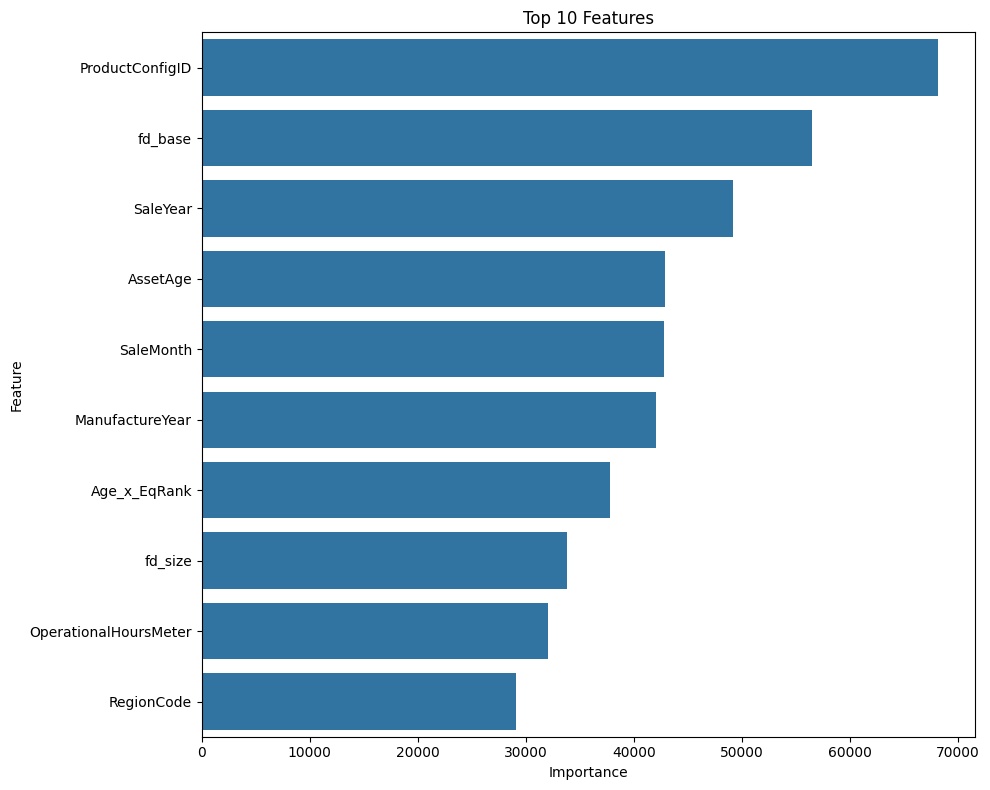

In [206]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feat_imp.head(10),
    x='importance',
    y='feature'
)

plt.title("Top 10 Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [207]:

# # Check train and test have same columns
# train_cols = set(X_full_pre.columns)
# test_cols  = set(X_test_pre.columns)

# print("In train but NOT in test:", train_cols - test_cols)
# print("In test but NOT in train:", test_cols - train_cols)
# print()

# # Check key columns have same dtype in both
# for c in ['OperationalHoursMeter', 'ManufactureYear', 'hours_missing', 'year_missing', 'sub_is_config']:
#     if c in train_final.columns and c in test_final.columns:
#         print(f"{c}: train dtype={train_final[c].dtype}, test dtype={test_final[c].dtype}, "
#               f"train nulls={train_final[c].isnull().sum()}, test nulls={test_final[c].isnull().sum()}")
#     elif c in train_final.columns:
#         print(f"{c}: EXISTS in train, MISSING from test - problem")
#     else:
#         print(f"{c}: missing from both")




# X_test_pre.to_csv('test_final_check.csv', index=False)
# print(f"Saved: {X_test_pre.shape}")
# display(X_test_pre.head())
# submission['TargetValue'].mean()




# import os
# import pandas as pd

# # 1. Define the expected file path
# sub_path = 'submission.csv'

# # 2. Safely check if it exists before printing
# if os.path.exists(sub_path):
#     print(f" File found at: {os.path.abspath(sub_path)}")
    
#     # 3. Load and print the first 5 rows
#     df = pd.read_csv(sub_path)
#     print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
#     print("\n--- Preview of First 5 Rows ---")
#     print(df.head())
# else:
#     print(f" Error: {sub_path} does not exist in the current working directory.")
#     print(f" Current folder contents: {os.listdir('.')}")


## Milestone 1

Section 1: Basic Dataset Understanding

**Question 1 (MCQ): Dataset Dimensions** 
Before building any models, it is crucial to understand the scale of the data. How many records (rows) are present in the train.csv and test.csv datasets, respectively?


In [208]:
# print(f'Train shape     : {train.shape}')
# print(f'Test shape      : {test.shape}')

**Question 2 (MCQ): Target Variable Identification** 
By doing a strict set difference between the columns in train.csv and test.csv, which column is correctly identified as the sole target variable we need to predict?

In [209]:
# print(set(train.columns) - set(test.columns))


**Question 3 (Numeric): Feature Data Types**
 In the train dataset, how many columns are strictly recognized as numerical features (int64 or float64) by default?

In [210]:
# num_cols=train.select_dtypes(include=['int64','float64']).columns.tolist()
# print(num_cols, len(num_cols))


Section 2: Missing Value Analysis  Untitled Title

**Question 4 (MSQ): Extremely Sparse Columns** 
Which of the following configuration columns exhibit a missing value rate higher than 90% (missing over 124,800 rows out of 138,701) in the training set and should likely be dropped or heavily grouped? (Select all that apply)

A) col18

B) col19

C) CabinType

D) col5

In [211]:
# cols = ['col18','col19','CabinType','col5']
# train[cols].isna().mean()

In [212]:
# train_missing_count=(train.isnull().sum())#series
# train_null_df=pd.DataFrame({"train_missing_count":train_missing_count,"missing_pct": np.round((train_missing_count/train.shape[0])*100,3)})
# # display(train_null_df)
# display(train_null_df[train_null_df['missing_pct'] > 90 ])
# train_null_cols=train_missing_count[train_missing_count>0].index.tolist()

**Question 5 (Numeric): Missing Operational Metrics** 
The OperationalHoursMeter represents the lifetime active runtime of the machine. What is the approximate percentage of missing values for this critical column in the training dataset?

In [213]:
# #display(train_null_df)
# #train_null_df[train_null_df.index == 'OperationalHoursMeter']
# #train['OperationalHoursMeter'].isna().mean()
# train_null_df.loc['OperationalHoursMeter','missing_pct']

Section 3: Target Variable Distribution & Anomalies

**Question 6 (MCQ): Target Value Distribution**
Heavy machinery prices are often right-skewed. What is the median of TargetValue (transaction price) in the dataset?

In [214]:

# plt.hist(train['TargetValue'],bins=50)
# plt.show()
# sns.histplot(train['TargetValue'], kde=True)#kde plot - smooth
#print(train['TargetValue'].skew())#>0 => right skewed ;  < 0 => left  ; =0 => roughly normal

#most values are on the left, ie small prices mostly
# In right-skewed data:
# Mean > Median (mode median mean)  (left => mean median mode)
# Because extreme large values pull the mean upward

In [215]:
# train['TargetValue'].median() 

**Question 7 (Numeric): Manufacture Year Anomaly**
 When analyzing the ManufactureYear, you will find a strange anomaly. What is the most frequently occurring (mode) ManufactureYear in the dataset, indicating a default placeholder value used by the data entry system?

In [216]:
# # train['ManufactureYear'].describe()
# display(train['ManufactureYear'].value_counts())
# train['ManufactureYear'].mode()[0]


**Question 8 (MCQ): Time Span of Transactions** 
What is the earliest (minimum) TransactionDate recorded in the training dataset?

A) 1990-01-31

B) 1989-05-12

C) 2000-01-01

D) 1995-12-15

In [217]:
# # train['TransactionDate'].sort_values()
# #pd.to_datetime(train['TransactionDate']).sort_values()
# pd.to_datetime(train['TransactionDate']).min()

Section 4: Categorical & High Cardinality Profiling

**Question 9 (Numeric): High Cardinality Identification**
 Machine learning models struggle with high-cardinality categorical features. How many unique string classes exist within the Spec_BaseClass column?

In [218]:
# print(train['Spec_BaseClass'].unique())
# train['Spec_BaseClass'].nunique()


**Question 10 (MCQ): Geographical Volume** 
Which region accounts for the highest volume of machinery transactions (RegionCode) in this dataset?

In [219]:
# #train.groupby('RegionCode')['TransactionID'].count().sort_values(ascending=False)
# train['RegionCode'].value_counts()

**Question 11 (Numeric): Regional Pricing Insights** 
For the most frequent region that is identified as Florida, what is the approximate average TargetValue for machines sold there?

In [220]:
# train[train['RegionCode']=='Florida']['TargetValue'].mean()

**Question 12 (MCQ): Asset Utilization** 
The UtilizationTier metadata column ranks how heavily an asset was used. Based on the value counts in the training set, what is the most common utilization tier?

In [221]:
# #train['UtilizationTier'].value_counts()
# train['UtilizationTier'].value_counts().idxmax()

**Question 13 (MCQ): Operational Correlation**

 Intuitively, one might assume that machines with higher OperationalHoursMeter values would sell for less. What is the Pearson correlation coefficient between TargetValue and OperationalHoursMeter?

In [222]:
# #train[['TargetValue','OperationalHoursMeter']].corr()-> df
# #train['TargetValue'].corr(train['OperationalHoursMeter'])#default is pearson (method='spearman')
# corr_df=train.corr(method='pearson',numeric_only=True)#pearson => linear relns
# corr_df.loc['OperationalHoursMeter','TargetValue']


**Question 14 (MCQ): Primary Equipment Types** 
Based on the FunctionalClassification column, what is the description of the single most common exact machinery traded on this platform?

A) Wheel Loader - 150.0 to 175.0 Horsepower

B) Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons

C) Skid Steer Loader - 75.0 to 90.0 Horsepower

D) Track Excavators - Medium

In [223]:
# train['FunctionalClassification'].value_counts().head(1)

## Milestone 2

**Section 1: Feature Engineering**
Create the following new features on the Train Dataset:

**TransactionYear** [Extracted from TrasactionDate]

**TransactionQuarter** [Extract from TransactionDate]

**AssetAge** [TansactionYear - ManufactureYear]

**DescriptorLength** [Stores the number of characters in Spec_FullDescriptor]

 **HasOperationalHours** [ A binary feature. Assign 1 if OperationalHoursMeter is available. Assign 0 otherwise]

**HasVariantModifier** [ A binary feature. Assign 1 if Spec_VariantModifier is available. Assign 0 otherwise.]

In [224]:
# #pd.set_option('display.max_seq_items', None)
# # pd.reset_option('display.max_seq_items')
# #np.set_printoptions(threshold=1000)

# train_eng=train.copy()

# #this col has 0 nans
# # errors='coerce' converts unparseable dates(eg NaN) to NaT instead of raising an error. I am not adding it bcoz I want to see if any errors are there 
# train_eng['TransactionDate']=pd.to_datetime(train_eng['TransactionDate'])
# # train_eng['TransactionDate'].isna().sum()# no nans
# train_eng['TransactionYear']=(train_eng['TransactionDate']).dt.year

# train_eng['TransactionQuarter']=(train_eng['TransactionDate']).dt.quarter

# # train_eng['ManufactureYear'].isna().sum()# no nans
# # sorted(train_eng['ManufactureYear'].unique()) 
# train_eng['AssetAge']=(train_eng['TransactionYear']-train_eng['ManufactureYear'])

# train_eng['DescriptorLength']=train_eng['Spec_FullDescriptor'].str.len() #It automatically returns NaN for any null rows


# train_eng['DescriptorLength'].isna().sum()


# train_eng['HasOperationalHours']=np.where(train_eng['OperationalHoursMeter'].notna(), 1, 0) #has nans only


# train_eng['HasVariantModifier']=np.where(train_eng['Spec_VariantModifier'].notna(), 1, 0) #has nans only no "none or unspecified"

**Q1) Which AssetAge occurs most frequently in the training dataset?**

5

6

4

7

In [225]:
# train_eng['AssetAge'].mode()[0]

**Q2)Which  TransactionQuarter    has the highest average TargetValue?**

1

2

3

4

In [226]:
# df = train_eng.groupby('TransactionQuarter')['TargetValue'].mean()
# df.sort_values(ascending=False)

**Q3)What is the maximum value of DescriptorLength in the training dataset?**

19

13

12

11

In [227]:
# train_eng['DescriptorLength'].max()

**Q4)How many records have HasOperationalHours = 1 in training data? (NAT)**



In [228]:
# train_eng[train_eng['HasOperationalHours']==1].shape[0]

**Q5)What percentage of records contain variant information in training data? (Select an answer range)**

37 - 38

40 - 41

28 - 29

None of Them

In [229]:
# # print(train_eng[train_eng['HasVariantModifier']==1].shape[0] / train_eng.shape[0])
# train_eng['HasVariantModifier'].mean()


**Q6)What is the mean of ManufactureYear in the training data? (Round your answer to 2 decimal places**


In [230]:
# train_eng['ManufactureYear'].mean().round(2)

**Section 2: Encoding**
Perform One-Hot Encoding on the following columns:

RegionCode

CabinType

UtilizationTier

(Use drop_first=True.)

In [231]:
# from sklearn.preprocessing import OneHotEncoder

# ohe=OneHotEncoder(drop='first',sparse_output=False).set_output(transform='pandas') #converts numpy array to pandas df (Also pandas does not support sparse output so set it to false)
# ohe_cols=['RegionCode','CabinType','UtilizationTier'] #check nans, none or unspecified 
# #region code - unspecified , 0 nans
# #utier - nans are there
# #cabintype - clean
# train_oh_encoded=ohe.fit_transform(train_eng[ohe_cols])
# train_oh_encoded

# # ohe=OneHotEncoder(drop='first')
# # ohe_cols=['RegionCode','CabinType','UtilizationTier']
# # train_oh_encoded=ohe.fit_transform(train_eng[ohe_cols])
# # train_oh_encoded.toarray()

# train_eng_new=train_eng.drop(columns=['RegionCode','CabinType','UtilizationTier']) #50+ 6 -3=53
# train_eng_enc=pd.concat([train_eng_new,train_oh_encoded],axis=1)
# print(ohe.get_feature_names_out(),len(ohe.get_feature_names_out()))
# train_eng_enc.shape #53+57 = 110

**Q7)How many encoded columns are created in the training data after applying One-Hot Encoding to these three features?**

In [232]:
# len(ohe.get_feature_names_out())

In [233]:

# train_eng_dummies=pd.get_dummies(train_eng,columns=['RegionCode','CabinType','UtilizationTier'],drop_first=True)
# print(train_eng_dummies.shape) # 109 new cols
# 109-53 #(50 +6-3+x=109)=> x=109-53
# #bcoz pd.get_dummies ignores nan


**Section3 : Correlation Analysis**

After creating the AssetAge feature, compute the Pearson correlation matrix using all numerical variables.

**Q8) Which of the following numerical features has the highest absolute correlation with TargetValue in the training data?**

ManufactureYear

OperationalHoursMeter

AssetID

ProductConfigID


In [234]:
# corr1_df=train_eng_dummies.corr(method='pearson',numeric_only=True)#pearson => linear relns
# corr1_df.loc['TargetValue',['ManufactureYear','OperationalHoursMeter','AssetID','ProductConfigID']].abs().sort_values(ascending=False)


In [235]:
# cols_for_corr = ['ManufactureYear',

# 'OperationalHoursMeter',

# 'AssetID',

# 'ProductConfigID','TargetValue']

# num_df         = train_eng_dummies[cols_for_corr]
# spearman_corr  = num_df.corr(method='spearman')

# plt.figure(figsize=(12, 10))
# sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm')
# plt.title('Spearman Correlation Matrix', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

**Section 4 : Feature Scaling**

Apply StandardScaler to the following numerical features after imputing the missing values with corresponding mean on the train data

ManufactureYear

OperationalHoursMeter

AssetAge

Split the processed dataset into training and validation sets using:

test size = 20%
Random State = 42

In [236]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split

# train_imp_sc=train_eng_dummies.copy()

# imp=SimpleImputer(strategy='mean')
# ss=StandardScaler()
# imp_sc_cols=['ManufactureYear','OperationalHoursMeter','AssetAge']

# pipe=Pipeline([('impute',imp),('scale',ss)])

# train_imp_sc[imp_sc_cols]=pipe.fit_transform(train_imp_sc[imp_sc_cols])

# #train_imp_sc[imp_sc_cols]
# X=train_imp_sc.drop(columns=['TargetValue'])
# y=train_imp_sc['TargetValue']
# Xy_train,Xy_val=train_test_split(train_imp_sc,test_size=0.2,random_state=42)


# X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
# print(X_train.shape)
# print(X_val.shape)
# print(y_train.shape)
# print(y_val.shape)

**Section 5 : Model Building**

On the processed training data (imputed and scaled in previous step), Train a Linear Regression model using the following predictors:

ManufactureYear

AssetAge

Evaluate the model on the validation dataset.

**Q11)What is the R² score of the Linear Regression model on the validation dataset?**

In [237]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# lr=LinearRegression()
# lr.fit(X_train[['ManufactureYear','AssetAge']],y_train)
# y_preds=lr.predict(X_val[['ManufactureYear','AssetAge']])
# lr.score(X_val[['ManufactureYear','AssetAge']],y_val)
# # r2_score(y_val,y_preds)

## MileStone 3

**Feature Engineering (Temporal & Mathematical)**

**Datetime Extraction**

Q1)Machine learning models cannot process raw date strings like `1990-01-31`. We must engineer numeric features from the `TransactionDate` column. After converting `TransactionDate` to a datetime object and extracting the `SaleYear`, what is the most frequent `SaleYear` (mode) in the training dataset?


2010

2009

1998

2012

In [238]:
# train_m3=train.copy()
# test_m3=test.copy()

In [239]:
# train_m3['TransactionDate']=pd.to_datetime(train_m3['TransactionDate'])
# train_m3['SaleYear']=train_m3['TransactionDate'].dt.year
# train_m3['SaleYear'].mode()[0]
# # saleyr.value_counts()

**Calculating Asset Age**


Q2) A highly predictive feature for machinery pricing is the age of the asset at the time of sale. To calculate this accurately, we must first remove the anomaly where `ManufactureYear` is equal to 1000 or 1001 (a system default). After replacing `1000`  and '1001' with `NaN` and calculating `AssetAge = SaleYear - ManufactureYear`, what is the median `AssetAge` in the training data?

7.0

10.0

8.0

15.0

In [240]:
# train_m3['ManufactureYear']=train_m3['ManufactureYear'].replace([1001,1000],np.nan)
# train_m3['AssetAge']=train_m3['SaleYear'] - train_m3['ManufactureYear']
# #train_m3[train_m3['AssetAge'] <0] -> 7 rows  have  -ve age
# train_m3['AssetAge'].median()


**Dropping Sparse Features**


Q3) During EDA, we discovered several columns that are almost entirely empty. 

If we set a threshold to drop any column missing more than 80% of its data, exactly how many columns will be removed from the dataset?


10 columns

15 columns

20 columns

25 columns

In [241]:
# df1=train_m3.isna().mean()*100 #a series
# df1[df1>80].shape

**Feature Interaction (Intensity)**

Q4) Feature interactions reveal hidden patterns. Let's create an "Intensity" feature by dividing `OperationalHoursMeter` by `AssetAge` to see how heavily a machine was used per year. 

After creating `HoursPerYear`, what is the median number of hours a machine was used per year? 

(Note: Ignore infinite/NaN values for this calculation).

*
~250 hours/year

~475 hours/year

~320 hours/year

~1200 hours/year

In [242]:
# train_m3['HoursPerYear']=train_m3['OperationalHoursMeter']/train_m3['AssetAge'] #will be inf for asset age ==0 and -ve if asset age is -ve


# # train_m3['HoursPerYear'].median()
# train_m3['HoursPerYear'].replace([np.inf, -np.inf], np.nan).median() #median doesnt ignore inf by default like nan, so replse them with nan first and then find median


**Imputing Missing Categorical Data**

Q5) Tree-based models can learn from the "absence" of data if we encode it properly. 

If we decide to fill all missing values in the categorical column `CabinType` with the string `"Missing"`, how many total rows will contain the value `"Missing"` in the training dataset?


65,000

80,000

0

100,500

In [243]:
# print(train_m3['CabinType'].isna().sum())
# print(train_m3['CabinType'].unique())
# #0 missing values

**Imputing Missing Numeric Data**

Q6)For a highly skewed numeric column like `OperationalHoursMeter`, the mean is heavily distorted by extreme outliers. What is the safest mathematical value to use for imputation in this specific column?


0

Mean

Median

Forward-Fill

In [244]:
# # sns.histplot(train_m3['OperationalHoursMeter'],kde=True)
# sns.boxplot(x=train_m3['OperationalHoursMeter'])
# print(train_m3['OperationalHoursMeter'].skew()) #> => right skewed
# #median best (mean will overestimate hours for missing rows)
# #Forward fill means fill a missing value with the previous row's value -> for time series data like stock prices or sensor readings where the previous reading is a reasonable estimate for a gap. For example if a temperature sensor misses a reading, the previous temperature is a reasonable guess.


**Data Transformation & EncodingLog Transforming the Target**


Q 7 )The competition evaluates models using Root Mean Squared Logarithmic Error (RMSLE). To optimize for this using standard regression algorithms (which use RMSE), we apply a `log1p` transformation to the `TargetValue`. 

After applying `np.log1p` to the `TargetValue` column, what is the new standard deviation of the transformed target?

~0.67

~26361.12

~0.81

~10.51

In [245]:
# np.log1p(train_m3['TargetValue']).std() #log1p(x) = ln(1 + x) where ln is natural log.

**Ordinal Encoding Application**

Q 8 )We must convert text categories into numbers. `OrdinalEncoder` assigns a unique integer to each class. 

If we apply an `OrdinalEncoder` to the `UtilizationTier` column (which has 'Low', 'Medium', 'High', and 'Unspecified' before filling NaNs), how many unique integer values will the encoded column contain?

2

3

4

5

In [246]:
# from sklearn.preprocessing import OrdinalEncoder
# train_m3_c=train_m3.copy()

# print(train_m3['UtilizationTier'].isna().sum())
# print(train_m3['UtilizationTier'].unique())

# oe=OrdinalEncoder()
# train_m3_c['UtilizationTier']=oe.fit_transform(train_m3_c[['UtilizationTier']])
# train_m3_c['UtilizationTier'].unique()
# #OrdinalEncoder passes through NaN values without encoding them as integers, leaving them as NaN
# #3

**Train-Test Split Verification**

Q 9 )If we define our target variable `y` as the `TargetValue` column, and our features `X` as the remaining dataframe, and perform a standard 80/20 train-test split (`test_size=0.2`), how many rows will be allocated to our `X_train` training set?


110,960 rows

27,741 rows

138,701 rows

15,000 rows

In [247]:
# from sklearn.model_selection import train_test_split

# X_m3=train_m3.drop(columns=['TargetValue'])
# y_m3=train_m3['TargetValue']

# X_train_m3,X_val_m3,y_train_m3,y_val_m3=train_test_split(X_m3,y_m3,test_size=0.2)
# print(X_train_m3.shape)
# print(X_val_m3.shape)
# print(y_train_m3.shape)
# print(y_val_m3.shape)

**Target Encoding** 

Q10 ) Which of the following scenarios is the primary reason a Data Scientist would choose to use Target Encoding instead of One-Hot Encoding?

The feature is a continuous numeric variable like `Age`.

The categorical feature has very high cardinality (e.g., hundreds of unique values like `Spec_BaseClass`).

The target variable is binary (0 or 1).

The dataset has no missing values.

Preventing Data Leakage



In [248]:
#The categorical feature has very high cardinality (e.g., hundreds of unique values like `Spec_BaseClass`).
#One-Hot Encoding creates one new column per unique value. If Spec_BaseClass has 1,249 unique values, OHE creates 1,249 new columns - massively expanding the dataset and creating very sparse data. Target encoding replaces the whole column with a single numeric column (mean price per category) regardless of how many unique values exist. Much more efficient and carries direct price signal.

Q 11 ) To strictly avoid Data Leakage, at which stage of the machine learning pipeline must you apply your Train-Test Split?


After applying StandardScaler to the entire dataset.

Before applying any scalers, target encoders, or median imputations.

After the model is fully trained.
    
During Exploratory Data Analysis.

In [249]:
#Before applying any scalers, target encoders, or median imputations.

**Model Building & Evaluation**
Feature Importance

Q 12 )After training a tree-based model, we can plot the `feature_importances_`. 

What does a high feature importance score mathematically imply?

The feature has a high standard deviation.

The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.

The feature has no missing values.

The feature perfectly correlates with another independent variable.

Understanding Early Stopping



In [250]:
# The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.
# In LightGBM, feature importance is measured by how many times a feature was used to split data across all trees, weighted by how much that split improved the model. A high score means the model found that feature consistently useful for reducing prediction error.  

Q 13 )What is the primary benefit of utilising an "Early Stopping" callback during model training (e.g., `stopping_rounds=100`)?

It makes the model train faster by randomly skipping rows.

It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.

It stops the script if the computer runs out of RAM.

It prevents underfitting by forcing the model to reach a specific metric.

Algorithm Selection


In [251]:
#It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.
#Without early stopping, LightGBM builds all 3,000 trees (n_estimators=3000). But after maybe tree 800, the validation RMSLE stops improving and starts getting worse - the model starts memorising training data rather than learning general patterns. Early stopping with stopping_rounds=100 says "if val RMSLE hasn't improved for 100 consecutive trees, stop now." The best_iteration_ attribute records which tree gave the best val score, and predictions use that tree - not the final overfitted one.


Based on our EDA, our dataset contains significant missing values, highly skewed numerical features, and dozens of categorical text columns. 

Q 14)Which of the following machine learning models handles this specific type of "messy" tabular data best without requiring massive manual scaling and imputation?

Linear Regression

Deep Neural Networks (Multilayer Perceptrons)

Gradient Boosted Trees (LightGBM/XGBoost)

K-Nearest Neighbors (KNN)

Hyperparameter Intuition


In [252]:
# Gradient Boosted Trees (LightGBM/XGBoost)

# Missing values - LightGBM handles NaN natively, learns the best direction to send missing values at each split. Linear Regression crashes on NaN, KNN is very sensitive to it, Neural Networks need explicit handling.
# Skewed numerics - trees split on thresholds, not magnitudes. Whether OH is 100 or 100,000 doesn't matter - the tree finds the best split point. Linear Regression is heavily distorted by skew. KNN uses distances which are dominated by large-scale features.
# Categorical columns - LightGBM has native categorical support. Neural Networks need extensive preprocessing. KNN can't handle strings at all.
# Tabular messy data - Gradient Boosted Trees are the industry standard for exactly this kind of data. Neural Networks need far more data and preprocessing to compete.


Q 15 ) When initializing a `RandomForestRegressor` or `LGBMRegressor`, what does the `n_estimators` hyperparameter control?

The number of rows used to train the model.

The maximum depth of the individual trees.

The learning rate of the gradient descent.

The total number of individual decision trees built in the ensemble.

In [253]:
#The total number of individual decision trees built in the ensemble.

## Milestone 4

Dataset columns used across these questions( Use the following columns and all the rows from the training dataset for the questions of this milestone unless specified otherwise) :
- TargetValue - sale price (target)
- UtilizationTier - Low / Medium / High usage (categorical, has missing values)
- DrivetrainType, CabinType, AssetScaleFactor - categorical machine specs
- ManufactureYear, OperationalHoursMeter - numerical machine specs
- Spec_FullDescriptor, RegionCode, FunctionalClassification - extra descriptive columns (not required, but usable for extensions)

**Q1 - Stratified vs. Non-Stratified Split**

Since TargetValue is a continuous price (not a class label), we first turn it into 5 price bands (quantile bins) so we can "stratify" the split, just like you would stratify on a class column.

Steps:

A) Fill missing values in UtilizationTier with the string "Unknown". Create a new column PriceBand by cutting TargetValue into 5 quantile-based bins using pd.qcut(..., q=5, labels=False). Split the data using train_test_split into 70% train / 30% validation, with random_state=42, stratifying on PriceBand. Compute the value counts of PriceBand in the train and validation sets (sorted by bin index ascending), and store them as NumPy arrays.

B) Repeat the exact same split (test_size=0.3, random_state=42) but with stratify=None. Again compute the sorted validation PriceBand counts as a NumPy array.

C) Convert both validation count arrays (from A and B) into proportions (divide by total validation size). For each bin, compute the absolute difference between the two proportions, and report the maximum absolute difference (rounded to 4 decimal places).



In [254]:
# train_m4=train[['TargetValue','UtilizationTier','DrivetrainType', 'CabinType', 'AssetScaleFactor','ManufactureYear', 'OperationalHoursMeter','Spec_FullDescriptor', 'RegionCode', 'FunctionalClassification' ]]
# train.head(5)

In [255]:
# train_m4_cl=train_m4.copy()
# print(train_m4_cl['UtilizationTier'].unique())

# nan_rows=train_m4_cl['UtilizationTier'].isna()
# print(nan_rows.sum())
# train_m4_cl.loc[nan_rows,'UtilizationTier']='Unknown'

# print((train_m4_cl['UtilizationTier']=='Unknown').sum())
# train_m4_cl['UtilizationTier'].unique()


# quintiles=pd.qcut(train_m4_cl['TargetValue'],q=5,labels =False)#labels=False tells pandas to return integer codes (0, 1, 2, etc.) instead of the mathematical interval ranges.(9.99-14.4]
# # display(quintiles)
# display(quintiles.value_counts())
# train_m4_cl['PriceBrand']=quintiles

In [256]:
# #A stratified
# X_m4=train_m4_cl.drop(columns=['TargetValue'])
# y_m4=train_m4_cl['TargetValue']
# X_train_m41,X_val_m41,y_train_m41,y_val_m41=train_test_split(X_m4,y_m4,test_size=0.3,random_state=42,stratify=X_m4['PriceBrand'])
# print(X_train_m41.shape)
# print(y_train_m41.shape)

# print(X_val_m41.shape)
# print(y_val_m41.shape)

# display((X_train_m41['PriceBrand'].value_counts()).sort_index())
# pb_vc1=(X_train_m41['PriceBrand'].value_counts()).sort_index().values
# pb_vc1_val=(X_val_m41['PriceBrand'].value_counts()).sort_index().values
# display(pb_vc1)
# display(pb_vc1_val)




In [257]:
# #B - non-stratified



# X_train_m42,X_val_m42,y_train_m42,y_val_m42=train_test_split(X_m4,y_m4,test_size=0.3,random_state=42,stratify=None)
# print(X_train_m42.shape)
# print(y_train_m42.shape)

# print(X_val_m42.shape)
# print(y_val_m42.shape)

# display((X_train_m42['PriceBrand'].value_counts()).sort_index())
# pb_vc2=(X_train_m42['PriceBrand'].value_counts()).sort_index().values
# pb_vc2_val=(X_val_m42['PriceBrand'].value_counts()).sort_index().values
# display(pb_vc2)
# display(pb_vc2_val)

In [258]:
# prop1=pb_vc1_val/X_val_m41.shape[0]
# prop2=pb_vc2_val/X_val_m42.shape[0]
# abs(prop1-prop2).max().round(4)

**Q2 - Preprocessing Pipeline**
Use the stratified split (X_train, X_valid, y_train, y_valid) from Q1 for the rest of the notebook. All preprocessing objects must be fit only on X_train and used to transform both X_train and X_valid.

Steps:

Categorical columns: "UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"- process with SimpleImputer(strategy="most_frequent") then OneHotEncoder(handle_unknown="ignore", sparse_output=True).

Numerical columns:"ManufactureYear", "OperationalHoursMeter" - process with SimpleImputer(strategy="mean") then StandardScaler().Combine both using a ColumnTransformer with remainder="drop".

Fit on X_train, transform both X_train and X_valid. Store results as X_train_proc, X_valid_proc.
Report the sum of all values in X_train_proc (rounded to 3 decimal places).

In [259]:
# #X_train_m41,X_val_m41,y_train_m41,y_val_m41
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler,OneHotEncoder


# cat_cols_m4=["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
# si_m4=SimpleImputer(strategy='most_frequent')
# ohe_m4=OneHotEncoder(handle_unknown='ignore',sparse_output=True)

# num_cols_m4=["ManufactureYear", "OperationalHoursMeter"]
# si_num_m4=SimpleImputer(strategy='mean')


# pipe_m4=Pipeline(steps=[("si",si_m4),("ohe",ohe_m4)])
# pipe_num_m4=Pipeline([("si_num",si_num_m4),("ss",StandardScaler())])

# pre_m4=ColumnTransformer([("pipe_cat",pipe_m4,cat_cols_m4),("pipe_num",pipe_num_m4,num_cols_m4)],remainder='drop')

# X_train_m4_pro=pre_m4.fit_transform(X_train_m41)
# X_val_m4_pro=pre_m4.transform(X_val_m41)

# print(X_train_m4_pro.sum())


In [260]:
# pre_colms=pre_m4.get_feature_names_out()
# pre_colms

We're checking whether it matters if we carefully balance the price distribution across train/val, or just split randomly. Answer: for this dataset it barely matters (0.33% max difference) because the dataset is large enough that random splits are naturally balanced.

**Q3 - Hyperparameter Tuning with RandomizedSearchCV**
Use X_train_proc and y_train from Q2.

Tune a RandomForestRegressor(random_state=42) using RandomizedSearchCV over:

- n_estimators:[ 50, 100, 200]
- max_depth: [5, 10, 15]
Configuration: n_iter=5, cv=3, random_state=42, n_jobs=-1, default scoring.

Fit on (X_train_proc, y_train), then report the best n_estimators found.

*


In [261]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor

# rfr=RandomForestRegressor(random_state=42)
# params={
#     "n_estimators":[ 50, 100, 200],
#     "max_depth": [5, 10, 15]
# }
# rs=RandomizedSearchCV(rfr,n_iter=5,cv=3,random_state=42,n_jobs=-1,param_distributions=params)#default score of rfr is r2 and rscv uses the scoring of theestimator by default
# rs.fit(X_train_m4_pro,y_train_m41)


In [262]:
# rs.best_params_

**Q4 - AdaBoost Estimator Error Variance**
Train an AdaBoostRegressor(n_estimators=50, random_state=42) (all other parameters default) on (X_train_proc, y_train).

After fitting, access model.estimator_errors_ (length-50 array of each weak learner's error).

Compute np.var(model.estimator_errors_) and report it rounded to 4 decimal places.

In [263]:
# from sklearn.ensemble import AdaBoostRegressor

# abr=AdaBoostRegressor(n_estimators=50, random_state=42)
# abr.fit(X_train_m4_pro,y_train_m41)
# np.var(abr.estimator_errors_).round(4)

**Q5 - Feature Importance**
Train a RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42) on (X_train_proc, y_train).

After fitting, extract feature_importances_ and report the index of the feature with the maximum importance. If there is a tie, return the smallest index.

In [264]:
# from sklearn.ensemble import RandomForestRegressor

# rf=RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)
# rf.fit(X_train_m4_pro,y_train_m41)


In [265]:
# # rf.feature_importances_.max()

# rf.feature_importances_.argmax()
# # pre_colms[13]

**Q6 - Counting MLP Weights**
Let N = X_train_proc.shape[1] (number of input features after preprocessing).

An MLPRegressor with hidden_layer_sizes=(128, 64, 32) has this architecture:

- Input layer: N 
- neuronsHidden Layer 1: 128
- 
- neuronsHidden Layer 2: 64
- 
- neuronsHidden Layer 3: 32
- 
- neuronsOutput layer: 1 neuron (regression has a single output)
Compute the total number of connection weights (excluding all biases) using your actual value of N.

In [266]:
# from sklearn.neural_network import MLPRegressor



# N=X_train_m4_pro.shape[1]
# (N*128) + (128*64) + (64*32) + (32*1) #connection weights (excluding biases)

**Q7 - Training Loss After 5 Iterations**
Train the same MLP architecture as Q6 (hidden_layer_sizes=(128, 64, 32), activation="relu") with: solver="adam", max_iter=5, batch_size=32, random_state=42 (all other params default).

Fit on (X_train_proc, y_train). After training, access model.loss_ and report it rounded to 4 decimal places.

In [267]:
#  # max_iter=5,        # stop after 5 full passes through the data (epochs)
#  #    batch_size=32,     # process 32 rows at a time before updating weights
#  #    random_state=42    # reproducibility - fixes weight initialisation and data shuffling


# mlp=MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu",solver="adam",max_iter=5,batch_size=32,random_state=42)
# mlp.fit(X_train_m4_pro,y_train_m41)
# mlp.loss_.round(4) #The loss function is Mean Squared Error (MSE) by default for MLPRegressor

**Q8 - Effect of Regularization (alpha)**
Train two MLPRegressor models on (X_train_proc, y_train) with hidden_layer_sizes=(100,), max_iter=5, random_state=42 (defaults otherwise):

- Model A: alpha=0.0001 (default - light regularization)
- Model B: alpha=1.0 (strong regularization)
Compute the Mean Absolute Error (MAE) of each model's predictions on the training set. Report the absolute difference between the two MAE values, rounded to 4 decimal places.

In [268]:
# from sklearn.metrics import mean_absolute_error

# mlp1=MLPRegressor(hidden_layer_sizes=(100,),max_iter=5,random_state=42,alpha=0.0001)
# mlp1.fit(X_train_m4_pro,y_train_m41)
# pred1=mlp1.predict(X_train_m4_pro)

# mae1=mean_absolute_error(y_train_m41,pred1)
# mae1

In [269]:
# mlp2=MLPRegressor(hidden_layer_sizes=(100,),max_iter=5,random_state=42,alpha=1.0)
# mlp2.fit(X_train_m4_pro,y_train_m41)
# pred2=mlp2.predict(X_train_m4_pro)

# mae2=mean_absolute_error(y_train_m41,pred2)
# print(mae2)
# np.round((abs(mae1-mae2)),4)

**Q9 - Validation Performance**
Using the MLP model trained in Q7, generate predictions on X_valid_proc and compare them to y_valid. Compute the Mean Absolute Error (MAE) on the validation set, rounded to 4 decimal places.

In [270]:
# from sklearn.metrics import mean_absolute_error
# pred_9=mlp.predict(X_val_m4_pro)
# np.round(mean_absolute_error(y_val_m41,pred_9),4)

## Milestone 5 

**Section1 : Feature Engineering**
Create the following derived features on the Training Data and answer the following questions:

TransactionYear (Extract from TransactionDate)

TransactionMonth (Extract from TransactionDate)

TransactionQuarter (Extract from TransactionDate)

ManufactureDecade (Extract from ManufactureYear)

SpecificationComplexity (Number of words present in Spec_FullDescriptor)

In [271]:
# train_m5=train.copy()

# train_m5['TransactionDate']=pd.to_datetime(train_m5['TransactionDate'])
# train_m5['TransactionYear']=train_m5['TransactionDate'].dt.year
# train_m5['TransactionMonth']=train_m5['TransactionDate'].dt.month
# train_m5['TransactionQuarter']=train_m5['TransactionDate'].dt.quarter
# train_m5['ManufactureDecade']=train_m5['ManufactureYear'].apply(lambda x:(x//10)*10)
# train_m5['SpecificationComplexity']=train_m5['Spec_FullDescriptor'].astype(str).apply(lambda x:len(x.split())) #str(nan) becomes the literal string 'nan'  rather than crashing on .split().

# train_m5[['TransactionDate','TransactionYear','TransactionMonth','TransactionQuarter','ManufactureDecade','SpecificationComplexity']]


**Q1.Which ManufactureDecade has the highest average TargetValue?**

2010

2000

1990

1980

**Q2. What is the maximum value of SpecificationComplexity? (NAT)**


In [272]:
# print(train_m5.groupby('ManufactureDecade')['TargetValue'].mean().sort_values(ascending=False))
# #2010
# print(train_m5['SpecificationComplexity'].max())
# #4

**Section 2 : Feature Selection**
From the Training Data,

Create a new Training Data using only the following categorical features:

DataOriginCode
VendorPartnerID
UtilizationTier
AssetScaleFactor
RegionCode
InventoryGroupCategory
InventoryGroupDescription

and
Use all numerical features except:

TransactionID
AssetID

Answer the following questions

**Q3. What are the number of features in the Training Data?**


In [273]:
# #train_m5.select_dtypes(include='number').columns
# train_m5_new=train_m5[['TargetValue','ProductConfigID','ManufactureYear', 'OperationalHoursMeter','TransactionYear','TransactionMonth', 'TransactionQuarter', \
#                        'ManufactureDecade','SpecificationComplexity','DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription']]
# train_m5_new.shape
# #16 - 1(target) = 15 features

**Section 3: Train-Validation Split**


Split the new training data into train and validation splits.

Validation Size = 20%
Random State = 42
Important: Perform the split before any preprocessing to avoid data leakage.

**Section 4:  Data Preprocessing**

On both the Training and the Validation Split, perform the following:

For the Numerical Features

1. SimpleImputer with strategy "Median"

2. Standard Scalining 

For the Categorical Features

1. SimpleImputer with strategy "Most Frequent"

2. One-Hot Encoding (handle_unknown='ignore')

Perform preprocessing using a Pipeline and ColumnTransformer.

Q4. What is the shape of the resultant training dataset after preprocessing?


In [274]:
# from sklearn.preprocessing import OneHotEncoder,StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer

# X_m5=train_m5_new.drop(columns='TargetValue')
# y_m5=train_m5_new['TargetValue']

# X_train_m5,X_val_m5,y_train_m5,y_val_m5=train_test_split(X_m5,y_m5,test_size=0.2,random_state=42)
# print(X_train_m5.shape)
# print(y_train_m5.shape)
# print(X_val_m5.shape)
# print(y_val_m5.shape)

# num_colms=X_train_m5.select_dtypes(include='number').columns.tolist()
# num_si=SimpleImputer(strategy='median')
# num_sc=StandardScaler()
# num_pipe=Pipeline([
#     ('si',num_si),
#     ('sc',num_sc)
# ])

# cat_colms=X_train_m5.select_dtypes(include='object').columns.tolist()
# cat_si=SimpleImputer(strategy='most_frequent')
# cat_enc=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
# cat_pipe=Pipeline([
#     ('si',cat_si),
#     ('sc',cat_enc)
# ])

# pre=ColumnTransformer([
#     ('num_pipe', num_pipe ,num_colms ),
#     ('cat_pipe',cat_pipe,cat_colms)
# ]).set_output(transform="pandas")


# X_train_m5_pre=pre.fit_transform(X_train_m5)
# X_val_m5_pre=pre.transform(X_val_m5)

# display(X_train_m5_pre.head())
# display(X_val_m5_pre.head())
# display(X_train_m5_pre.shape)
# display(X_val_m5_pre.shape)

**Section 5 Feature Selection**

On the Scaled Training and Validation set

Apply SelectKBest using f_regression and retain the Top 100 features.

**Q5. On the processed Training set, which feature has the highest F-score according to SelectKBest?**


num__ManufactureDecade

cat__AssetScaleFactor_Mini

cat__UtilizationTier_Low

**Q6. On the processed Training set,  which feature has the lowest F-score among the selected features?**


cat__AssetScaleFactor_Mini

cat__UtilizationTier_Low

cat__RegionCode_Oklahoma

**Q7. On the processed Training set,  which of the following features were removed by SelectKBest?**

cat__AssetScaleFactor_Small

cat__RegionCode_Oklahoma

cat__UtilizationTier_High

In [275]:
# from sklearn.feature_selection import SelectKBest,f_regression

# sk=SelectKBest(f_regression,k=100)

# X_train_m5_sk=sk.fit_transform(X_train_m5_pre,y_train_m5)
# X_val_m5_sk=sk.transform(X_val_m5_pre)

# #print(sk.get_feature_names_out())#selector.get_feature_names_out() returns the names of the selected features only
# #print(sk.get_support()) #boolean mask of select or not , will have all features 118
# #print(sk.scores_)#scores of all features 118

# #we need among selected higheset score and among selected lowest score
# #simple way sort scores using argsort descending and then we get top 100 features and rest not selected  0th one -> highest 99th one -> lowest among selected and  reat not selected

# l=sk.scores_.argsort()
# l_desc=l[::-1]
# n1=l_desc[0]
# n2=l_desc[99]
# n3=l_desc[100:]
# print(X_train_m5_pre.columns[n1])
# print(X_train_m5_pre.columns[n2]) #cat_pipe__RegionCode_Vermont not in option , 3rd option is not selected but removed..second is the only one we can choose then (1st one has highest score)
# print(X_train_m5_pre.columns[n3])

**Section 6: Baseline Model**


Train a RandomForestRegressor using default parameters and random_state=42. 
Truncate your answers to 2 decimal places where applicable.

**Q8. What is the validation MAE of the baseline Random Forest model?**

**Q9. What is the RMSE on the Validation set using the baseline Random Forest model?**



In [276]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error,mean_squared_error


# rfr_m5=RandomForestRegressor(random_state=42)
# rfr_m5.fit(X_train_m5_sk,y_train_m5)
# rfr_m5_preds=rfr_m5.predict(X_val_m5_sk)
# print(mean_absolute_error(y_val_m5,rfr_m5_preds))#6072.88
# print(np.sqrt(mean_squared_error(y_val_m5,rfr_m5_preds))) #9164.64

**Section 7: Hyperparameter Tuning**


Perform RandomizedSearchCV using the following search space:

n_estimators = [100, 200]
max_depth = [10, None]
max_features:["sqrt"]
Use:

3-fold Cross ValidationScoring 
Metric = Negative RMSE
n_iter = 4
random_state = 42

 Truncate your answers to 2 decimal places where applicable.

In [277]:
# from sklearn.model_selection import RandomizedSearchCV


# params={
#     "n_estimators" : [100,200],
#     "max_depth" : [10,None],
#     "max_features": ["sqrt"]
# }
# rs_m5=RandomizedSearchCV(RandomForestRegressor(random_state=42),param_distributions=params,cv=3,scoring='neg_root_mean_squared_error',n_iter=4,random_state=42)
# rs_m5.fit(X_train_m5_sk,y_train_m5)

Q10. Which is the value of n_estimators obtained using RandomizedSearchCV?

Q11. Which is the value of best max_depth obtained using RandomizedSearchCV?

Q12. What is the best cross-validation RMSE obtained during hyperparameter tuning? 

Q13. What is the validation MAE of the hyperparameter tuned Random Forest model?

Q14. What is the validation RMSE of the hyperparameter tuned Random Forest model?

In [278]:
# print(rs_m5.best_params_) #{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
# print(-(rs_m5.best_score_)) #11358.39235021993
# best_preds = rs_m5.predict(X_val_m5_sk) 
# mae  = mean_absolute_error(y_val_m5, best_preds) #7383.007030017289
# rmse = np.sqrt(mean_squared_error(y_val_m5, best_preds)) #10753.720552515182
# print(mae)
# print(rmse)